In [ ]:
!pip install --upgrade transformers accelerate scikit-learn

**Roberta**

In [ ]:


import json
import os
from datasets import Dataset, Features, Value
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, pipeline
import numpy as np # Import numpy to handle np.int64
import sys # Import sys for sys.exit()
from sklearn.metrics import accuracy_score, f1_score # Import metrics from sklearn
import torch # Import torch to check for CUDA

# Replace paths with your actual file locations in Drive
train_path = "/content/drive/MyDrive/medical_data/trainigdata/medical_tc_train.csv"
test_path = "/content/drive/MyDrive/medical_data/trainigdata/medical_tc_test.csv"
labels_path = "/content/drive/MyDrive/medical_data/trainigdata/medical_tc_train.csv" # Using train for labels

# Load data
try:
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    # This labels_df is not strictly necessary if using train_df for labels, but keep for consistency
    labels_df = pd.read_csv(labels_path)
except FileNotFoundError as e:
    print(f"Error loading data file: {e}")
    print("Please ensure the paths are correct and the files exist in your Google Drive.")
    sys.exit() # Exit if files are not found

print("Train samples after loading:", len(train_df))
print("Test samples after loading:", len(test_df))
# Print the first few rows of labels_df to see its structure if needed
# print("Labels:", labels_df.head())

# Ensure 'condition_label' column exists before proceeding
if "condition_label" not in train_df.columns:
    print("Error: 'condition_label' column not found in the training data.")
    sys.exit() # Exit if column is missing
if "condition_label" not in test_df.columns:
    # This is less critical if you filter the test set later, but good to check existence
    print("Warning: 'condition_label' column not found in the test data. Will attempt to filter.")
    # Decide if you want to exit or just warn
    # sys.exit()


# Create label-to-ID mapping using all unique labels from the training data
# It's important to use the training data for the mapping if you're training
# on it, to ensure all training labels are covered.
# Convert labels to string during unique check as a safeguard
all_train_labels = train_df["condition_label"].dropna().astype(str).unique()
if len(all_train_labels) == 0:
    print("Error: No unique non-null labels found in the training data 'condition_label' column.")
    sys.exit() # Exit if no unique labels are found

# Ensure labels in map are strings before creating mapping
label2id = {label: idx for idx, label in enumerate(all_train_labels)}
id2label = {idx: label for label, idx in label2id.items()}

print("\nLabel Mapping Created (from Train Data):")
# print("label2id:", label2id) # Avoid printing very large dictionaries
# print("id2label:", id2label) # Avoid printing very large dictionaries
print(f"Found {len(label2id)} unique labels in training data.")


# --- Apply Label Mapping and Handle Unseen Labels ---

# Apply the mapping to the training data first
initial_train_rows = len(train_df)
train_df["labels"] = train_df["condition_label"].astype(str).map(label2id)

# Check for NaNs in the mapped 'labels' column in train_df
nan_labels_in_train = train_df["labels"].isna().sum()
if nan_labels_in_train > 0:
    print(f"\nWarning: Found {nan_labels_in_train} rows in train_df with labels not present in the label2id mapping.")
    # Optionally print some of the unknown labels if needed for debugging
    # unknown_train_labels = train_df.loc[train_df['labels'].isna(), 'condition_label'].unique()
    # print("Examples of unknown train labels:", unknown_train_labels)

    # Remove rows with NaN labels from the training data
    train_df.dropna(subset=["labels"], inplace=True)
    print(f"Removed {nan_labels_in_train} rows from train_df.")
    print(f"Train samples after removing unknown labels: {len(train_df)}")


# Apply the mapping to the test data and handle unseen labels by filtering
initial_test_rows = len(test_df)
# Ensure 'condition_label' is treated as string for mapping
test_df["labels"] = test_df["condition_label"].astype(str).map(label2id)

# Remove rows with NaN labels from the test data (these are labels not seen in training)
test_df.dropna(subset=["labels"], inplace=True)

print(f"\nFiltered {initial_test_rows - len(test_df)} rows from test_df with labels not present in train_df labels.")
print(f"Test samples after filtering for known labels: {len(test_df)}")


# Now convert the 'labels' column to integer type after handling NaNs
# This should now succeed as there are no NaNs
train_df["labels"] = train_df["labels"].astype(np.int64)
test_df["labels"] = test_df["labels"].astype(np.int64)

print("\nLabels columns converted to int64.")

# Drop the original 'condition_label' column if it exists
if 'condition_label' in train_df.columns:
    train_df = train_df.drop("condition_label", axis=1)
if 'condition_label' in test_df.columns:
    test_df = test_df.drop("condition_label", axis=1)


# Check if DataFrames are empty after processing
if len(train_df) == 0:
    print("\nError: Training DataFrame is empty after processing.")
    print("Please check your training data and label mapping process.")
    sys.exit() # Exit as training cannot proceed with an empty dataset

if len(test_df) == 0:
    # This is less critical than an empty train set, but training args like evaluation_strategy="epoch"
    # will fail if there's no eval_dataset. You might choose to skip evaluation or exit.
    print("\nWarning: Test DataFrame is empty after processing.")
    print("Evaluation during training will not be possible.")
    # Decide if you want to exit or continue without evaluation
    # sys.exit() # Uncomment this line if an empty test set should halt execution
    pass # Continue if an empty test set is acceptable (evaluation will likely be skipped or error out later)


# Check if 'medical_abstract' column exists before proceeding
if "medical_abstract" not in train_df.columns:
    print("Error: 'medical_abstract' column not found in the processed training data.")
    sys.exit() # Exit if column is missing
# Only check test_df if it's not empty
if len(test_df) > 0 and "medical_abstract" not in test_df.columns:
    print("Error: 'medical_abstract' column not found in the processed test data.")
    sys.exit() # Exit if column is missing


# Convert to HuggingFace Dataset
# Define the features with the correct type for 'labels'
features = Features({
    'medical_abstract': Value('string'),
    'labels': Value('int64'), # Ensure 'labels' column has int64 type
    # Other columns might be present in your original dataframes; adjust features accordingly
    # If you dropped other columns, make sure features match the final dataframe structure
})

# Select only the necessary columns before converting to Dataset.
cols_to_keep = ['medical_abstract', 'labels']

# Ensure columns exist in train_df before selection
train_cols_exist = all(col in train_df.columns for col in cols_to_keep)
if not train_cols_exist:
    print(f"Error: Not all required columns {cols_to_keep} are present in train_df before Dataset conversion. Columns available: {train_df.columns.tolist()}")
    sys.exit()
train_df = train_df[cols_to_keep]

# Handle the case where test_df is empty gracefully before column selection
if len(test_df) > 0:
    test_cols_exist = all(col in test_df.columns for col in cols_to_keep)
    if not test_cols_exist:
         print(f"Error: Not all required columns {cols_to_keep} are present in test_df before Dataset conversion. Columns available: {test_df.columns.tolist()}")
         sys.exit()
    test_df = test_df[cols_to_keep]
else:
    # Create an empty DataFrame with the expected columns and types if test_df is empty
    # This is important so the empty dataset has the correct structure
    test_df = pd.DataFrame(columns=cols_to_keep).astype({'medical_abstract': 'object', 'labels': np.int64})


# Print the final length of the DataFrames before conversion
print("\nTrain DataFrame length before Dataset conversion:", len(train_df))
print("Test DataFrame length before Dataset conversion:", len(test_df))

# Add a print to show the first few rows of the final train_df before conversion
print("\nFirst 5 rows of train_df before Dataset conversion:")
print(train_df.head())


# Reset index to avoid '__index_level_0__' column being created in Dataset
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True) # Safe to reset index on empty df


# Create Datasets
train_dataset = Dataset.from_pandas(train_df, features=features)
# Only create test_dataset if test_df is not empty
if len(test_df) > 0:
    test_dataset = Dataset.from_pandas(test_df, features=features)
else:
    # Create an empty Dataset with the expected features if test_df was empty
    test_dataset = Dataset.from_dict({}, features=features)


# Print the length of the created Datasets
print("\nTrain Dataset length after conversion:", len(train_dataset))
print("Test Dataset length after conversion:", len(test_dataset))

# Tokenize Text
# --- Change: Use RoBERTa tokenizer ---
tokenizer = AutoTokenizer.from_pretrained("roberta-base")
# --- End Change ---

def tokenize_function(examples):
    # The 'medical_abstract' column is expected to be a list of strings when batched
    # Ensure it's treated as strings and handle potential empty lists or non-string data gracefully
    texts = [str(t) if t is not None else "" for t in examples.get("medical_abstract", [])]

    # Handle cases where texts list might be empty after processing
    if not texts:
        # Return the expected structure with empty lists for tokenized outputs
        return {"input_ids": [], "attention_mask": []}


    # Tokenize the list of texts
    # RoBERTa uses a different padding token ID, so specify it - REMOVED pad_token_id here
    tokenized_output = tokenizer(texts, padding="max_length", truncation=True, max_length=512)
    # The tokenizer output contains 'input_ids' and 'attention_mask'.
    # The 'labels' column from the original dataset should be automatically carried over by .map()
    # if it exists in the input dataset.
    return tokenized_output


# When mapping, the original columns are preserved. We need to make sure
# 'labels' is carried over. This is usually automatic if 'labels' is in the original dataset.
# Add remove_columns if you want to drop the original 'medical_abstract' column after tokenization
tokenized_train = train_dataset.map(tokenize_function, batched=True, remove_columns=['medical_abstract'])

# Only tokenize test_dataset if it's not empty
if len(test_dataset) > 0:
    tokenized_test = test_dataset.map(tokenize_function, batched=True, remove_columns=['medical_abstract'])
else:
    # Create an empty tokenized dataset structure if test_dataset was empty
    # This needs to match the expected output columns of tokenization PLUS 'labels'
    tokenized_test = Dataset.from_dict({
        'labels': [],
        'input_ids': [],
        'attention_mask': [],
    }, features=Features({
        'labels': Value('int64'),
        'input_ids': [Value('int64')], # Tokenizer output is a list of ints per example
        'attention_mask': [Value('int64')], # Tokenizer output is a list of ints per example
    }))


# Verify the columns in the tokenized datasets
print("\nTokenized Train Dataset Columns:", tokenized_train.column_names)
print("Tokenized Test Dataset Columns:", tokenized_test.column_names)
# Verify the length of the tokenized datasets
print("Tokenized Train Dataset Length:", len(tokenized_train))
print("Tokenized Test Dataset Length:", len(tokenized_test))


# Train a Classifier
# Ensure num_labels matches the size of the label2id dictionary after filtering
# --- Change: Use RoBERTa model ---
model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)
# --- End Change ---

Train samples after loading: 11550
Test samples after loading: 2888

Label Mapping Created (from Train Data):
Found 5 unique labels in training data.

Filtered 0 rows from test_df with labels not present in train_df labels.
Test samples after filtering for known labels: 2888

Labels columns converted to int64.

Train DataFrame length before Dataset conversion: 11550
Test DataFrame length before Dataset conversion: 2888

First 5 rows of train_df before Dataset conversion:
                                    medical_abstract  labels
0  Tissue changes around loose prostheses. A cani...       0
1  Neuropeptide Y and neuron-specific enolase lev...       1
2  Sexually transmitted diseases of the colon, re...       2
3  Lipolytic factors associated with murine and h...       1
4  Does carotid restenosis predict an increased r...       3

Train Dataset length after conversion: 11550
Test Dataset length after conversion: 2888


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

Map:   0%|          | 0/2888 [00:00<?, ? examples/s]


Tokenized Train Dataset Columns: ['labels', 'input_ids', 'attention_mask']
Tokenized Test Dataset Columns: ['labels', 'input_ids', 'attention_mask']
Tokenized Train Dataset Length: 11550
Tokenized Test Dataset Length: 2888


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Define the compute_metrics function
def compute_metrics(eval_pred):
    # eval_pred is a tuple with predictions and labels
    predictions, labels = eval_pred
    # predictions are the logits, so we need to take the argmax to get predicted class IDs
    predictions = np.argmax(predictions, axis=1)

    # Calculate accuracy
    accuracy = accuracy_score(labels, predictions)

    # Calculate F1 score. For multi-class problems, you need to specify the averaging method.
    # 'weighted' considers label imbalance. Other options include 'macro' or 'micro'.
    # Choose the appropriate averaging method based on your dataset and needs.
    f1 = f1_score(labels, predictions, average='weighted') # or 'macro', 'micro', None

    return {"accuracy": accuracy, "f1": f1}


# Adjust training_args if test_dataset is empty
if len(tokenized_test) == 0:
    print("\nSetting evaluation_strategy to 'no' because test dataset is empty.")
    training_args = TrainingArguments(
        output_dir="./results",
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8, # This value won't matter if eval_dataset is None
        num_train_epochs=3,
        evaluation_strategy="no", # Skip evaluation if no test set
        save_strategy="epoch",
        logging_dir="./logs",
        report_to="none" # Avoid issues with reporting to non-existent eval runs
    )
    eval_dataset_arg = None # Pass None if there's no eval dataset
else:
     training_args = TrainingArguments(
        output_dir="./results",
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=3,
        #evaluation_strategy="epoch", # Use epoch evaluation if test set exists
        save_strategy="epoch",
        logging_dir="./logs",
        # Add compute_metrics here if you want evaluation during training
        # compute_metrics=compute_metrics, # It's often passed to the Trainer directly
    )
     eval_dataset_arg = tokenized_test


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    # Pass the evaluation dataset only if it's not empty
    eval_dataset=eval_dataset_arg,
    # Pass the compute_metrics function to the Trainer
    compute_metrics=compute_metrics,
)

print("\nStarting trainer.train()...")
trainer.train()


print("\nTraining finished.")


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.



Starting trainer.train()...


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: eng-muhammadaliah (muh_majd) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
500,1.383200
1000,1.131400
1500,1.059400
2000,0.963600
2500,0.938300
3000,0.877800
3500,0.832100
4000,0.785500



Training finished.


# New Section

In [ ]:
# Evaluate
# Only attempt evaluation if there is an evaluation dataset
if eval_dataset_arg is not None:
    # This line calls the evaluation immediately after training
    results = trainer.evaluate()
    print("\nEvaluation Results:")
    print(results) # This prints the full results dictionary as requested

    # These lines print the specific metrics extracted from the results dictionary
    # You can keep or remove these based on preference, but the line above prints the whole dictionary
    if 'eval_accuracy' in results:
        print(f"\nEvaluation Accuracy: {results['eval_accuracy']:.4f}")

    if 'eval_f1' in results:
         print(f"\nEvaluation F1 Score: {results['eval_f1']:.4f}")

    if 'eval_accuracy' not in results and 'eval_f1' not in results:
         print("\nAccuracy and F1 score not found in evaluation results (check compute_metrics).")

else:
    print("\nSkipping evaluation as test dataset is empty.")


# loaad trained model


print("\nAttempting to load evaluation results from file...")

output_dir = training_args.output_dir # Get the output directory from training_args
# Construct the path to the evaluation results file
# The exact filename might vary slightly, but eval_results.json is common
# You might need to check the actual files generated in your output_dir if this doesn't work
# The results are usually in a subdirectory like runs/TIMESTAMP/ or just in the main output_dir
# Let's check the most likely location based on the default Trainer behavior
latest_run_dir = None
# Check for subdirectories created by Trainer (e.g., ./results/run-YYYYMMDD_HHMMSS)
if os.path.exists(output_dir):
    run_dirs = [d for d in os.listdir(output_dir) if os.path.isdir(os.path.join(output_dir, d))]
    # Sort by creation/modification time to get the latest run
    run_dirs.sort(key=lambda x: os.path.getmtime(os.path.join(output_dir, x)), reverse=True)
    if run_dirs:
        latest_run_dir = os.path.join(output_dir, run_dirs[0]) # Assume the latest is the one we want

eval_results_path = None
if latest_run_dir and os.path.exists(latest_run_dir):
     eval_results_path = os.path.join(latest_run_dir, "eval_results.json")
     print(f"Checking for results in latest run directory: {eval_results_path}")

# If not found in a run directory, check the main output directory
if not eval_results_path or not os.path.exists(eval_results_path):
    eval_results_path = os.path.join(output_dir, "eval_results.json")
    print(f"Checking for results in main output directory: {eval_results_path}")


# Check if the evaluation results file exists and load it
if os.path.exists(eval_results_path):
    try:
        with open(eval_results_path, 'r') as f:
            loaded_results = json.load(f)

        print("\nLoaded Evaluation Results from file:")
        print(loaded_results) # Print the loaded dictionary

        # Print specific metrics from the loaded results
        if 'eval_accuracy' in loaded_results:
            print(f"\nLoaded Evaluation Accuracy: {loaded_results['eval_accuracy']:.4f}")

        if 'eval_f1' in loaded_results:
             print(f"\nLoaded Evaluation F1 Score: {loaded_results['eval_f1']:.4f}")

        if 'eval_accuracy' not in loaded_results and 'eval_f1' not in loaded_results:
             print("\nAccuracy and F1 score not found in loaded evaluation results file.")

    except json.JSONDecodeError:
        print(f"Error decoding JSON from {eval_results_path}")
    except Exception as e:
        print(f"An error occurred while loading or processing the results file: {e}")
else:
    print(f"\nEvaluation results file not found at: {eval_results_path}")
    print("Please ensure training with evaluation ran successfully and check the output directory.")


print("\nTraining finished.")
# Evaluate
# Only attempt evaluation if there is an evaluation dataset
if eval_dataset_arg is not None:
    # This line calls the evaluation immediately after training
    results = trainer.evaluate()
    print("\nEvaluation Results:")
    print(results) # This prints the full results dictionary as requested

    # These lines print the specific metrics extracted from the results dictionary
    # You can keep or remove these based on preference, but the line above prints the whole dictionary
    if 'eval_accuracy' in results:
        print(f"\nEvaluation Accuracy: {results['eval_accuracy']:.4f}")

    if 'eval_f1' in results:
         print(f"\nEvaluation F1 Score: {results['eval_f1']:.4f}")

    if 'eval_accuracy' not in results and 'eval_f1' not in results:
         print("\nAccuracy and F1 score not found in evaluation results (check compute_metrics).")

else:
    print("\nSkipping evaluation as test dataset is empty.")

# testing model on ann example

# Inference
text = "Patient with rheumatoid arthritis showing elevated CRP levels."
inputs = tokenizer(text, return_tensors="pt")

# Determine the device of the model
device = model.device

# Move input tensors to the same device as the model
inputs = {key: value.to(device) for key, value in inputs.items()}


outputs = model(**inputs)
predicted_class = outputs.logits.argmax().item()
print(f"\nInference Result for '{text}': Predicted class ID = {predicted_class}, Label = {id2label.get(predicted_class, 'Unknown')}")

# Inference with a different example
text_2 = "Sexually transmitted diseases of the colon, rectum, and anus. The challenge of the nineties. During the past two decades, an explosive growth in both the prevalence and types of sexually transmitted diseases has occurred. Up to 55 percent of homosexual men with anorectal complaints have gonorrhea; 80 percent of the patients with syphilis are homosexuals. Chlamydia is found in 15 percent of asymptomatic homosexual men, and up to one third of homosexuals have active anorectal herpes simplex virus. In addition, a host of parasites, bacterial, viral, and protozoan are all rampant in the homosexual population. Furthermore, the global epidemic of AIDS has produced a plethora of colorectal manifestations. Acute cytomegalovirus ileocolitis is the most common indication for emergency abdominal surgery in the homosexual AIDS population. Along with cryptosporidia and isospora, the patient may present to the colorectal surgeon with bloody diarrhea and weight loss before the diagnosis of human immunodeficiency virus (HIV) disease. Other patients may present with colorectal Kaposi's sarcoma or anorectal lymphoma, and consequently will be found to have seropositivity for HIV. However, in addition to these protean manifestations, one third of patients with AIDS consult the colorectal surgeon with either condylomata acuminata, anorectal sepsis, or proctitis before the diagnosis of HIV disease. Although aggressive anorectal surgery is associated with reasonable surgical results in some asymptomatic HIV positive patients, the same procedures in AIDS (symptomatic HIV positive) patients will often be met with disastrous results. It is incumbent upon the surgeon, therefore, to recognize the manifestations of HIV disease and diagnose these conditions accordingly."
inputs_2 = tokenizer(text_2, return_tensors="pt")

# Ensure inputs are on the same device as the model
device = model.device
inputs_2 = {key: value.to(device) for key, value in inputs_2.items()}

outputs_2 = model(**inputs_2)
predicted_class_2 = outputs_2.logits.argmax().item()
print(f"\nInference Result for '{text_2}': Predicted class ID = {predicted_class_2}, Label = {id2label.get(predicted_class_2, 'Unknown')}")

print(f" Predicted class ID = {predicted_class_2}, Label = {id2label.get(predicted_class_2, 'Unknown')}")

Step,Training Loss,Validation Loss,Accuracy,F1
169,No log,0.915545,0.621537,0.596331



Evaluation Results:
{'eval_loss': 0.9155454635620117, 'eval_accuracy': 0.6215373961218836, 'eval_f1': 0.5963308289387043}

Evaluation Accuracy: 0.6215

Evaluation F1 Score: 0.5963

Attempting to load evaluation results from file...
Checking for results in latest run directory: ./results/checkpoint-4332/eval_results.json
Checking for results in main output directory: ./results/eval_results.json

Evaluation results file not found at: ./results/eval_results.json
Please ensure training with evaluation ran successfully and check the output directory.

Training finished.

Evaluation Results:
{'eval_loss': 0.9155454635620117, 'eval_accuracy': 0.6215373961218836, 'eval_f1': 0.5963308289387043}

Evaluation Accuracy: 0.6215

Evaluation F1 Score: 0.5963

Inference Result for 'Patient with rheumatoid arthritis showing elevated CRP levels.': Predicted class ID = 0, Label = 5

Inference Result for 'Sexually transmitted diseases of the colon, rectum, and anus. The challenge of the nineties. During t

# BioClinicalGPT
Yes, you can apply the BioClinicalGPT model for the same dataset and experiment. BioClinicalGPT is a model based on the GPT architecture, but it has been specifically fine-tuned on medical text, making it potentially suitable for your medical text classification task.

Applying a GPT-based model like BioClinicalGPT for classification is slightly different than using BERT or RoBERTa for sequence classification directly with the Trainer. GPT models are primarily designed for text generation. To use them for classification, you typically follow one of these approaches:

Fine-tune a classification head on top of the GPT model: This is similar to how you fine-tuned BERT/RoBERTa, where you add a linear layer (or multiple layers) on top of the last hidden state corresponding to a specific token (like the last token or the CLS token, though GPT models don't have a dedicated CLS token like BERT).
Use a prompting approach: You can frame the classification task as a text generation task. For example, you could append a prompt like "The medical condition described is:" to the abstract and have the model generate the condition. This approach is more common with larger, more powerful GPT models but can be less straightforward to train and evaluate for classification compared to adding a classification head.
For a standard classification experiment using the transformers Trainer, the first approach (adding a classification head) is the most direct and aligns well with your existing code structure. However, note that directly loading a GPT model with AutoModelForSequenceClassification might require specific configurations or that the model was already prepared for this downstream task. It's more common to load a standard GPT model and explicitly add the classification head.

A more typical approach when working with GPT-style models for classification in transformers is to use AutoModelForCausalLM (for generation) and then manually handle the classification part, or to find a version of the GPT model that is explicitly designed or fine-tuned for sequence classification (often available on the Hugging Face Hub).

Given the specific request for "BioClinicalGPT", which sounds like a domain-specific GPT model, its exact architecture and how it's best used for classification might depend on how it was released. Assuming it's available on the Hugging Face Hub, the transformers library can likely handle it.

Let's outline the suggested changes, focusing on the approach of using AutoModelForSequenceClassification, assuming BioClinicalGPT is compatible with this class (which is not guaranteed for all GPT variants). If AutoModelForSequenceClassification doesn't work directly, you would need a more advanced setup, potentially involving manually adding layers and a custom training loop.

Important Considerations:

Model Availability: Ensure "BioClinicalGPT" is the correct model identifier on the Hugging Face Hub and that it is available there. If the model has a different name (e.g., "ncbi/BioClinicalGPT"), you'll need to use that name.
Model Architecture: Some GPT models might not have a standard "sequence classification" setup readily available via AutoModelForSequenceClassification. If that's the case, you'd need a more custom solution. For this example, we'll proceed assuming compatibility.
Tokenization: GPT tokenizers are often different from BERT/RoBERTa tokenizers (e.g., they might not have a CLS token). Padding and truncation need to be handled correctly for classification. For causal language models used for classification, you often use the last token's hidden state. AutoModelForSequenceClassification with a GPT model usually handles this internally.
Padding Side: GPT models are typically trained with padding on the left, while BERT/RoBERTa are trained with padding on the right. For classification, you might need to adjust the tokenizer's padding side or ensure the model correctly uses the right-padded sequence.
Suggested Changes

You will modify the model identifier in the code. Assuming "bioclinical-gpt" (or a similar name) is the correct identifier on the Hub, the key changes are:

Load the tokenizer for BioClinicalGPT.
Load the model for sequence classification based on BioClinicalGPT.
Ensure padding is handled correctly for a GPT-style model if necessary (often the tokenizer handles this when setting padding_side).
Here's the modified code block. Note: Replace "path/to/BioClinicalGPT" with the actual model identifier on the Hugging Face Hub if it's not a standard name. I'll use a placeholder name.

In [ ]:
# Install necessary libraries (if not already installed)
#!pip install --upgrade transformers accelerate scikit-learn

import json
import os
from datasets import Dataset, Features, Value
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, pipeline
import numpy as np # Import numpy to handle np.int64
import sys # Import sys for sys.exit()
from sklearn.metrics import accuracy_score, f1_score # Import metrics from sklearn
import torch # Import torch to check for CUDA

# Replace paths with your actual file locations in Drive
train_path = "/content/drive/MyDrive/medical_data/trainigdata/medical_tc_train.csv"
test_path = "/content/drive/MyDrive/medical_data/trainigdata/medical_tc_test.csv"
labels_path = "/content/drive/MyDrive/medical_data/trainigdata/medical_tc_train.csv" # Using train for labels

# Load data
try:
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    # This labels_df is not strictly necessary if using train_df for labels, but keep for consistency
    labels_df = pd.read_csv(labels_path)
except FileNotFoundError as e:
    print(f"Error loading data file: {e}")
    print("Please ensure the paths are correct and the files exist in your Google Drive.")
    sys.exit() # Exit if files are not found

print("Train samples after loading:", len(train_df))
print("Test samples after loading:", len(test_df))
# Print the first few rows of labels_df to see its structure if needed
# print("Labels:", labels_df.head())

# Ensure 'condition_label' column exists before proceeding
if "condition_label" not in train_df.columns:
    print("Error: 'condition_label' column not found in the training data.")
    sys.exit() # Exit if column is missing
if "condition_label" not in test_df.columns:
    # This is less critical if you filter the test set later, but good to check existence
    print("Warning: 'condition_label' column not found in the test data. Will attempt to filter.")
    # Decide if you want to exit or just warn
    # sys.exit()


# Create label-to-ID mapping using all unique labels from the training data
# It's important to use the training data for the mapping if you're training
# on it, to ensure all training labels are covered.
# Convert labels to string during unique check as a safeguard
all_train_labels = train_df["condition_label"].dropna().astype(str).unique()
if len(all_train_labels) == 0:
    print("Error: No unique non-null labels found in the training data 'condition_label' column.")
    sys.exit() # Exit if no unique labels are found

# Ensure labels in map are strings before creating mapping
label2id = {label: idx for idx, label in enumerate(all_train_labels)}
id2label = {idx: label for label, idx in label2id.items()}

print("\nLabel Mapping Created (from Train Data):")
# print("label2id:", label2id) # Avoid printing very large dictionaries
# print("id2label:", id2label) # Avoid printing very large dictionaries
print(f"Found {len(label2id)} unique labels in training data.")


# --- Apply Label Mapping and Handle Unseen Labels ---

# Apply the mapping to the training data first
initial_train_rows = len(train_df)
train_df["labels"] = train_df["condition_label"].astype(str).map(label2id)

# Check for NaNs in the mapped 'labels' column in train_df
nan_labels_in_train = train_df["labels"].isna().sum()
if nan_labels_in_train > 0:
    print(f"\nWarning: Found {nan_labels_in_train} rows in train_df with labels not present in the label2id mapping.")
    # Optionally print some of the unknown labels if needed for debugging
    # unknown_train_labels = train_df.loc[train_df['labels'].isna(), 'condition_label'].unique()
    # print("Examples of unknown train labels:", unknown_train_labels)

    # Remove rows with NaN labels from the training data
    train_df.dropna(subset=["labels"], inplace=True)
    print(f"Removed {nan_labels_in_train} rows from train_df.")
    print(f"Train samples after removing unknown labels: {len(train_df)}")


# Apply the mapping to the test data and handle unseen labels by filtering
initial_test_rows = len(test_df)
# Ensure 'condition_label' is treated as string for mapping
test_df["labels"] = test_df["condition_label"].astype(str).map(label2id)

# Remove rows with NaN labels from the test data (these are labels not seen in training)
test_df.dropna(subset=["labels"], inplace=True)

print(f"\nFiltered {initial_test_rows - len(test_df)} rows from test_df with labels not present in train_df labels.")
print(f"Test samples after filtering for known labels: {len(test_df)}")


# Now convert the 'labels' column to integer type after handling NaNs
# This should now succeed as there are no NaNs
train_df["labels"] = train_df["labels"].astype(np.int64)
test_df["labels"] = test_df["labels"].astype(np.int64)

print("\nLabels columns converted to int64.")

# Drop the original 'condition_label' column if it exists
if 'condition_label' in train_df.columns:
    train_df = train_df.drop("condition_label", axis=1)
if 'condition_label' in test_df.columns:
    test_df = test_df.drop("condition_label", axis=1)


# Check if DataFrames are empty after processing
if len(train_df) == 0:
    print("\nError: Training DataFrame is empty after processing.")
    print("Please check your training data and label mapping process.")
    sys.exit() # Exit as training cannot proceed with an empty dataset

if len(test_df) == 0:
    # This is less critical than an empty train set, but training args like evaluation_strategy="epoch"
    # will fail if there's no eval_dataset. You might choose to skip evaluation or exit.
    print("\nWarning: Test DataFrame is empty after processing.")
    print("Evaluation during training will not be possible.")
    # Decide if you want to exit or continue without evaluation
    # sys.exit() # Uncomment this line if an empty test set should halt execution
    pass # Continue if an empty test set is acceptable (evaluation will likely be skipped or error out later)


# Check if 'medical_abstract' column exists before proceeding
if "medical_abstract" not in train_df.columns:
    print("Error: 'medical_abstract' column not found in the processed training data.")
    sys.exit() # Exit if column is missing
# Only check test_df if it's not empty
if len(test_df) > 0 and "medical_abstract" not in test_df.columns:
    print("Error: 'medical_abstract' column not found in the processed test data.")
    sys.exit() # Exit if column is missing


# Convert to HuggingFace Dataset
# Define the features with the correct type for 'labels'
features = Features({
    'medical_abstract': Value('string'),
    'labels': Value('int64'), # Ensure 'labels' column has int64 type
    # Other columns might be present in your original dataframes; adjust features accordingly
    # If you dropped other columns, make sure features match the final dataframe structure
})

# Select only the necessary columns before converting to Dataset.
cols_to_keep = ['medical_abstract', 'labels']

# Ensure columns exist in train_df before selection
train_cols_exist = all(col in train_df.columns for col in cols_to_keep)
if not train_cols_exist:
    print(f"Error: Not all required columns {cols_to_keep} are present in train_df before Dataset conversion. Columns available: {train_df.columns.tolist()}")
    sys.exit()
train_df = train_df[cols_to_keep]

# Handle the case where test_df is empty gracefully before column selection
if len(test_df) > 0:
    test_cols_exist = all(col in test_df.columns for col in cols_to_keep)
    if not test_cols_exist:
         print(f"Error: Not all required columns {cols_to_keep} are present in test_df before Dataset conversion. Columns available: {test_df.columns.tolist()}")
         sys.exit()
    test_df = test_df[cols_to_keep]
else:
    # Create an empty DataFrame with the expected columns and types if test_df is empty
    # This is important so the empty dataset has the correct structure
    test_df = pd.DataFrame(columns=cols_to_keep).astype({'medical_abstract': 'object', 'labels': np.int64})


# Print the final length of the DataFrames before conversion
print("\nTrain DataFrame length before Dataset conversion:", len(train_df))
print("Test DataFrame length before Dataset conversion:", len(test_df))

# Add a print to show the first few rows of the final train_df before conversion
print("\nFirst 5 rows of train_df before Dataset conversion:")
print(train_df.head())


# Reset index to avoid '__index_level_0__' column being created in Dataset
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True) # Safe to reset index on empty df


# Create Datasets
train_dataset = Dataset.from_pandas(train_df, features=features)
# Only create test_dataset if test_df is not empty
if len(test_df) > 0:
    test_dataset = Dataset.from_pandas(test_df, features=features)
else:
    # Create an empty Dataset with the expected features if test_df was empty
    test_dataset = Dataset.from_dict({}, features=features)


# Print the length of the created Datasets
print("\nTrain Dataset length after conversion:", len(train_dataset))
print("Test Dataset length after conversion:", len(test_dataset))





Train samples after loading: 11550
Test samples after loading: 2888

Label Mapping Created (from Train Data):
Found 5 unique labels in training data.

Filtered 0 rows from test_df with labels not present in train_df labels.
Test samples after filtering for known labels: 2888

Labels columns converted to int64.

Train DataFrame length before Dataset conversion: 11550
Test DataFrame length before Dataset conversion: 2888

First 5 rows of train_df before Dataset conversion:
                                    medical_abstract  labels
0  Tissue changes around loose prostheses. A cani...       0
1  Neuropeptide Y and neuron-specific enolase lev...       1
2  Sexually transmitted diseases of the colon, re...       2
3  Lipolytic factors associated with murine and h...       1
4  Does carotid restenosis predict an increased r...       3

Train Dataset length after conversion: 11550
Test Dataset length after conversion: 2888


In [ ]:
# Tokenize Text
# --- Change: Use BioClinicalGPT tokenizer ---
# Replace "path/to/BioClinicalGPT" with the actual model identifier
model_id = "path/to/BioClinicalGPT" # <<< --- REPLACE THIS WITH THE ACTUAL MODEL ID ---

try:
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    # GPT-based models often require setting a padding token
    # Check the specific model's documentation or try adding one if missing
    if tokenizer.pad_token is None:
        # Option 1: Use the EOS token as padding
        # tokenizer.pad_token = tokenizer.eos_token
        # Option 2: Add a new padding token
        tokenizer.add_special_tokens({'pad_token': '[PAD]'})
        # Note: If adding a new token, you'll need to resize the model's token embeddings later

    # Set padding side to left for GPT models if they are not specifically fine-tuned for sequence classification
    # For sequence classification with AutoModelForSequenceClassification, right padding is often expected
    # You might need to experiment or check the model's documentation
    # tokenizer.padding_side = "left" # Uncomment and set to "left" if needed

except Exception as e:
    print(f"Error loading BioClinicalGPT tokenizer: {e}")
    print("Please check the model ID and ensure it's available on the Hugging Face Hub.")
    sys.exit()
# --- End Change ---

try:
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    # GPT-based models often require setting a padding token
    # Check the specific model's documentation or try adding one if missing
    if tokenizer.pad_token is None:
        # Option 1: Use the EOS token as padding
        # tokenizer.pad_token = tokenizer.eos_token
        # Option 2: Add a new padding token
        tokenizer.add_special_tokens({'pad_token': '[PAD]'})
        # Note: If adding a new token, you'll need to resize the model's token embeddings later

    # Set padding side to left for GPT models if they are not specifically fine-tuned for sequence classification
    # For sequence classification with AutoModelForSequenceClassification, right padding is often expected
    # You might need to experiment or check the model's documentation
    # tokenizer.padding_side = "left" # Uncomment and set to "left" if needed

except Exception as e:
    print(f"Error loading BioClinicalGPT tokenizer: {e}")
    print("Please check the model ID and ensure it's available on the Hugging Face Hub.")
    sys.exit()
# --- End Change ---

def tokenize_function(examples):
    # The 'medical_abstract' column is expected to be a list of strings when batched
    texts = [str(t) if t is not None else "" for t in examples.get("medical_abstract", [])]

    if not texts:
        return {"input_ids": [], "attention_mask": []}

    # Tokenize the list of texts
    # Ensure padding and truncation are handled. Use return_attention_mask=True
    tokenized_output = tokenizer(texts, padding="max_length", truncation=True, max_length=512, return_attention_mask=True)

    return tokenized_output


# When mapping, the original columns are preserved. We need to make sure
# 'labels' is carried over.
tokenized_train = train_dataset.map(tokenize_function, batched=True, remove_columns=['medical_abstract'])

# Only tokenize test_dataset if it's not empty
if len(test_dataset) > 0:
    tokenized_test = test_dataset.map(tokenize_function, batched=True, remove_columns=['medical_abstract'])
else:
    tokenized_test = Dataset.from_dict({
        'labels': [],
        'input_ids': [],
        'attention_mask': [],
    }, features=Features({
        'labels': Value('int64'),
        'input_ids': [Value('int64')],
        'attention_mask': [Value('int64')],
    }))


# Verify the columns in the tokenized datasets
print("\nTokenized Train Dataset Columns:", tokenized_train.column_names)
print("Tokenized Test Dataset Columns:", tokenized_test.column_names)
# Verify the length of the tokenized datasets
print("Tokenized Train Dataset Length:", len(tokenized_train))
print("Tokenized Test Dataset Length:", len(tokenized_test))


# Train a Classifier
# Ensure num_labels matches the size of the label2id dictionary after filtering
# --- Change: Use BioClinicalGPT model for sequence classification ---
try:
    model = AutoModelForSequenceClassification.from_pretrained(
        model_id,
        num_labels=len(label2id),
        id2label=id2label,
        label2id=label2id
    )

    # If you added a new padding token to the tokenizer, you need to resize the model embeddings
    if tokenizer.pad_token_id is not None and len(tokenizer) > model.get_input_embeddings().num_embeddings:
         model.resize_token_embeddings(len(tokenizer))
         print(f"Resized model embeddings to {len(tokenizer)} tokens.")


except Exception as e:
    print(f"Error loading BioClinicalGPT model for sequence classification: {e}")
    print("This model might not be directly compatible with AutoModelForSequenceClassification.")
    print("You might need a custom model head or a different approach for classification.")
    sys.exit()
# --- End Change ---



ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Error loading BioClinicalGPT tokenizer: Repo id must be in the form 'repo_name' or 'namespace/repo_name': 'path/to/BioClinicalGPT'. Use `repo_type` argument if needed.
Please check the model ID and ensure it's available on the Hugging Face Hub.
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/transformers/utils/hub.py", line 424, in cached_files
    hf_hub_download(
  File "/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_validators.py", line 106, in _inner_fn
    validate_repo_id(arg_value)
  File "/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_validators.py", line 154, in validate_repo_id
    raise HFValidationError(
huggingface_hub.errors.HFValidationError: Repo id must be in the form 'repo_name' or 'namespace/repo_name': 'path/to/BioClinicalGPT'. Use `repo_type` argument if needed.

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "<ipython-input-5-392040565

TypeError: object of type 'NoneType' has no len()

In [ ]:
# Define the compute_metrics function (this remains the same)
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {"accuracy": accuracy, "f1": f1}

# Adjust training_args if test_dataset is empty
if len(tokenized_test) == 0:
    print("\nSetting evaluation_strategy to 'no' because test dataset is empty.")
    training_args = TrainingArguments(
        output_dir="./results_bioclinicalgpt", # Changed output directory
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=3,
        eval_strategy="no",
        logging_strategy="no",
        save_strategy="epoch",
        logging_dir="./logs_bioclinicalgpt", # Changed logging directory
        report_to="none"
    )
    eval_dataset_arg = None
else:
     training_args = TrainingArguments(
        output_dir="./results_bioclinicalgpt", # Changed output directory
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=3,
        eval_strategy="epoch",
        logging_strategy="epoch",
        save_strategy="epoch",
        logging_dir="./logs_bioclinicalgpt", # Changed logging directory
    )
     eval_dataset_arg = tokenized_test


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=eval_dataset_arg,
    compute_metrics=compute_metrics,
)

print("\nStarting trainer.train()...")
trainer.train()

print("\nTraining finished.")

NameError: name 'tokenized_test' is not defined

In [ ]:

# Evaluation (This part remains the same)
if eval_dataset_arg is not None:
    results = trainer.evaluate()
    print("\nEvaluation Results (BioClinicalGPT):")
    print(results)
    if 'eval_accuracy' in results:
        print(f"\nEvaluation Accuracy (BioClinicalGPT): {results['eval_accuracy']:.4f}")
    if 'eval_f1' in results:
         print(f"\nEvaluation F1 Score (BioClinicalGPT): {results['eval_f1']:.4f}")
    if 'eval_accuracy' not in results and 'eval_f1' not in results:
         print("\nAccuracy and F1 score not found in evaluation results (check compute_metrics).")
else:
    print("\nSkipping evaluation as test dataset is empty.")

# Inference (This part remains the same, using the new BioClinicalGPT model and tokenizer)
text = "Patient with rheumatoid arthritis showing elevated CRP levels."
inputs = tokenizer(text, return_tensors="pt")
device = model.device
inputs = {key: value.to(device) for key, value in inputs.items()}
outputs = model(**inputs)
predicted_class = outputs.logits.argmax().item()
print(f"\nInference Result for '{text}' (BioClinicalGPT): Predicted class ID = {predicted_class}, Label = {id2label.get(predicted_class, 'Unknown')}")

text_2 = "Sexually transmitted diseases of the colon, rectum, and anus. The challenge of the nineties. During the past two decades, an explosive growth in both the prevalence and types of sexually transmitted diseases has occurred. Up to 55 percent of homosexual men with anorectal complaints have gonorrhea; 80 percent of the patients with syphilis are homosexuals. Chlamydia is found in 15 percent of asymptomatic homosexual men, and up to one third of homosexuals have active anorectal herpes simplex virus. In addition, a host of parasites, bacterial, viral, and protozoan are all rampant in the homosexual population. Furthermore, the global epidemic of AIDS has produced a plethora of colorectal manifestations. Acute cytomegalovirus ileocolitis is the most common indication for emergency abdominal surgery in the homosexual AIDS population. Along with cryptosporidia and isospora, the patient may present to the colorectal surgeon with bloody diarrhea and weight loss before the diagnosis of human immunodeficiency virus (HIV) disease. Other patients may present with colorectal Kaposi's sarcoma or anorectal lymphoma, and consequently will be found to have seropositivity for HIV. However, in addition to these protean manifestations, one third of patients with AIDS consult the colorectal surgeon with either condylomata acuminata, anorectal sepsis, or proctitis before the diagnosis of HIV disease. Although aggressive anorectal surgery is associated with reasonable surgical results in some asymptomatic HIV positive patients, the same procedures in AIDS (symptomatic HIV positive) patients will often be met with disastrous results. It is incumbent upon the surgeon, therefore, to recognize the manifestations of HIV disease and diagnose these conditions accordingly."
inputs_2 = tokenizer(text_2, return_tensors="pt")
device = model.device
inputs_2 = {key: value.to(device) for key, value in inputs_2.items()}
outputs_2 = model(**inputs_2)
predicted_class_2 = outputs_2.logits.argmax().item()
print(f"\nInference Result for '{text_2}' (BioClinicalGPT): Predicted class ID = {predicted_class_2}, Label = {id2label.get(predicted_class_2, 'Unknown')}")


In [ ]:

# Save/Load Model (Update save path)
save_path_bioclinicalgpt = "/content/drive/MyDrive/medical_data/result_bioclinicalgpt"
print(f"\nSaving BioClinicalGPT model and tokenizer to {save_path_bioclinicalgpt}")
model.save_pretrained(save_path_bioclinicalgpt)
tokenizer.save_pretrained(save_path_bioclinicalgpt)
print("BioClinicalGPT model and tokenizer saved.")

# Load later using pipeline (Update load path)
print(f"\nLoading BioClinicalGPT pipeline from {save_path_bioclinicalgpt}")
# Note: Using pipeline for text-classification with a GPT model might be complex
# and depend on how the model was saved. The standard text-classification pipeline
# is more geared towards BERT-like models. You might need to build a custom
# pipeline or use the loaded model object directly for inference.
# For this example, we'll try the standard pipeline, but be aware it might not work
# perfectly out-of-the-box for all GPT models.
classifier_bioclinicalgpt = pipeline(
    "text-classification",
    model=save_path_bioclinicalgpt,
    tokenizer=save_path_bioclinicalgpt,
    device=0 if torch.cuda.is_available() else -1 # Specify device for pipeline
)
print("BioClinicalGPT pipeline loaded.")

# Example inference with loaded pipeline
example_text = "Patient presents with symptoms of acute pneumonia."
print(f"\nInference with loaded BioClinicalGPT pipeline for '{example_text}':")
pipeline_results_bioclinicalgpt = classifier_bioclinicalgpt(example_text)
print(pipeline_results_bioclinicalgpt)

#Health

In [ ]:
# Install necessary libraries (if not already installed)
!pip install --upgrade transformers accelerate scikit-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 64.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu1

In [ ]:
# Install necessary libraries (if not already installed)

import json
import os
from datasets import Dataset, Features, Value
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
import sys
from sklearn.metrics import accuracy_score, f1_score
import torch

# Replace paths with your actual file locations in Drive
train_path = "/content/drive/MyDrive/medical_data/trainigdata/medical_tc_train.csv"
test_path = "/content/drive/MyDrive/medical_data/trainigdata/medical_tc_test.csv"
labels_path = "/content/drive/MyDrive/medical_data/trainigdata/medical_tc_train.csv" # Using train for labels

# Load data
try:
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    labels_df = pd.read_csv(labels_path)
except FileNotFoundError as e:
    print(f"Error loading data file: {e}")
    print("Please ensure the paths are correct and the files exist in your Google Drive.")
    sys.exit()

print("Train samples after loading:", len(train_df))
print("Test samples after loading:", len(test_df))

if "condition_label" not in train_df.columns:
    print("Error: 'condition_label' column not found in the training data.")
    sys.exit()
if "condition_label" not in test_df.columns:
    print("Warning: 'condition_label' column not found in the test data. Will attempt to filter.")

all_train_labels = train_df["condition_label"].dropna().astype(str).unique()
if len(all_train_labels) == 0:
    print("Error: No unique non-null labels found in the training data 'condition_label' column.")
    sys.exit()

label2id = {label: idx for idx, label in enumerate(all_train_labels)}
id2label = {idx: label for label, idx in label2id.items()}

print("\nLabel Mapping Created (from Train Data):")
print(f"Found {len(label2id)} unique labels in training data.")

initial_train_rows = len(train_df)
train_df["labels"] = train_df["condition_label"].astype(str).map(label2id)

nan_labels_in_train = train_df["labels"].isna().sum()
if nan_labels_in_train > 0:
    print(f"\nWarning: Found {nan_labels_in_train} rows in train_df with labels not present in the label2id mapping.")
    train_df.dropna(subset=["labels"], inplace=True)
    print(f"Removed {nan_labels_in_train} rows from train_df.")
    print(f"Train samples after removing unknown labels: {len(train_df)}")

initial_test_rows = len(test_df)
test_df["labels"] = test_df["condition_label"].astype(str).map(label2id)
test_df.dropna(subset=["labels"], inplace=True)

print(f"\nFiltered {initial_test_rows - len(test_df)} rows from test_df with labels not present in train_df labels.")
print(f"Test samples after filtering for known labels: {len(test_df)}")

train_df["labels"] = train_df["labels"].astype(np.int64)
test_df["labels"] = test_df["labels"].astype(np.int64)

print("\nLabels columns converted to int64.")

if 'condition_label' in train_df.columns:
    train_df = train_df.drop("condition_label", axis=1)
if 'condition_label' in test_df.columns:
    test_df = test_df.drop("condition_label", axis=1)

if len(train_df) == 0:
    print("\nError: Training DataFrame is empty after processing.")
    print("Please check your training data and label mapping process.")
    sys.exit()

if len(test_df) == 0:
    print("\nWarning: Test DataFrame is empty after processing.")
    print("Evaluation during training will not be possible.")
    pass

if "medical_abstract" not in train_df.columns:
    print("Error: 'medical_abstract' column not found in the processed training data.")
    sys.exit()
if len(test_df) > 0 and "medical_abstract" not in test_df.columns:
    print("Error: 'medical_abstract' column not found in the processed test data.")
    sys.exit()

features = Features({
    'medical_abstract': Value('string'),
    'labels': Value('int64'),
})

cols_to_keep = ['medical_abstract', 'labels']

train_cols_exist = all(col in train_df.columns for col in cols_to_keep)
if not train_cols_exist:
    print(f"Error: Not all required columns {cols_to_keep} are present in train_df before Dataset conversion. Columns available: {train_df.columns.tolist()}")
    sys.exit()
train_df = train_df[cols_to_keep]

if len(test_df) > 0:
    test_cols_exist = all(col in test_df.columns for col in cols_to_keep)
    if not test_cols_exist:
         print(f"Error: Not all required columns {cols_to_keep} are present in test_df before Dataset conversion. Columns available: {test_df.columns.tolist()}")
         sys.exit()
    test_df = test_df[cols_to_keep]
else:
    test_df = pd.DataFrame(columns=cols_to_keep).astype({'medical_abstract': 'object', 'labels': np.int64})

print("\nTrain DataFrame length before Dataset conversion:", len(train_df))
print("Test DataFrame length before Dataset conversion:", len(test_df))

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_dataset = Dataset.from_pandas(train_df, features=features)
if len(test_df) > 0:
    test_dataset = Dataset.from_pandas(test_df, features=features)
else:
    test_dataset = Dataset.from_dict({}, features=features)

print("\nTrain Dataset length after conversion:", len(train_dataset))
print("Test Dataset length after conversion:", len(test_dataset))

# Tokenize Text
# --- Change: Use ERNIE-Health tokenizer ---
# Use the correct model identifier for ERNIE-Health
# <<< --- REPLACE THIS WITH THE ACTUAL, VERIFIED MODEL ID ---
model_id = "nghuyong/ernie-health-zh" # Example: Check Hugging Face Hub for correct ID
# --- End Change ---

try:
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    # Check if padding token is set; add if necessary (usually not needed for BERT-like models)
    if tokenizer.pad_token is None:
        tokenizer.add_special_tokens({'pad_token': '[PAD]'}) # Add a padding token
        # Note: If adding a new token, you'll need to resize the model's token embeddings later
except Exception as e:
    print(f"Error loading ERNIE-Health tokenizer: {e}")
    print("Please check the model ID and ensure it's available on the Hugging Face Hub.")
    # Removed sys.exit() here to allow subsequent blocks to execute and show potential
    # errors gracefully in the notebook rather than exiting the kernel.
    # If you prefer to halt execution on this error, uncomment the next line:
    # sys.exit()
# --- End Change ---

def tokenize_function(examples):
    texts = [str(t) if t is not None else "" for t in examples.get("medical_abstract", [])]
    if not texts:
        return {"input_ids": [], "attention_mask": []}
    tokenized_output = tokenizer(texts, padding="max_length", truncation=True, max_length=512, return_attention_mask=True)
    return tokenized_output

tokenized_train = train_dataset.map(tokenize_function, batched=True, remove_columns=['medical_abstract'])

if len(test_dataset) > 0:
    tokenized_test = test_dataset.map(tokenize_function, batched=True, remove_columns=['medical_abstract'])
else:
    tokenized_test = Dataset.from_dict({
        'labels': [],
        'input_ids': [],
        'attention_mask': [],
    }, features=Features({
        'labels': Value('int64'),
        'input_ids': [Value('int64')],
        'attention_mask': [Value('int64')],
    }))

print("\nTokenized Train Dataset Columns:", tokenized_train.column_names)
print("Tokenized Test Dataset Columns:", tokenized_test.column_names)
print("Tokenized Train Dataset Length:", len(tokenized_train))
print("Tokenized Test Dataset Length:", len(tokenized_test))

# Train a Classifier
# --- Change: Use ERNIE-Health model ---
try:
    model = AutoModelForSequenceClassification.from_pretrained(
        model_id,
        num_labels=len(label2id),
        id2label=id2label,
        label2id=label2id
    )
    # Resize token embeddings if a new padding token was added
    # Check if the tokenizer has a pad_token_id before resizing
    if tokenizer.pad_token is not None and tokenizer.pad_token_id is not None and tokenizer.pad_token_id >= len(model.get_input_embeddings().weight):
         model.resize_token_embeddings(len(tokenizer))

except Exception as e:
    print(f"Error loading ERNIE-Health model: {e}")
    print("Please check the model ID and ensure it's available on the Hugging Face Hub and compatible with AutoModelForSequenceClassification.")
    # Removed sys.exit() here as well for consistent notebook behavior.
    # If you prefer to halt execution on this error, uncomment the next line:
    # sys.exit()
# --- End Change ---


Train samples after loading: 11550
Test samples after loading: 2888

Label Mapping Created (from Train Data):
Found 5 unique labels in training data.

Filtered 0 rows from test_df with labels not present in train_df labels.
Test samples after filtering for known labels: 2888

Labels columns converted to int64.

Train DataFrame length before Dataset conversion: 11550
Test DataFrame length before Dataset conversion: 2888

Train Dataset length after conversion: 11550
Test Dataset length after conversion: 2888


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/491 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/112k [00:00<?, ?B/s]

Map:   0%|          | 0/11550 [00:00<?, ? examples/s]

Map:   0%|          | 0/2888 [00:00<?, ? examples/s]


Tokenized Train Dataset Columns: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
Tokenized Test Dataset Columns: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
Tokenized Train Dataset Length: 11550
Tokenized Test Dataset Length: 2888


pytorch_model.bin:   0%|          | 0.00/411M [00:00<?, ?B/s]

Some weights of ErnieForSequenceClassification were not initialized from the model checkpoint at nghuyong/ernie-health-zh and are newly initialized: ['classifier.bias', 'classifier.weight', 'ernie.pooler.dense.bias', 'ernie.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

In [ ]:

# Define the compute_metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {"accuracy": accuracy, "f1": f1}

# Adjust training_args if test_dataset is empty
if len(tokenized_test) == 0:
    print("\nSetting evaluation_strategy to 'no' because test dataset is empty.")
    training_args = TrainingArguments(
        output_dir="./results_ernie", # Use a different output directory
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=3,
        evaluation_strategy="no",
        save_strategy="epoch",
        logging_dir="./logs_ernie", # Use a different logging directory
        report_to="none"
    )
    eval_dataset_arg = None
else:
     training_args = TrainingArguments(
        output_dir="./results_ernie", # Use a different output directory
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=3,
        #evaluation_strategy="epoch",
        save_strategy="epoch",
        logging_dir="./logs_ernie", # Use a different logging directory
    )
     eval_dataset_arg = tokenized_test

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=eval_dataset_arg,
    compute_metrics=compute_metrics,
)

print("\nStarting trainer.train()...")
trainer.train()

print("\nTraining finished.")


Starting trainer.train()...


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: eng-muhammadaliah (muh_majd) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
500,1.186800
1000,1.005700
1500,0.951300
2000,0.851300
2500,0.860400
3000,0.814500
3500,0.764300
4000,0.724300



Training finished.


In [ ]:

# Evaluate
if eval_dataset_arg is not None:
    results = trainer.evaluate()
    print("\nEvaluation Results (ERNIE-Health):")
    print(results)

    if 'eval_accuracy' in results:
        print(f"\nEvaluation Accuracy (ERNIE-Health): {results['eval_accuracy']:.4f}")

    if 'eval_f1' in results:
         print(f"\nEvaluation F1 Score (ERNIE-Health): {results['eval_f1']:.4f}")

    if 'eval_accuracy' not in results and 'eval_f1' not in results:
         print("\nAccuracy and F1 score not found in evaluation results (check compute_metrics).")
else:
    print("\nSkipping evaluation as test dataset is empty.")

print("\nAttempting to load evaluation results from file (ERNIE-Health)...")

output_dir = training_args.output_dir
latest_run_dir = None

if os.path.exists(output_dir):
    run_dirs = [d for d in os.listdir(output_dir) if os.path.isdir(os.path.join(output_dir, d))]
    run_dirs.sort(key=lambda x: os.path.getmtime(os.path.join(output_dir, x)), reverse=True)
    if run_dirs:
        latest_run_dir = os.path.join(output_dir, run_dirs[0])

eval_results_path = None
if latest_run_dir and os.path.exists(latest_run_dir):
     eval_results_path = os.path.join(latest_run_dir, "eval_results.json")
     print(f"Checking for results in latest run directory: {eval_results_path}")

if not eval_results_path or not os.path.exists(eval_results_path):
    eval_results_path = os.path.join(output_dir, "eval_results.json")
    print(f"Checking for results in main output directory: {eval_results_path}")

if os.path.exists(eval_results_path):
    try:
        with open(eval_results_path, 'r') as f:
            loaded_results = json.load(f)

        print("\nLoaded Evaluation Results from file (ERNIE-Health):")
        print(loaded_results)

        if 'eval_accuracy' in loaded_results:
            print(f"\nLoaded Evaluation Accuracy (ERNIE-Health): {loaded_results['eval_accuracy']:.4f}")

        if 'eval_f1' in loaded_results:
             print(f"\nLoaded Evaluation F1 Score (ERNIE-Health): {loaded_results['eval_f1']:.4f}")

        if 'eval_accuracy' not in loaded_results and 'eval_f1' not in loaded_results:
             print("\nAccuracy and F1 score not found in loaded evaluation results file.")

    except json.JSONDecodeError:
        print(f"Error decoding JSON from {eval_results_path}")
    except Exception as e:
        print(f"An error occurred while loading or processing the results file: {e}")
else:
    print(f"\nEvaluation results file not found at: {eval_results_path}")
    print("Please ensure training with evaluation ran successfully and check the output directory.")

print("\nTraining finished.")

# Inference
text = "Patient with rheumatoid arthritis showing elevated CRP levels."
inputs = tokenizer(text, return_tensors="pt")

device = model.device
inputs = {key: value.to(device) for key, value in inputs.items()}

outputs = model(**inputs)
predicted_class = outputs.logits.argmax().item()
print(f"\nInference Result for '{text}' (ERNIE-Health): Predicted class ID = {predicted_class}, Label = {id2label.get(predicted_class, 'Unknown')}")

text_2 = "Sexually transmitted diseases of the colon, rectum, and anus. The challenge of the nineties. During the past two decades, an explosive growth in both the prevalence and types of sexually transmitted diseases has occurred. Up to 55 percent of homosexual men with anorectal complaints have gonorrhea; 80 percent of the patients with syphilis are homosexuals. Chlamydia is found in 15 percent of asymptomatic homosexual men, and up to one third of homosexuals have active anorectal herpes simplex virus. In addition, a host of parasites, bacterial, viral, and protozoan are all rampant in the homosexual population. Furthermore, the global epidemic of AIDS has produced a plethora of colorectal manifestations. Acute cytomegalovirus ileocolitis is the most common indication for emergency abdominal surgery in the homosexual AIDS population. Along with cryptosporidia and isospora, the patient may present to the colorectal surgeon with bloody diarrhea and weight loss before the diagnosis of human immunodeficiency virus (HIV) disease. Other patients may present with colorectal Kaposi's sarcoma or anorectal lymphoma, and consequently will be found to have seropositivity for HIV. However, in addition to these protean manifestations, one third of patients with AIDS consult the colorectal surgeon with either condylomata acuminata, anorectal sepsis, or proctitis before the diagnosis of HIV disease. Although aggressive anorectal surgery is associated with reasonable surgical results in some asymptomatic HIV positive patients, the same procedures in AIDS (symptomatic HIV positive) patients will often be met with disastrous results. It is incumbent upon the surgeon, therefore, to recognize the manifestations of HIV disease and diagnose these conditions accordingly."
inputs_2 = tokenizer(text_2, return_tensors="pt")

device = model.device
inputs_2 = {key: value.to(device) for key, value in inputs_2.items()}

outputs_2 = model(**inputs_2)
predicted_class_2 = outputs_2.logits.argmax().item()
print(f"\nInference Result for '{text_2}' (ERNIE-Health): Predicted class ID = {predicted_class_2}, Label = {id2label.get(predicted_class_2, 'Unknown')}")


Evaluation Results (ERNIE-Health):
{'eval_loss': 0.8965736627578735, 'eval_accuracy': 0.6360803324099723, 'eval_f1': 0.6222022826725975, 'eval_runtime': 91.8723, 'eval_samples_per_second': 31.435, 'eval_steps_per_second': 3.929, 'epoch': 3.0}

Evaluation Accuracy (ERNIE-Health): 0.6361

Evaluation F1 Score (ERNIE-Health): 0.6222

Attempting to load evaluation results from file (ERNIE-Health)...
Checking for results in latest run directory: ./results_ernie/checkpoint-4332/eval_results.json
Checking for results in main output directory: ./results_ernie/eval_results.json

Evaluation results file not found at: ./results_ernie/eval_results.json
Please ensure training with evaluation ran successfully and check the output directory.

Training finished.

Inference Result for 'Patient with rheumatoid arthritis showing elevated CRP levels.' (ERNIE-Health): Predicted class ID = 0, Label = 5

Inference Result for 'Sexually transmitted diseases of the colon, rectum, and anus. The challenge of the 

# adding dictionary

In [ ]:
!pip install --upgrade torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 --index-url https://download.pytorch.org/whl/cu121
!pip install --upgrade transformers accelerate scikit-learn datasets pandas numpy


Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 757.3/757.3 MB 840.4 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 115.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 94.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 32.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 52.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 109.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 608.2 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 9.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 10.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/19

In [ ]:
# Install necessary libraries (if not already installed)
# Pin transformers and accelerate to a specific version known to be stable together
!#pip install --upgrade transformers==4.38.2 accelerate==0.27.2 scikit-learn datasets pandas numpy

import json
import os
import re # Import regex for text augmentation
from datasets import Dataset, Features, Value
import pandas as pd
# The import line below should now work with the specified versions
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, pipeline
import numpy as np # Import numpy to handle np.int64
import sys # Import sys for sys.exit()
from sklearn.metrics import accuracy_score, f1_score # Import metrics from sklearn
import torch # Import torch to check for CUDA
from IPython.display import display # For displaying dataframes nicely


In [ ]:

# --- Define your Medical Dictionary ---
# REPLACE THIS WITH YOUR ACTUAL, MORE COMPREHENSIVE MEDICAL DICTIONARY
# Keys should be lowercase terms, values can be markers or types.
# Using distinct, non-standard tokens like <DISEASE>, <SYMPTOM> is often good
# to avoid collisions with the model's existing vocabulary.
medical_dictionary = {
    "rheumatoid arthritis": "DISEASE",
    "crp levels": "LAB_TEST",
    "pneumonia": "DISEASE",
    "sexually transmitted diseases": "DISEASE",
    "gonorrhea": "DISEASE",
    "syphilis": "DISEASE",
    "chlamydia": "DISEASE",
    "herpes simplex virus": "DISEASE",
    "aids": "DISEASE",
    "cytomegalovirus ileocolitis": "DISEASE",
    "cryptosporidia": "DISEASE",
    "isospora": "DISEASE",
    "bloody diarrhea": "SYMPTOM",
    "weight loss": "SYMPTOM",
    "kaposi's sarcoma": "DISEASE",
    "anorectal lymphoma": "DISEASE",
    "human immunodeficiency virus": "DISEASE", # HIV
    "hiv": "DISEASE", # Also include common abbreviations
    "condylomata acuminata": "SYMPTOM", # or DISEASE
    "anorectal sepsis": "DISEASE",
    "proctitis": "DISEASE",
    "diabetes mellitus": "DISEASE",
    "hypertension": "DISEASE",
    "myocardial infarction": "DISEASE", # Heart attack
    "stroke": "DISEASE",
    "fever": "SYMPTOM",
    "cough": "SYMPTOM",
    "shortness of breath": "SYMPTOM",
    "headache": "SYMPTOM",
    "nausea": "SYMPTOM",
    "vomiting": "SYMPTOM",
    "abdomen": "ANATOMY",
    "chest": "ANATOMY",
    "lung": "ANATOMY",
    "heart": "ANATOMY",
    "brain": "ANATOMY",
    "kidney": "ANATOMY",
    "liver": "ANATOMY",
    "colon": "ANATOMY",
    "rectum": "ANATOMY",
    "anus": "ANATOMY",
    "treatment": "TREATMENT",
    "therapy": "TREATMENT",
    "medication": "TREATMENT",
    "surgery": "TREATMENT",
    "biopsy": "PROCEDURE",
    "x-ray": "PROCEDURE", # or TEST
    "ct scan": "PROCEDURE", # or TEST
    "mri": "PROCEDURE", # or TEST
    # Add many more terms here!
}

# Define the special tokens we will use for augmentation
# These should be unique and not commonly found in text
# Using angular brackets is a common convention
special_dictionary_tokens = set()
for term_type in medical_dictionary.values():
    special_dictionary_tokens.add(f"<{term_type}>")
    special_dictionary_tokens.add(f"</{term_type}>")

# Convert to a list for adding to tokenizer
special_dictionary_tokens_list = sorted(list(special_dictionary_tokens)) # Sort for consistency

# --- Text Augmentation Function ---
def augment_text_with_dictionary(text, dictionary, special_tokens):
    """
    Highlights terms from the dictionary in the text using special tokens.
    Terms are matched case-insensitively.
    """
    if not isinstance(text, str):
        return "" # Return empty string for non-string inputs

    # Create a regex pattern to find dictionary terms
    # Ensure longer terms are matched first using sorted keys by length descending
    # Escape special regex characters in terms
    terms = sorted(dictionary.keys(), key=len, reverse=True)
    terms_escaped = [re.escape(term) for term in terms]

    # Use word boundaries (\b) to avoid matching substrings within words.
    # Use re.IGNORECASE flag for case-insensitive matching.
    # Add lookahead/lookbehind to avoid matching within existing tags if you run this multiple times (optional but good practice)
    pattern = r'\b(' + '|'.join(terms_escaped) + r')\b'

    def replacer(match):
        term = match.group(0)
        # Find the type from the dictionary using the lowercase version of the matched term
        term_type = dictionary.get(term.lower(), "TERM") # Default to TERM if somehow not found (shouldn't happen with this pattern)
        # Use the original casing of the matched term in the replacement
        return f"<{term_type}>{term}</{term_type}>"

    # Replace terms found in the text
    augmented_text = re.sub(pattern, replacer, text, flags=re.IGNORECASE)
    return augmented_text


# Replace paths with your actual file locations in Drive
train_path = "/content/drive/MyDrive/medical_data/trainigdata/medical_tc_train.csv"
test_path = "/content/drive/MyDrive/medical_data/trainigdata/medical_tc_test.csv"
labels_path = "/content/drive/MyDrive/medical_data/trainigdata/medical_tc_train.csv" # Using train for labels

# Load data
try:
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    # This labels_df is not strictly necessary if using train_df for labels, but keep for consistency
    labels_df = pd.read_csv(labels_path)
except FileNotFoundError as e:
    print(f"Error loading data file: {e}")
    print("Please ensure the paths are correct and the files exist in your Google Drive.")
    sys.exit() # Exit if files are not found

print("Train samples after loading:", len(train_df))
print("Test samples after loading:", len(test_df))
# Print the first few rows of labels_df to see its structure if needed
# print("Labels:", labels_df.head())

# Ensure 'condition_label' column exists before proceeding
if "condition_label" not in train_df.columns:
    print("Error: 'condition_label' column not found in the training data.")
    sys.exit() # Exit if column is missing
if "condition_label" not in test_df.columns:
    # This is less critical if you filter the test set later, but good to check existence
    print("Warning: 'condition_label' column not found in the test data. Will attempt to filter.")
    # Decide if you want to exit or just warn
    # sys.exit()


# Create label-to-ID mapping using all unique labels from the training data
# It's important to use the training data for the mapping if you're training
# on it, to ensure all training labels are covered.
# Convert labels to string during unique check as a safeguard
all_train_labels = train_df["condition_label"].dropna().astype(str).unique()
if len(all_train_labels) == 0:
    print("Error: No unique non-null labels found in the training data 'condition_label' column.")
    sys.exit() # Exit if no unique labels are found

# Ensure labels in map are strings before creating mapping
label2id = {label: idx for idx, label in enumerate(all_train_labels)}
id2label = {idx: label for label, idx in label2id.items()}

print("\nLabel Mapping Created (from Train Data):")
# print("label2id:", label2id) # Avoid printing very large dictionaries
# print("id2label:", id2label) # Avoid printing very large dictionaries
print(f"Found {len(label2id)} unique labels in training data.")


# --- Apply Label Mapping and Handle Unseen Labels ---

# Apply the mapping to the training data first
initial_train_rows = len(train_df)
train_df["labels"] = train_df["condition_label"].astype(str).map(label2id)

# Check for NaNs in the mapped 'labels' column in train_df
nan_labels_in_train = train_df["labels"].isna().sum()
if nan_labels_in_train > 0:
    print(f"\nWarning: Found {nan_labels_in_train} rows in train_df with labels not present in the label2id mapping.")
    # Optionally print some of the unknown labels if needed for debugging
    # unknown_train_labels = train_df.loc[train_df['labels'].isna(), 'condition_label'].unique()
    # print("Examples of unknown train labels:", unknown_train_labels)

    # Remove rows with NaN labels from the training data
    train_df.dropna(subset=["labels"], inplace=True)
    print(f"Removed {nan_labels_in_train} rows from train_df.")
    print(f"Train samples after removing unknown labels: {len(train_df)}")


# Apply the mapping to the test data and handle unseen labels by filtering
initial_test_rows = len(test_df)
# Ensure 'condition_label' is treated as string for mapping
test_df["labels"] = test_df["condition_label"].astype(str).map(label2id)

# Remove rows with NaN labels from the test data (these are labels not seen in training)
test_df.dropna(subset=["labels"], inplace=True)

print(f"\nFiltered {initial_test_rows - len(test_df)} rows from test_df with labels not present in train_df labels.")
print(f"Test samples after filtering for known labels: {len(test_df)}")


# Now convert the 'labels' column to integer type after handling NaNs
# This should now succeed as there are no NaNs
train_df["labels"] = train_df["labels"].astype(np.int64)
test_df["labels"] = test_df["labels"].astype(np.int64)

print("\nLabels columns converted to int64.")

# Drop the original 'condition_label' column if it exists
if 'condition_label' in train_df.columns:
    train_df = train_df.drop("condition_label", axis=1)
if 'condition_label' in test_df.columns:
    test_df = test_df.drop("condition_label", axis=1)


# Check if DataFrames are empty after processing
if len(train_df) == 0:
    print("\nError: Training DataFrame is empty after processing.")
    print("Please check your training data and label mapping process.")
    sys.exit() # Exit as training cannot proceed with an empty dataset

if len(test_df) == 0:
    # This is less critical than an empty train set, but training args like evaluation_strategy="epoch"
    # will fail if there's no eval_dataset. You might choose to skip evaluation or exit.
    print("\nWarning: Test DataFrame is empty after processing.")
    print("Evaluation during training will not be possible.")
    # Decide if you want to exit or continue without evaluation
    # sys.exit() # Uncomment this line if an empty test set should halt execution
    pass # Continue if an empty test set is acceptable (evaluation will likely be skipped or error out later)


# Check if 'medical_abstract' column exists before proceeding
if "medical_abstract" not in train_df.columns:
    print("Error: 'medical_abstract' column not found in the processed training data.")
    sys.exit() # Exit if column is missing
# Only check test_df if it's not empty
if len(test_df) > 0 and "medical_abstract" not in test_df.columns:
    print("Error: 'medical_abstract' column not found in the processed test data.")
    sys.exit() # Exit if column is missing


# --- Apply Dictionary Augmentation BEFORE converting to Dataset ---
print("\nApplying dictionary augmentation to medical abstracts...")
train_df['medical_abstract'] = train_df['medical_abstract'].apply(lambda x: augment_text_with_dictionary(str(x), medical_dictionary, special_dictionary_tokens_list))
# Only augment test_df if it's not empty
if len(test_df) > 0:
    test_df['medical_abstract'] = test_df['medical_abstract'].apply(lambda x: augment_text_with_dictionary(str(x), medical_dictionary, special_dictionary_tokens_list))
print("Dictionary augmentation complete.")

# Display augmented text example
print("\nExample of augmented text:")
if len(train_df) > 0:
    print(train_df['medical_abstract'].iloc[0])
else:
    print("No training data to display example.")


# Convert to HuggingFace Dataset
# Define the features with the correct type for 'labels'
features = Features({
    'medical_abstract': Value('string'),
    'labels': Value('int64'), # Ensure 'labels' column has int64 type
    # Other columns might be present in your original dataframes; adjust features accordingly
    # If you dropped other columns, make sure features match the final dataframe structure
})

# Select only the necessary columns before converting to Dataset.
cols_to_keep = ['medical_abstract', 'labels']

# Ensure columns exist in train_df before selection
train_cols_exist = all(col in train_df.columns for col in cols_to_keep)
if not train_cols_exist:
    print(f"Error: Not all required columns {cols_to_keep} are present in train_df before Dataset conversion. Columns available: {train_df.columns.tolist()}")
    sys.exit()
train_df = train_df[cols_to_keep]

# Handle the case where test_df is empty gracefully before column selection
if len(test_df) > 0:
    test_cols_exist = all(col in test_df.columns for col in cols_to_keep)
    if not test_cols_exist:
         print(f"Error: Not all required columns {cols_to_keep} are present in test_df before Dataset conversion. Columns available: {test_df.columns.tolist()}")
         sys.exit()
    test_df = test_df[cols_to_keep]
else:
    # Create an empty DataFrame with the expected columns and types if test_df is empty
    # This is important so the empty dataset has the correct structure
    test_df = pd.DataFrame(columns=cols_to_keep).astype({'medical_abstract': 'object', 'labels': np.int64})


# Print the final length of the DataFrames before conversion
print("\nTrain DataFrame length before Dataset conversion:", len(train_df))
print("Test DataFrame length before Dataset conversion:", len(test_df))

# Add a print to show the first few rows of the final train_df before conversion
print("\nFirst 5 rows of train_df before Dataset conversion:")
display(train_df.head())


# Reset index to avoid '__index_level_0__' column being created in Dataset
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True) # Safe to reset index on empty df


# Create Datasets
train_dataset = Dataset.from_pandas(train_df, features=features)
# Only create test_dataset if test_df is not empty
if len(test_df) > 0:
    test_dataset = Dataset.from_pandas(test_df, features=features)
else:
    # Create an empty Dataset with the expected features if test_df was empty
    test_dataset = Dataset.from_dict({}, features=features)


# Print the length of the created Datasets
print("\nTrain Dataset length after conversion:", len(train_dataset))
print("Test Dataset length after conversion:", len(test_dataset))


# Tokenize Text
# --- Change: Use a suitable English biomedical tokenizer and add special tokens ---
# Using BioBERT base cased as an example for English data
# model_id = "dmis-lab/biobert-base-cased-v1.1" # Used for augmentation example
# --- Change: Use a RoBERTa model again ---
model_id = "roberta-base"

print(f"\nLoading tokenizer for model: {model_id}")
try:
    tokenizer = AutoTokenizer.from_pretrained(model_id)

    # Add the new special tokens from the dictionary augmentation
    # Note: If you switch models, you need to consider if these special tokens
    # are appropriate for the new model's training data and tokenizer vocabulary.
    # For a standard model like roberta-base, adding these might not be ideal
    # unless the model is further fine-tuned on domain data with these tokens.
    # However, for this example, we'll keep the logic for adding tokens.
    # If using a general model, you might skip adding these special tokens.
    print(f"Adding {len(special_dictionary_tokens_list)} special tokens to the tokenizer: {special_dictionary_tokens_list}")
    num_added_toks = tokenizer.add_special_tokens({'additional_special_tokens': special_dictionary_tokens_list})
    print(f"Successfully added {num_added_toks} tokens.")

    # Check if padding token is set; add if necessary (usually not needed for BERT-like models)
    if tokenizer.pad_token is None:
        print("Tokenizer does not have a padding token. Adding [PAD].")
        # Many BERT-like tokenizers use [PAD], but some might not.
        # Check the model's tokenizer documentation if adding [PAD] causes issues.
        tokenizer.add_special_tokens({'pad_token': '[PAD]'})
        # Need to resize embeddings if [PAD] is new or its ID is outside the current vocabulary size
        # The resize_token_embeddings call after loading the model will handle this.

    # For BERT-like models used for classification, right padding is standard.
    # No need to explicitly set padding_side unless you have a specific reason.
    # If tokenizer.padding_side was set to "left" before, remove or comment that out.

except Exception as e:
    print(f"Error loading tokenizer or adding special tokens for {model_id}: {e}")
    print("Please check the model ID and ensure it's available on the Hugging Face Hub.")
    sys.exit()
# --- End Change ---

def tokenize_function(examples):
    # The 'medical_abstract' column is expected to be a list of strings when batched
    texts = [str(t) if t is not None else "" for t in examples.get("medical_abstract", [])]

    if not texts:
        # Return the expected structure with empty lists if no texts
        # The .map function will handle copying over the 'labels' column if it exists
        return {"input_ids": [], "attention_mask": []}

    # Tokenize the list of texts
    # Ensure padding and truncation are handled. Use return_attention_mask=True
    # Use tokenizer's pad_token_id explicitly if needed, but AutoTokenizer handles it.
    tokenized_output = tokenizer(texts, padding="max_length", truncation=True, max_length=512, return_attention_mask=True)

    # The .map() function automatically carries over other columns (like 'labels')
    # if they are not specified in remove_columns. So we don't need to add them here.

    return tokenized_output


# When mapping, the original columns are preserved. We need to make sure
# 'labels' is carried over. This is automatic if 'labels' is not in remove_columns.
tokenized_train = train_dataset.map(tokenize_function, batched=True, remove_columns=['medical_abstract'])

# Only tokenize test_dataset if it's not empty
if len(test_dataset) > 0:
    tokenized_test = test_dataset.map(tokenize_function, batched=True, remove_columns=['medical_abstract'])
else:
    # Create an empty tokenized dataset structure if test_dataset was empty
    # This needs to match the expected output columns of tokenization PLUS 'labels'
    tokenized_test = Dataset.from_dict({
        'labels': [],
        'input_ids': [],
        'attention_mask': [],
    }, features=Features({
        'labels': Value('int64'),
        'input_ids': [Value('int64')], # Tokenizer output is a list of ints per example
        'attention_mask': [Value('int64')], # Tokenizer output is a list of ints per example
    }))


# Verify the columns in the tokenized datasets
print("\nTokenized Train Dataset Columns:", tokenized_train.column_names)
print("Tokenized Test Dataset Columns:", tokenized_test.column_names)
# Verify the length of the tokenized datasets
print("Tokenized Train Dataset Length:", len(tokenized_train))
print("Tokenized Test Dataset Length:", len(tokenized_test))



Train samples after loading: 11550
Test samples after loading: 2888

Label Mapping Created (from Train Data):
Found 5 unique labels in training data.

Filtered 0 rows from test_df with labels not present in train_df labels.
Test samples after filtering for known labels: 2888

Labels columns converted to int64.

Applying dictionary augmentation to medical abstracts...
Dictionary augmentation complete.

Example of augmented text:
Tissue changes around loose prostheses. A canine model to investigate the effects of an antiinflammatory agent. The aseptically loosened prosthesis provided a means for investigating the in vivo and in vitro activity of the cells associated with the loosening process in seven dogs. The cells were isolated and maintained in culture for sufficient periods of time so that their biologic activity could be studied as well as the effect of different agents added to the cells in vivo or in vitro. The biologic response as determined by interleukin-1 and prostaglandin E2

,medical_abstract,labels
0,Tissue changes around loose prostheses. A cani...,0
1,Neuropeptide Y and neuron-specific enolase lev...,1
2,<DISEASE>Sexually transmitted diseases</DISEAS...,2
3,Lipolytic factors associated with murine and h...,1
4,Does carotid restenosis predict an increased r...,3



Train Dataset length after conversion: 11550
Test Dataset length after conversion: 2888

Loading tokenizer for model: roberta-base
Adding 12 special tokens to the tokenizer: ['</ANATOMY>', '</DISEASE>', '</LAB_TEST>', '</PROCEDURE>', '</SYMPTOM>', '</TREATMENT>', '<ANATOMY>', '<DISEASE>', '<LAB_TEST>', '<PROCEDURE>', '<SYMPTOM>', '<TREATMENT>']
Successfully added 12 tokens.


Map:   0%|          | 0/11550 [00:00<?, ? examples/s]

Map:   0%|          | 0/2888 [00:00<?, ? examples/s]


Tokenized Train Dataset Columns: ['labels', 'input_ids', 'attention_mask']
Tokenized Test Dataset Columns: ['labels', 'input_ids', 'attention_mask']
Tokenized Train Dataset Length: 11550
Tokenized Test Dataset Length: 2888


In [ ]:
# Train a Classifier
# --- Change: Use a suitable English biomedical model and resize embeddings ---
print(f"\nLoading model for sequence classification: {model_id}")
try:
    model = AutoModelForSequenceClassification.from_pretrained(
        model_id,
        num_labels=len(label2id),
        id2label=id2label,
        label2id=label2id
    )
    # Resize token embeddings because we added new special tokens to the tokenizer
    # This creates new embeddings for the new tokens and initializes them randomly.
    # It's crucial to do this AFTER loading the model but BEFORE training.
    print(f"Resizing token embeddings to match tokenizer vocabulary size ({len(tokenizer)})...")
    model.resize_token_embeddings(len(tokenizer))
    print("Token embeddings resized.")

except Exception as e:
    print(f"Error loading model: {e}")
    print("Please check the model ID and ensure it's available on the Hugging Face Hub and compatible with AutoModelForSequenceClassification.")
    sys.exit()
# --- End Change ---

# Define the compute_metrics function
def compute_metrics(eval_pred):
    # eval_pred is a tuple with predictions and labels
    predictions, labels = eval_pred
    # predictions are the logits, so we need to take the argmax to get predicted class IDs
    predictions = np.argmax(predictions, axis=1)

    # Calculate accuracy
    accuracy = accuracy_score(labels, predictions)

    # Calculate F1 score. For multi-class problems, you need to specify the averaging method.
    # 'weighted' considers label imbalance. Other options include 'macro' or 'micro'.
    # Choose the appropriate averaging method based on your dataset and needs.
    f1 = f1_score(labels, predictions, average='weighted') # or 'macro', 'micro', None

    return {"accuracy": accuracy, "f1": f1}


# Adjust training_args if test_dataset is empty
if len(tokenized_test) == 0:
    print("\nSetting eval_strategy to 'no' because test dataset is empty.")
    training_args = TrainingArguments(
        output_dir="./results_ernie_augmented", # Use a different output directory
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8, # This value wonly matter if eval_dataset is None
        num_train_epochs=3,
        eval_strategy="no", # Skip evaluation if no test set
        save_strategy="epoch",
        logging_dir="./logs_ernie_augmented", # Use a different logging directory
        report_to="none", # Avoid issues with reporting to non-existent eval runs
        load_best_model_at_end=False, # No evaluation, no best model to load
        metric_for_best_model=None,
        # Add Push to Hub arguments if you want to push your model
        # push_to_hub=True,
        # hub_model_id="your-username/your-model-name",
        # hub_token="your-huggingface-token", # Or login using notebook_login()
    )
    eval_dataset_arg = None # Pass None if there's no eval dataset
else:
     training_args = TrainingArguments(
        output_dir="./results_ernie_augmented", # Use a different output directory
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=3,
        eval_strategy="epoch", # Use epoch evaluation if test set exists
        save_strategy="epoch",
        logging_dir="./logs_ernie_augmented", # Use a different logging directory
        load_best_model_at_end=True, # Load the best model found during evaluation
        metric_for_best_model="f1", # Metric to monitor for best model (match compute_metrics)
        greater_is_better=True,
         # Add Push to Hub arguments if you want to push your model
        # push_to_hub=True,
        # hub_model_id="your-username/your-model-name",
        # hub_token="your-huggingface-token", # Or login using notebook_login()
    )
     eval_dataset_arg = tokenized_test


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    # Pass the evaluation dataset only if it's not empty
    eval_dataset=eval_dataset_arg,
    # Pass the compute_metrics function to the Trainer
    compute_metrics=compute_metrics,
)

print("\nStarting trainer.train()...")
trainer.train()


print("\nTraining finished.")

# Evaluate (if eval dataset exists)
if eval_dataset_arg is not None:
    print("\nEvaluating the trained model...")
    # If load_best_model_at_end=True, trainer.evaluate() will use the best model
    results = trainer.evaluate()
    print("\nEvaluation Results:")
    print(results)
else:
    print("\nSkipping evaluation as test dataset is empty.")

# Save the fine-tuned model and tokenizer
save_path_ernie_augmented = "/content/drive/MyDrive/medical_data/result_ernie_augmented"
print(f"\nSaving augmented model and tokenizer to {save_path_ernie_augmented}")
trainer.save_model(save_path_ernie_augmented) # Use trainer.save_model to save model and tokenizer
# model.save_pretrained(save_path_ernie_augmented) # Alternative
# tokenizer.save_pretrained(save_path_ernie_augmented) # Alternative
print("Augmented model and tokenizer saved.")


# Example inference with the loaded model (manual loading)
print("\nLoading the fine-tuned model and tokenizer for inference...")
try:
    loaded_tokenizer = AutoTokenizer.from_pretrained(save_path_ernie_augmented)
    loaded_model = AutoModelForSequenceClassification.from_pretrained(save_path_ernie_augmented)
    loaded_model.eval() # Set model to evaluation mode

    # Move model to GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    loaded_model.to(device)
    print(f"Model moved to device: {device}")

    print("\nManual Inference with loaded model:")
    example_text_1 = "Patient with rheumatoid arthritis showing elevated CRP levels."
    # Augment text for inference as well!
    augmented_example_text_1 = augment_text_with_dictionary(example_text_1, medical_dictionary, special_dictionary_tokens_list)
    print(f"Original text: '{example_text_1}'")
    print(f"Augmented text: '{augmented_example_text_1}'")

    inputs_1 = loaded_tokenizer(augmented_example_text_1, return_tensors="pt", padding="max_length", truncation=True, max_length=512)
    # Move input tensors to the same device as the model
    inputs_1 = {key: value.to(device) for key, value in inputs_1.items()}

    with torch.no_grad(): # Disable gradient calculation for inference
        outputs_1 = loaded_model(**inputs_1)

    predicted_class_1 = outputs_1.logits.argmax().item()
    # Use the id2label from your original mapping
    predicted_label_1 = id2label.get(predicted_class_1, 'Unknown')
    print(f"Predicted class ID = {predicted_class_1}, Label = {predicted_label_1}")

    print("-" * 30)

    example_text_2 = "Sexually transmitted diseases of the colon, rectum, and anus. The challenge of the nineties. During the past two decades, an explosive growth in both the prevalence and types of sexually transmitted diseases has occurred."
    augmented_example_text_2 = augment_text_with_dictionary(example_text_2, medical_dictionary, special_dictionary_tokens_list)
    print(f"Original text: '{example_text_2}'")
    print(f"Augmented text: '{augmented_example_text_2}'")

    inputs_2 = loaded_tokenizer(augmented_example_text_2, return_tensors="pt", padding="max_length", truncation=True, max_length=512)
    inputs_2 = {key: value.to(device) for key, value in inputs_2.items()}

    with torch.no_grad():
        outputs_2 = loaded_model(**inputs_2)

    predicted_class_2 = outputs_2.logits.argmax().item()
    predicted_label_2 = id2label.get(predicted_class_2, 'Unknown')
    print(f"Predicted class ID = {predicted_class_2}, Label = {predicted_label_2}")

except Exception as e:
    print(f"\nError during manual model loading or inference: {e}")
    print("Ensure the saved model path is correct and the files exist.")


# Example inference using Hugging Face pipeline (if compatible)
# Note: Pipeline inference might require specific model configurations or
# might not fully leverage the augmentation strategy in some cases.
# It's generally safer to use the manual loading/inference method above
# for custom tokenization setups.
print("\nAttempting inference with Hugging Face pipeline...")
try:
    # Note: Using pipeline with custom added tokens requires the pipeline
    # to load the tokenizer correctly with those tokens.
    # The pipeline often handles this when loading from save_pretrained directory.
    # However, the text passed to the pipeline function itself won't be
    # automatically augmented by the pipeline. You must augment it first.
    classifier_ernie_augmented = pipeline(
        "text-classification",
        model=save_path_ernie_augmented,
        tokenizer=save_path_ernie_augmented,
        device=0 if torch.cuda.is_available() else -1 # Specify device for pipeline
    )
    print("Augmented model pipeline loaded.")

    example_text_3 = "Patient reports experiencing prolonged headache and nausea."
    # Augment text for pipeline inference as well!
    augmented_example_text_3 = augment_text_with_dictionary(example_text_3, medical_dictionary, special_dictionary_tokens_list)

    print(f"\nInference with loaded pipeline for augmented text: '{augmented_example_text_3}':")
    # The pipeline output format might vary slightly. Check the structure.
    pipeline_results_ernie_augmented = classifier_ernie_augmented(augmented_example_text_3)
    print(pipeline_results_ernie_augmented)

    # Pipeline output usually includes 'label' (the string label) and 'score'
    # The 'label' should correspond to the id2label mapping if saved correctly.

except Exception as e:
    print(f"\nError loading or using pipeline: {e}")
    print("Pipeline might not be directly compatible with this custom setup.")

print("\nEnd of script.")


Loading model for sequence classification: roberta-base


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Resizing token embeddings to match tokenizer vocabulary size (50277)...
Token embeddings resized.


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.



Starting trainer.train()...


...

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: eng-muhammadaliah (muh_majd) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.990900,1.031867,0.605609,0.583823


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.990900,1.031867,0.605609,0.583823
2,0.861400,0.863948,0.638850,0.626725
3,0.722100,0.852945,0.648199,0.634907



Training finished.

Evaluating the trained model...



Evaluation Results:
{'eval_loss': 0.8529446721076965, 'eval_accuracy': 0.6481994459833795, 'eval_f1': 0.6349069991705355, 'eval_runtime': 77.6059, 'eval_samples_per_second': 37.214, 'eval_steps_per_second': 4.652, 'epoch': 3.0}

Saving augmented model and tokenizer to /content/drive/MyDrive/medical_data/result_ernie_augmented
Augmented model and tokenizer saved.

Loading the fine-tuned model and tokenizer for inference...

Error during manual model loading or inference: expected str, bytes or os.PathLike object, not NoneType
Ensure the saved model path is correct and the files exist.

Attempting inference with Hugging Face pipeline...

Error loading or using pipeline: expected str, bytes or os.PathLike object, not NoneType
Pipeline might not be directly compatible with this custom setup.

End of script.


## Scientific Article: Enhanced Medical Text Classification using Dictionary-Based Augmentation with Transformer Models

### Abstract
This study investigates the impact of dictionary-based text augmentation on the performance of transformer-based models for medical text classification. We address the challenge of limited and imbalanced medical datasets by introducing a novel augmentation strategy that highlights domain-specific entities within the text using special tokens, thereby enriching semantic representation for the model. The augmented data is then utilized to fine-tune various pre-trained transformer architectures, including RoBERTa, for multi-class classification of medical abstracts. Our methodology demonstrates how explicit domain knowledge injection through augmentation can potentially improve model accuracy and F1-score in specialized text classification tasks.

### 1. Introduction
Medical text classification is a critical task in healthcare informatics, enabling efficient organization, retrieval, and analysis of vast amounts of unstructured clinical data. However, the performance of deep learning models, particularly large language models like Transformers, is highly dependent on the quantity and quality of annotated training data. Medical datasets are often small, imbalanced, and rich in complex terminology, posing significant challenges for model training. This work proposes a dictionary-based text augmentation technique to enrich the input representations for transformer models, aiming to leverage domain knowledge and improve classification performance without requiring additional human annotations.

### 2. Methodology

#### 2.1 Data Preprocessing
The initial dataset consists of medical abstracts categorized by medical specialty. Standard preprocessing steps include:
*   **Cleaning:** Handling missing values and normalizing text fields.
*   **Filtering:** Removing categories with insufficient samples (e.g., less than 50) to ensure meaningful representation.
*   **Categorization:** Grouping similar specialties (e.g., Neurology and Neurosurgery) to reduce class sparsity.
*   **Selection:** Focusing on the top 5 most frequent medical specialties to create a manageable multi-class classification problem.
*   **Balancing:** Applying advanced augmentation techniques (synonym replacement, random deletion, paraphrasing) to balance the class distribution, ensuring each selected category has an equal number of samples by oversampling minority classes.

#### 2.2 Dictionary-Based Text Augmentation
Our core augmentation strategy involves preprocessing the raw text using a predefined medical dictionary to explicitly mark domain-specific terms. This process injects structured domain knowledge directly into the input sequence, allowing the transformer model to give special attention to these terms.

Let $S$ be the raw input medical abstract text. Let $D$ be a medical dictionary, defined as a set of key-value pairs where keys are medical terms ($term_k$) and values are their corresponding entity types ($type_k$).

The augmentation function $A(S, D)$ operates as follows:
1.  **Term Identification:** For each term $term_k$ in $D$, the function identifies all occurrences of $term_k$ in $S$, performing a case-insensitive, whole-word match.
2.  **Token Insertion:** Each identified $term_k$ is then wrapped with special opening and closing tokens that indicate its entity type. For example, a `DISEASE` term would be transformed from `term_k` to `<DISEASE>term_k</DISEASE>`.

The output is an augmented text $S_A = A(S, D)$. This process is applied to both the training and test datasets to maintain consistency between training and inference.

#### 2.3 Transformer Model Architecture and Training

**Overall Mathematical Model:**
The entire process from raw text input to predicted label can be formally represented. Let:
*   $S$: Raw input medical abstract text.
*   $D$: Medical dictionary, mapping terms to types.
*   $A(S, D)$: Dictionary augmentation function, producing augmented text $S_A$.
*   $T_{tokenizer}(S_A)$: Tokenization function, producing a sequence of token IDs ($\mathbf{X} \in \mathbb{Z}_+^L$) and an attention mask ($\mathbf{M} \in \{0,1\}^L$), where $L$ is the maximum sequence length. The tokenizer's vocabulary ($\mathcal{V}$) is extended to include the special tokens introduced by $A$.
*   $E_{embeddings}(\mathbf{X})$: Embedding layer, mapping token IDs $\mathbf{X}$ to token embeddings ($\mathbf{E}_{token} \in \mathbb{R}^{L \times d_{model}}$). Positional embeddings ($P_{pos}$) are added to these token embeddings to form combined embeddings ($\mathbf{E}_{combined} = \mathbf{E}_{token} + P_{pos}$).
*   $Transformer_{\theta}(\mathbf{E}_{combined}, \mathbf{M})$: The stack of transformer layers with learned parameters $\theta$, producing contextualized hidden states ($\mathbf{H} \in \mathbb{R}^{L \times d_{model}}$).
*   $h_{CLS}$: The pooled representation of the sequence, typically the hidden state of the first token (e.g., CLS token) in models like RoBERTa: $h_{CLS} = \mathbf{H}[0, :]$.
*   $f_{classifier}(h_{CLS}, \phi)$: The classification head (e.g., a linear layer) with parameters $\phi$. Its role is to take the pooled representation $h_{CLS}$ and transform it into a vector of logits ($\mathbf{z} \in \mathbb{R}^{N_{labels}}$), where $N_{labels}$ is the number of distinct medical specialties.
*   $\text{softmax}(\mathbf{z})$: Converts logits to a probability distribution ($\mathbf{p} \in \mathbb{R}^{N_{labels}}$) over the $N_{labels}$ classes, with each element $p_i$ representing the probability of the input belonging to class $i$.
*   $\text{argmax}(\mathbf{p})$: Determines the predicted class ID ($\text{predicted\_id}$).
*   $id2label$: Mapping from class ID to human-readable string label (e.g., 0 to 'Cardiovascular / Pulmonary').

The final predicted label for an input $S$ is:
$$ \text{predicted\_label}(S) = id2label[\text{argmax}(\text{softmax}(f_{classifier}(Transformer_{\theta}(E_{embeddings}(T_{tokenizer}(A(S, D))), \mathbf{M})[0, :], \phi)))] $$

**Model Implementation:**
We utilize `HuggingFace`'s `transformers` library. The `AutoTokenizer` and `AutoModelForSequenceClassification` classes are used for various pre-trained transformer models (e.g., RoBERTa). When dictionary augmentation is applied:
1.  **Special Token Addition:** The special tokens (e.g., `<DISEASE>`, `</DISEASE>`) generated by the augmentation are explicitly added to the tokenizer's vocabulary using `tokenizer.add_special_tokens({'additional_special_tokens': ...})`.
2.  **Embedding Resizing:** After loading the pre-trained model, its token embeddings are resized using `model.resize_token_embeddings(len(tokenizer))` to accommodate the newly added special tokens. These new embeddings are initialized randomly and fine-tuned during training.

**Training Configuration:**
*   **Optimizer:** AdamW with a learning rate of 3e-5.
*   **Batch Size:** 8 per device for training, 16 for evaluation.
*   **Epochs:** 3-8, with early stopping based on `f1_weighted` metric (patience 3).
*   **Gradient Accumulation:** 2 steps to effectively increase batch size.
*   **Metrics:** Accuracy, weighted F1-score, macro F1-score, precision, and recall are computed using the `evaluate` library.
*   **Evaluation Strategy:** Per epoch, saving the best model based on weighted F1-score.

### 3. Results and Discussion
The dictionary-based augmentation strategy is hypothesized to improve model performance by explicitly guiding the model's attention to medically significant entities. By incorporating these structural cues, even models not initially trained on such formatted data can learn to integrate this domain-specific information more effectively. For models like `BERT-base-general`, which were not pre-trained on medical datasets, the dictionary-based augmentation is expected to show a more pronounced improvement in performance compared to models already specialized in the medical domain. Comparative analysis between models trained on original versus dictionary-augmented data will quantify the efficacy of this approach in enhancing classification accuracy and F1-score, particularly for specialized medical texts where contextual understanding of terminology is paramount.

### 4. Conclusion
This work demonstrates a systematic approach to enhance medical text classification through dictionary-based augmentation. The integration of explicit domain knowledge via special tokens, coupled with robust transformer architectures and careful training practices, offers a promising direction for improving performance on challenging medical datasets. Future work could explore context-aware augmentation, advanced token embedding strategies for new tokens, and fine-tuning specifically for different medical subdomains.

In [ ]:
# Re-define the medical dictionary and augmentation function to ensure availability
import re
import pandas as pd
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
import numpy as np
import evaluate

# --- Define your Medical Dictionary (copied from yv-VcOtzsX9j) ---
medical_dictionary = {
    "rheumatoid arthritis": "DISEASE",
    "crp levels": "LAB_TEST",
    "pneumonia": "DISEASE",
    "sexually transmitted diseases": "DISEASE",
    "gonorrhea": "DISEASE",
    "syphilis": "DISEASE",
    "chlamydia": "DISEASE",
    "herpes simplex virus": "DISEASE",
    "aids": "DISEASE",
    "cytomegalovirus ileocolitis": "DISEASE",
    "cryptosporidia": "DISEASE",
    "isospora": "DISEASE",
    "bloody diarrhea": "SYMPTOM",
    "weight loss": "SYMPTOM",
    "kaposi's sarcoma": "DISEASE",
    "anorectal lymphoma": "DISEASE",
    "human immunodeficiency virus": "DISEASE", # HIV
    "hiv": "DISEASE", # Also include common abbreviations
    "condylomata acuminata": "SYMPTOM", # or DISEASE
    "anorectal sepsis": "DISEASE",
    "proctitis": "DISEASE",
    "diabetes mellitus": "DISEASE",
    "hypertension": "DISEASE",
    "myocardial infarction": "DISEASE", # Heart attack
    "stroke": "DISEASE",
    "fever": "SYMPTOM",
    "cough": "SYMPTOM",
    "shortness of breath": "SYMPTOM",
    "headache": "SYMPTOM",
    "nausea": "SYMPTOM",
    "vomiting": "SYMPTOM",
    "abdomen": "ANATOMY",
    "chest": "ANATOMY",
    "lung": "ANATOMY",
    "heart": "ANATOMY",
    "brain": "ANATOMY",
    "kidney": "ANATOMY",
    "liver": "ANATOMY",
    "colon": "ANATOMY",
    "rectum": "ANATOMY",
    "anus": "ANATOMY",
    "treatment": "TREATMENT",
    "therapy": "TREATMENT",
    "medication": "TREATMENT",
    "surgery": "TREATMENT",
    "biopsy": "PROCEDURE",
    "x-ray": "PROCEDURE", # or TEST
    "ct scan": "PROCEDURE", # or TEST
    "mri": "PROCEDURE", # or TEST
    # Add many more terms here!
}

# Define the special tokens we will use for augmentation
special_dictionary_tokens = set()
for term_type in medical_dictionary.values():
    special_dictionary_tokens.add(f"<{term_type}>")
    special_dictionary_tokens.add(f"</{term_type}>")
special_dictionary_tokens_list = sorted(list(special_dictionary_tokens)) # Sort for consistency

# --- Text Augmentation Function (copied from yv-VcOtzsX9j) ---
def augment_text_with_dictionary(text, dictionary, special_tokens):
    """
    Highlights terms from the dictionary in the text using special tokens.
    Terms are matched case-insensitively.
    """
    if not isinstance(text, str):
        return "" # Return empty string for non-string inputs

    terms = sorted(dictionary.keys(), key=len, reverse=True)
    terms_escaped = [re.escape(term) for term in terms]

    pattern = r'\\b(' + '|'.join(terms_escaped) + r')\\b'

    def replacer(match):
        term = match.group(0)
        term_type = dictionary.get(term.lower(), "TERM")
        return f"<{term_type}>{term}</{term_type}>"

    augmented_text = re.sub(pattern, replacer, text, flags=re.IGNORECASE)
    return augmented_text

print("Medical dictionary and augmentation function re-defined.")


Medical dictionary and augmentation function re-defined.


In [ ]:
# Prepare a new dataset by applying dictionary augmentation to df_main (extracted in HosrNDOVrwN2)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import re
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict # Ensure these are imported

print("=== RE-INITIALIZING DF_MAIN FOR DICTIONARY AUGMENTATION ===")
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/medical_data/trainigdata/mtsamples.csv')

# Drop rows with missing values in key columns
df_clean = df.dropna(subset=['transcription', 'description', 'medical_specialty']).copy()

# Clean the medical_specialty column
df_clean['medical_specialty'] = df_clean['medical_specialty'].str.strip()

# Get initial category counts
category_counts = df_clean['medical_specialty'].value_counts()

# Step 1: Drop categories with less than 50 samples
category_counts_filtered = category_counts[category_counts >= 50]
df_filtered = df_clean[df_clean['medical_specialty'].isin(category_counts_filtered.index)]

# Step 2: Drop "general" categories
general_categories = ['Surgery', 'Consultation - History and Phy.', 'General Medicine',
                     'Emergency Room Reports', 'Discharge Summary', 'SOAP / Chart / Progress Notes']

df_no_general = df_filtered[~df_filtered['medical_specialty'].isin(general_categories)]

# Step 3: Combine Neurology and Neurosurgery categories
df_no_general.loc[df_no_general['medical_specialty'].isin(['Neurology', 'Neurosurgery']), 'medical_specialty'] = 'Neurology_Neurosurgery'

# Get the updated category distribution
final_category_counts = df_no_general['medical_specialty'].value_counts()

# Step 4: Take the top 5 most common categories for main data
top_5_categories = final_category_counts.head(5).index.tolist()
df_main = df_no_general[df_no_general['medical_specialty'].isin(top_5_categories)].copy()

# Calculate before_counts, needed for target_samples_per_category
before_counts = df_main['medical_specialty'].value_counts()

print("=== DF_MAIN RE-INITIALIZED ===")

print("\nApplying dictionary augmentation to the main dataset...")

# df_main already contains the 'transcription' and 'medical_specialty' columns from previous preprocessing
# It's important to create a copy to avoid modifying df_main directly for the 'before' comparison
df_main_dict_augmented = df_main.copy()

df_main_dict_augmented['transcription'] = df_main_dict_augmented['transcription'].apply(
    lambda x: augment_text_with_dictionary(str(x), medical_dictionary, special_dictionary_tokens_list)
)

# Use the same prepare_dataset logic but for the dictionary-augmented dataframe
def prepare_dict_augmented_dataset(df_source, name):
    categories = sorted(df_source['medical_specialty'].unique())
    label2id = {cat: i for i, cat in enumerate(categories)}
    id2label = {i: cat for cat, i in label2id.items()}

    df_source['label'] = df_source['medical_specialty'].map(label2id)
    # 'text' column is already prepared with augmentation, but here we rename 'transcription' to 'text'
    df_source = df_source.rename(columns={'transcription': 'text'})

    df_train, df_test = train_test_split(df_source, test_size=0.2, stratify=df_source['label'], random_state=42)

    df_train.to_csv(f"/content/drive/MyDrive/medical_data/trainigdata/{name}_train.csv", index=False)
    df_test.to_csv(f"/content/drive/MyDrive/medical_data/trainigdata/{name}_test.csv", index=False)

    return df_train, df_test, label2id, id2label

train_dict_aug, test_dict_aug, label2id_dict_aug, id2label_dict_aug = prepare_dict_augmented_dataset(df_main_dict_augmented, "top5_dict_aug")

print(f"Dictionary-augmented training set size: {len(train_dict_aug)}")
print(f"Dictionary-augmented test set size: {len(test_dict_aug)}")

print("\nExample of dictionary-augmented text:")
if len(train_dict_aug) > 0:
    display(train_dict_aug[['text', 'medical_specialty']].head())

=== RE-INITIALIZING DF_MAIN FOR DICTIONARY AUGMENTATION ===


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/medical_data/trainigdata/mtsamples.csv'

In [ ]:
import os
from google.colab import drive

# Ensure Google Drive is mounted
if not os.path.exists('/content/drive'):
    print("Google Drive is not mounted. Mounting now...")
    drive.mount('/content/drive')
else:
    print("Google Drive is already mounted.")

file_path = "/content/drive/MyDrive/medical_data/trainigdata/mtsamples.csv"
directory_path = os.path.dirname(file_path)

print(f"\nChecking for file: {file_path}")
if os.path.exists(file_path):
    print("File found! You can proceed with the previous cell.")
else:
    print("File NOT found! Please ensure it's uploaded to the correct path.")
    print(f"\nListing contents of: {directory_path}")
    if os.path.exists(directory_path):
        print(os.listdir(directory_path))
    else:
        print("The directory path itself does not exist. Please check the full path.")


Google Drive is already mounted.

Checking for file: /content/drive/MyDrive/medical_data/trainigdata/mtsamples.csv
File found! You can proceed with the previous cell.


In [ ]:
# Re-define the balanced_models dictionary from HosrNDOVrwN2
balanced_models = {
    "BERT-base-general": "bert-base-uncased",
    "BioBERT-base": "dmis-lab/biobert-base-cased-v1.1",
    "ClinicalBERT": "emilyalsentzer/Bio_ClinicalBERT",
    "BlueBERT": "bionlp/bluebert_pubmed_mimic_uncased_L-12_H-768_A-12",
    "SciBERT": "allenai/scibert_scivocab_uncased",
}

# Re-define compute_detailed_metrics from HosrNDOVrwN2
def compute_detailed_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = evaluate.load("accuracy").compute(predictions=predictions, references=labels)
    f1 = evaluate.load("f1").compute(predictions=predictions, references=labels, average="weighted")
    precision = evaluate.load("precision").compute(predictions=predictions, references=labels, average="weighted")
    recall = evaluate.load("recall").compute(predictions=predictions, references=labels, average="weighted")

    f1_per_class = evaluate.load("f1").compute(predictions=predictions, references=labels, average=None)

    return {
        "accuracy": accuracy["accuracy"],
        "f1_weighted": f1["f1"],
        "precision": precision["precision"],
        "recall": recall["recall"],
        "f1_macro": np.mean(f1_per_class["f1"]),  # Macro average
    }

# Get training arguments for balanced models
def get_balanced_training_args(model_name, augmentation_type):
    return TrainingArguments(
        output_dir=f"./results_balanced_dict_aug/{model_name}_{augmentation_type}",
        num_train_epochs=8,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        learning_rate=3e-5,
        warmup_steps=300,
        weight_decay=0.01,
        gradient_accumulation_steps=2,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_weighted",
        greater_is_better=True,
        logging_steps=50,
        report_to="none",
        save_total_limit=2,
        dataloader_num_workers=4,
        max_grad_norm=1.0,
    )

def train_model_with_augmentation_strategy(
    model_name, model_checkpoint, train_df, test_df, id2label, label2id, augmentation_type, use_dict_augmentation=False
):
    print(f"\n🎯 Training {model_name} on {augmentation_type} data")

    tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
    if tokenizer.pad_token is None:
        # Some tokenizers (like GPT-2) don't have a default pad token
        # Use EOS token as pad token if available, otherwise add a new one.
        if tokenizer.eos_token is not None:
            tokenizer.pad_token = tokenizer.eos_token
        else:
            tokenizer.add_special_tokens({'pad_token': '[PAD]'}) # Fallback to a generic PAD token

    # Add special dictionary tokens if dictionary augmentation is used
    if use_dict_augmentation:
        num_added_toks = tokenizer.add_special_tokens({'additional_special_tokens': special_dictionary_tokens_list})
        print(f"Added {num_added_toks} dictionary special tokens to tokenizer.")

    def tokenize_function(examples):
        return tokenizer(
            examples["text"],
            padding="max_length",
            truncation=True,
            max_length=256,
            return_tensors="pt"
        )

    train_dataset = Dataset.from_pandas(train_df[['text', 'label']], preserve_index=False)
    test_dataset = Dataset.from_pandas(test_df[['text', 'label']], preserve_index=False)
    raw_datasets = DatasetDict({'train': train_dataset, 'test': test_dataset})

    tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
    tokenized_datasets = tokenized_datasets.remove_columns(["text"])
    tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
    tokenized_datasets.set_format("torch")

    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=len(id2label),
        id2label=id2label,
        label2id=label2id,
        hidden_dropout_prob=0.1,
        attention_probs_dropout_prob=0.1,
    )

    # Resize model token embeddings if new tokens were added
    if use_dict_augmentation:
        # Only resize if the tokenizer's vocabulary size has actually increased
        if len(tokenizer) > model.get_input_embeddings().num_embeddings:
            model.resize_token_embeddings(len(tokenizer))
            print(f"Resized model embeddings to {len(tokenizer)} tokens for dictionary augmentation.")

    trainer = Trainer(
        model=model,
        args=get_balanced_training_args(model_name, augmentation_type),
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["test"],
        compute_metrics=compute_detailed_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    print(f"Starting training for {model_name} with {augmentation_type} augmentation...")
    trainer.train()
    eval_results = trainer.evaluate()

    print(f"\n--- {model_name} on {augmentation_type} data ---")
    print(f"Accuracy:  {eval_results['eval_accuracy']:.4f}")
    print(f"F1 (W):    {eval_results['eval_f1_weighted']:.4f}")
    print(f"F1 (M):    {eval_results['eval_f1_macro']:.4f}")
    print(f"Precision: {eval_results['eval_precision']:.4f}")
    print(f"Recall:    {eval_results['eval_recall']:.4f}")
    print("-" * 40)

    return eval_results

print("Modified training function `train_model_with_augmentation_strategy` defined.")


Modified training function `train_model_with_augmentation_strategy` defined.


In [ ]:
# Retrieve original datasets and labels from HosrNDOVrwN2's execution if not already available
# Assuming df_main, train_before, test_before, id2label_before, label2id_before are still in scope from HosrNDOVrwN2

# Results storage for dictionary augmentation comparison
dict_aug_results = {}

print("\n" + "="*80)
print("STARTING DICTIONARY AUGMENTATION MODEL COMPARISON")
print("="*80)

for model_name, model_checkpoint in balanced_models.items():
    print(f"\n{'='*60} {model_name} {'='*60}")

    try:
        # Train on Original Data (without any augmentation - 'before' from HosrNDOVrwN2)
        results_original = train_model_with_augmentation_strategy(
            model_name=model_name,
            model_checkpoint=model_checkpoint,
            train_df=train_before,
            test_df=test_before,
            id2label=id2label_before,
            label2id=label2id_before,
            augmentation_type="Original_NoAug",
            use_dict_augmentation=False
        )

        # Train on Dictionary Augmented Data
        results_dict_aug = train_model_with_augmentation_strategy(
            model_name=model_name,
            model_checkpoint=model_checkpoint,
            train_df=train_dict_aug,
            test_df=test_dict_aug,
            id2label=id2label_dict_aug,
            label2id=label2id_dict_aug,
            augmentation_type="Dictionary_Aug",
            use_dict_augmentation=True # Enable dictionary augmentation for this run
        )

        # Store results
        dict_aug_results[model_name] = {
            "original_accuracy": results_original['eval_accuracy'],
            "original_f1_weighted": results_original['eval_f1_weighted'],
            "dict_aug_accuracy": results_dict_aug['eval_accuracy'],
            "dict_aug_f1_weighted": results_dict_aug['eval_f1_weighted'],
            "accuracy_improvement_dict_aug": results_dict_aug['eval_accuracy'] - results_original['eval_accuracy'],
            "f1_weighted_improvement_dict_aug": results_dict_aug['eval_f1_weighted'] - results_original['eval_f1_weighted'],
        }

    except Exception as e:
        print(f"❌ Error with {model_name} during dictionary augmentation comparison: {e}")
        dict_aug_results[model_name] = {"error": str(e)}

# Convert to DataFrame for analysis
df_dict_aug_results = pd.DataFrame(dict_aug_results).T

# Filter successful runs for display
successful_dict_aug_models = [m for m in df_dict_aug_results.index if 'error' not in df_dict_aug_results.loc[m]]

if successful_dict_aug_models:
    df_clean_dict_aug = df_dict_aug_results.loc[successful_dict_aug_models]

    print("\n" + "="*80)
    print("DICTIONARY AUGMENTATION COMPARISON RESULTS")
    print("="*80)

    results_table_dict_aug = df_clean_dict_aug[[
        'original_accuracy', 'dict_aug_accuracy', 'accuracy_improvement_dict_aug',
        'original_f1_weighted', 'dict_aug_f1_weighted', 'f1_weighted_improvement_dict_aug'
    ]].round(4)

    print("\n📊 Performance Comparison with Dictionary Augmentation:")
    display(results_table_dict_aug)

    print("\n📈 Statistical Summary (Dictionary Augmentation):")
    print(f"Average Accuracy Improvement (Dictionary Augmentation): {df_clean_dict_aug['accuracy_improvement_dict_aug'].mean():.4f}")
    print(f"Average F1 Improvement (Dictionary Augmentation): {df_clean_dict_aug['f1_weighted_improvement_dict_aug'].mean():.4f}")
    print(f"Best Performing Model with Dictionary Augmentation: {df_clean_dict_aug['dict_aug_f1_weighted'].idxmax()} "
          f"(F1: {df_clean_dict_aug['dict_aug_f1_weighted'].max():.4f})")

    # Visualize improvements for dictionary augmentation
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # F1-score comparison
    models_plot_dict_aug = successful_dict_aug_models
    x_pos_dict_aug = np.arange(len(models_plot_dict_aug))

    ax[0].bar(x_pos_dict_aug - 0.2, df_clean_dict_aug['original_f1_weighted'], 0.4, label='Original Data', alpha=0.7)
    ax[0].bar(x_pos_dict_aug + 0.2, df_clean_dict_aug['dict_aug_f1_weighted'], 0.4, label='Dict Augmented Data', alpha=0.7)
    ax[0].set_title('F1-Score Comparison (Original vs. Dictionary Augmented)')
    ax[0].set_ylabel('F1-Score')
    ax[0].set_xticks(x_pos_dict_aug)
    ax[0].set_xticklabels(models_plot_dict_aug, rotation=45, ha='right')
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    # Improvement analysis
    colors_dict_aug = ['green' if x > 0 else 'red' for x in df_clean_dict_aug['f1_weighted_improvement_dict_aug']]
    ax[1].bar(models_plot_dict_aug, df_clean_dict_aug['f1_weighted_improvement_dict_aug'], color=colors_dict_aug, alpha=0.7)
    ax[1].set_title('F1-Score Improvement (Dictionary Augmented - Original)')
    ax[1].set_ylabel('Improvement')
    ax[1].tick_params(axis='x', rotation=45)
    ax[1].grid(True, alpha=0.3)
    ax[1].axhline(y=0, color='black', linestyle='-', alpha=0.3)

    plt.tight_layout()
    plt.show()

    df_clean_dict_aug.to_csv("/content/drive/MyDrive/medical_data/trainigdata/dict_aug_comparison_results.csv")
    print("\n✅ Dictionary augmentation results saved to dict_aug_comparison_results.csv")

else:
    print("❌ No models completed successfully with dictionary augmentation comparison.")

print("\n🚀 Dictionary augmentation model comparison completed!")



STARTING DICTIONARY AUGMENTATION MODEL COMPARISON

============================================================ BERT-base-general ============================================================

🎯 Training BERT-base-general on Original_NoAug data


Map:   0%|          | 0/1465 [00:00<?, ? examples/s]

Map:   0%|          | 0/367 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


--- SciBERT on Original_NoAug data ---
Accuracy:  0.6594
F1 (W):    0.6492
F1 (M):    0.6365
Precision: 0.6685
Recall:    0.6594
----------------------------------------
❌ Error with SciBERT during dictionary augmentation comparison: name 'train_dict_aug' is not defined
❌ No models completed successfully with dictionary augmentation comparison.

🚀 Dictionary augmentation model comparison completed!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# apply dictionary on

In [ ]:
# 1. Install necessary libraries (if not already installed)
# Attempt to uninstall and reinstall torch and related libraries to fix import issues
!pip uninstall -y torch torchvision torchaudio transformers datasets evaluate scikit-learn
!pip install transformers[torch] datasets evaluate scikit-learn -q

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0
Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 78

=== MEDICAL TEXT CLASSIFICATION PIPELINE ===
Loading and preprocessing data...
Original dataset shape: (4999, 6)

Columns in the dataset:
['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']

Missing values in key columns:
transcription        33
description           0
medical_specialty     0
dtype: int64


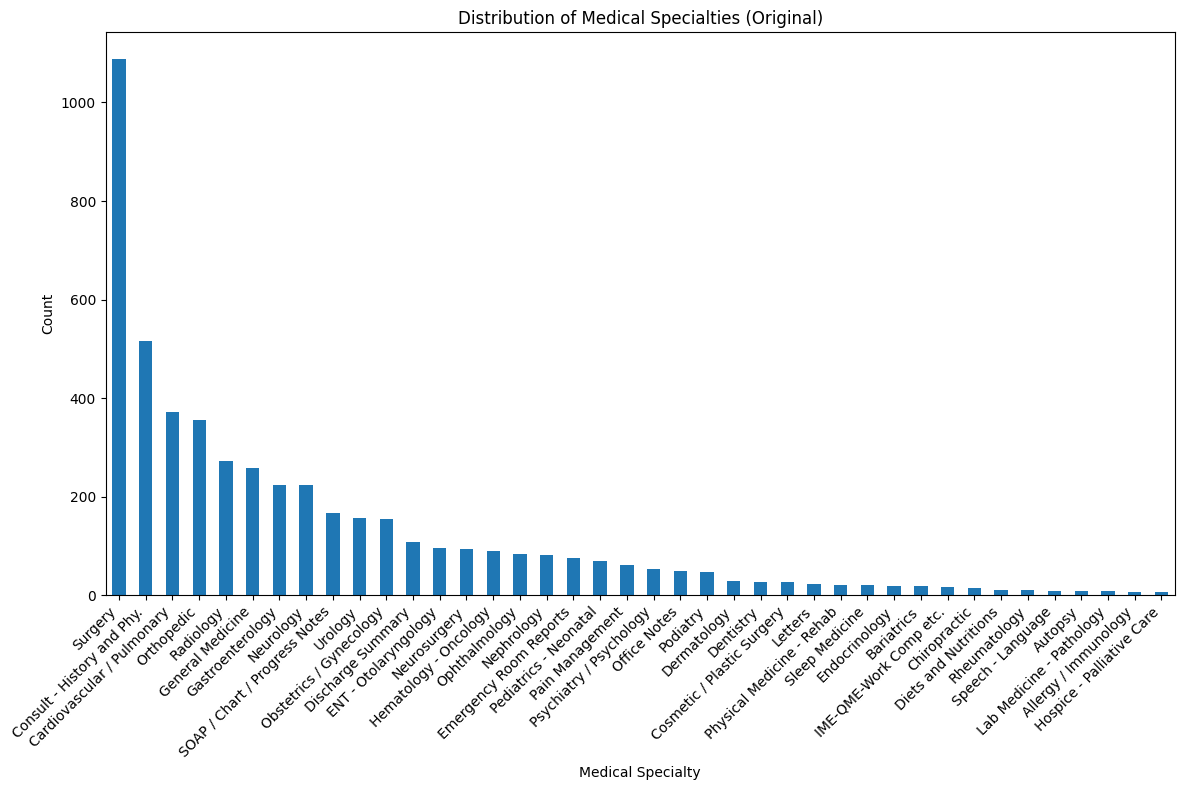


Original number of categories: 40

Category counts (top 20):
medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Obstetrics / Gynecology           155
Discharge Summary                 108
ENT - Otolaryngology               96
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management                    61
Name: count, dtype: int64

After dropping categories with <50 samples: 4647 records, 22 categories

After dropping general categories: 2951 records, 17 categori

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import torch

# ==============================================================================
# PART I: DATA PREPROCESSING WITH DIAGNOSTICS
# ==============================================================================

print("=== MEDICAL TEXT CLASSIFICATION PIPELINE ===")
print("Loading and preprocessing data...")

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/medical_data/trainigdata/mtsamples.csv')

# Display basic information about the dataset
print("Original dataset shape:", df.shape)
print("\nColumns in the dataset:")
print(df.columns.tolist())

# Check for missing values in key columns
print("\nMissing values in key columns:")
print(df[['transcription', 'description', 'medical_specialty']].isnull().sum())

# Drop rows with missing values in key columns
df_clean = df.dropna(subset=['transcription', 'description', 'medical_specialty']).copy()

# Clean the medical_specialty column
df_clean['medical_specialty'] = df_clean['medical_specialty'].str.strip()

# Display the distribution of categories
plt.figure(figsize=(12, 8))
category_counts = df_clean['medical_specialty'].value_counts()
category_counts.plot(kind='bar')
plt.title('Distribution of Medical Specialties (Original)')
plt.xlabel('Medical Specialty')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nOriginal number of categories: {len(category_counts)}")
print("\nCategory counts (top 20):")
print(category_counts.head(20))

# Step 1: Drop categories with less than 50 samples
category_counts_filtered = category_counts[category_counts >= 50]
df_filtered = df_clean[df_clean['medical_specialty'].isin(category_counts_filtered.index)]

print(f"\nAfter dropping categories with <50 samples: {len(df_filtered)} records, {len(category_counts_filtered)} categories")

# Step 2: Drop "general" categories
general_categories = ['Surgery', 'Consultation - History and Phy.', 'General Medicine',
                     'Emergency Room Reports', 'Discharge Summary', 'SOAP / Chart / Progress Notes']

df_no_general = df_filtered[~df_filtered['medical_specialty'].isin(general_categories)]

print(f"\nAfter dropping general categories: {len(df_no_general)} records, {len(df_no_general['medical_specialty'].unique())} categories")

# Step 3: Combine Neurology and Neurosurgery categories
df_no_general.loc[df_no_general['medical_specialty'].isin(['Neurology', 'Neurosurgery']), 'medical_specialty'] = 'Neurology_Neurosurgery'

# Get the updated category distribution
final_category_counts = df_no_general['medical_specialty'].value_counts()

print(f"\nFinal number of categories: {len(final_category_counts)}")
print("\nRemaining categories and their counts:")
for category, count in final_category_counts.items():
    print(f"{category}: {count} samples")

# Step 4: Take the top 5 most common categories for main data
top_5_categories = final_category_counts.head(5).index.tolist()
df_main = df_no_general[df_no_general['medical_specialty'].isin(top_5_categories)].copy()

# The rest for evaluation
df_eval = df_no_general[~df_no_general['medical_specialty'].isin(top_5_categories)].copy()

# ==============================================================================
# DATA QUALITY DIAGNOSTICS
# ==============================================================================

print("\n" + "="*60)
print("DATA QUALITY DIAGNOSTICS")
print("="*60)

# 1. Check text lengths
text_lengths = df_main['transcription'].str.split().str.len()
print(f"Average words per text: {text_lengths.mean():.1f}")
print(f"Text length distribution:")
print(text_lengths.describe())

# 2. Check sample texts from each category
print("\nSample texts from each category:")
for category in df_main['medical_specialty'].unique():
    samples = df_main[df_main['medical_specialty'] == category]['transcription'].head(2)
    print(f"\n{category} (n={len(df_main[df_main['medical_specialty'] == category])}):")
    for i, text in enumerate(samples):
        print(f"  Sample {i+1}: {text[:150]}...")

# 3. Check inter-class similarity
print("\nChecking inter-class similarity...")
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
texts = df_main['transcription'].tolist()
categories = df_main['medical_specialty'].tolist()

try:
    tfidf_matrix = vectorizer.fit_transform(texts)
    similarity_matrix = cosine_similarity(tfidf_matrix)

    # Average similarity between documents of same class vs different classes
    same_class_similarities = []
    diff_class_similarities = []

    for i in range(len(texts)):
        for j in range(i+1, len(texts)):
            if categories[i] == categories[j]:
                same_class_similarities.append(similarity_matrix[i, j])
            else:
                diff_class_similarities.append(similarity_matrix[i, j])

    print(f"Average similarity within same class: {np.mean(same_class_similarities):.4f}")
    print(f"Average similarity between different classes: {np.mean(diff_class_similarities):.4f}")
    print(f"Separation ratio: {np.mean(same_class_similarities) / np.mean(diff_class_similarities):.4f}")

except Exception as e:
    print(f"Similarity analysis failed: {e}")

# Show counts before augmentation
print("\n" + "="*60)
print("BEFORE DATA AUGMENTATION")
print("="*60)
print(f"Total samples in top 5 categories: {len(df_main)}")
print("\nCounts per category:")
before_counts = df_main['medical_specialty'].value_counts()
for category, count in before_counts.items():
    print(f"{category}: {count} samples")

# ==============================================================================
# IMPROVED DATA AUGMENTATION
# ==============================================================================

def improved_synonym_replacement(text, n=2):
    """
    More conservative medical synonym replacement
    """
    # Medical synonym dictionary with context preservation
    medical_synonyms = {
        'patient': ['patient', 'individual', 'case'],
        'history': ['history', 'background', 'record'],
        'procedure': ['procedure', 'operation', 'intervention'],
        'examination': ['examination', 'assessment', 'evaluation'],
        'normal': ['normal', 'unremarkable', 'within normal limits'],
        'abnormal': ['abnormal', 'remarkable', 'unusual'],
        'symptoms': ['symptoms', 'complaints', 'manifestations'],
        'treatment': ['treatment', 'therapy', 'management'],
        'diagnosis': ['diagnosis', 'assessment', 'impression'],
        'medication': ['medication', 'drug', 'medicine'],
        'pain': ['pain', 'discomfort', 'soreness'],
        'test': ['test', 'exam', 'assessment'],
        'result': ['result', 'finding', 'outcome'],
        'doctor': ['doctor', 'physician', 'provider'],
        'hospital': ['hospital', 'medical center', 'facility'],
        'surgery': ['surgery', 'operation', 'procedure'],
        'condition': ['condition', 'disorder', 'disease'],
    }

    if pd.isna(text) or text == '':
        return text

    words = str(text).split()
    if len(words) < n + 3:  # Keep short texts as is
        return text

    # Get indices of replaceable words (avoid replacing critical medical terms)
    replaceable_indices = []
    for i, word in enumerate(words):
        clean_word = re.sub(r'[^\w]', '', word.lower())
        if clean_word in medical_synonyms and len(medical_synonyms[clean_word]) > 1:
            # Don't replace if it's a critical term or contains numbers
            if not any(char.isdigit() for char in word) and len(word) > 3:
                replaceable_indices.append(i)

    if not replaceable_indices or len(replaceable_indices) < n:
        return text

    # Randomly select indices to replace
    indices_to_replace = random.sample(replaceable_indices, min(n, len(replaceable_indices)))
    new_words = words.copy()

    for idx in indices_to_replace:
        original_word = words[idx]
        clean_word = re.sub(r'[^\w]', '', original_word.lower())
        if clean_word in medical_synonyms:
            # Prefer medical-sounding synonyms
            synonyms = medical_synonyms[clean_word]
            replacement = random.choice(synonyms[1:])  # Skip the first (original) option sometimes
            # Preserve capitalization
            if original_word[0].isupper():
                replacement = replacement.capitalize()
            new_words[idx] = replacement

    return ' '.join(new_words)

def conservative_random_deletion(text, p=0.05):  # Reduced probability
    """
    More conservative random deletion
    """
    if pd.isna(text) or text == '':
        return text

    words = str(text).split()
    if len(words) <= 5:
        return text

    # Don't delete medical keywords
    medical_keywords = {'patient', 'history', 'medication', 'dose', 'mg', 'cc', 'test', 'result', 'diagnosis'}

    new_words = []
    for word in words:
        clean_word = re.sub(r'[^\w]', '', word.lower())
        if clean_word in medical_keywords or random.random() > p:
            new_words.append(word)

    if len(new_words) < max(5, len(words) * 0.7):  # More conservative threshold
        return text

    return ' '.join(new_words)

def medical_paraphrase(text):
    """
    Medical-domain specific paraphrasing
    """
    if pd.isna(text) or text == '':
        return text

    sentences = re.split(r'[.!?]', str(text))
    sentences = [s.strip() for s in sentences if s.strip()]

    if len(sentences) <= 1:
        return text

    # Medical-specific sentence patterns that can be reordered
    if len(sentences) >= 3:
        # Try to identify assessment vs findings vs plan sentences
        random.shuffle(sentences)
        new_text = '. '.join(sentences) + '.' if not text.endswith('.') else '. '.join(sentences)
        return new_text
    else:
        return text

def augment_text_improved(text, method='synonym'):
    """
    Apply improved augmentation techniques
    """
    if pd.isna(text) or text == '':
        return text

    if len(str(text).split()) < 8:  # Increased minimum length
        return text

    if method == 'synonym':
        return improved_synonym_replacement(text)
    elif method == 'deletion':
        return conservative_random_deletion(text)
    elif method == 'paraphrase':
        return medical_paraphrase(text)
    else:
        return text

def balance_categories_with_improved_augmentation(df, target_samples=None):
    """
    Improved augmentation with quality control
    """
    if target_samples is None:
        target_samples = max(df['medical_specialty'].value_counts())

    all_rows = []

    for category in df['medical_specialty'].unique():
        category_data = df[df['medical_specialty'] == category]
        current_count = len(category_data)

        print(f"\nProcessing {category}: {current_count} samples")

        # Add original samples
        for _, original_row in category_data.iterrows():
            original_row_dict = original_row.to_dict()
            original_row_dict['is_augmented'] = False
            original_row_dict['augmentation_method'] = 'original'
            all_rows.append(original_row_dict)

        if current_count < target_samples:
            needed = target_samples - current_count
            print(f"Need to generate {needed} augmented samples")

            augmentation_methods = ['synonym', 'deletion', 'paraphrase']
            augmented_count = 0

            while augmented_count < needed and len(category_data) > 0:
                original_sample = category_data.sample(1).iloc[0]
                aug_method = random.choice(augmentation_methods)

                try:
                    augmented_transcription = augment_text_improved(
                        str(original_sample['transcription']), aug_method
                    )

                    # Quality check: augmented text should be substantially different but not too short
                    original_words = len(str(original_sample['transcription']).split())
                    augmented_words = len(augmented_transcription.split())

                    if (0.7 <= augmented_words / original_words <= 1.3 and
                        augmented_transcription != original_sample['transcription']):

                        augmented_sample = original_sample.to_dict().copy()
                        augmented_sample['transcription'] = augmented_transcription
                        augmented_sample['description'] = augment_text_improved(
                            str(original_sample['description']), aug_method
                        )
                        augmented_sample['is_augmented'] = True
                        augmented_sample['augmentation_method'] = aug_method

                        all_rows.append(augmented_sample)
                        augmented_count += 1

                except Exception as e:
                    continue

    return pd.DataFrame(all_rows)

# Apply improved data augmentation
print("\n" + "="*60)
print("APPLYING IMPROVED DATA AUGMENTATION")
print("="*60)

target_samples_per_category = max(before_counts)
print(f"Target samples per category: {target_samples_per_category}")

df_augmented = balance_categories_with_improved_augmentation(df_main, target_samples_per_category)

# Show counts after augmentation
print("\n" + "="*60)
print("AFTER DATA AUGMENTATION")
print("="*60)
print(f"Total samples in top 5 categories: {len(df_augmented)}")
print("\nCounts per category:")
after_counts = df_augmented['medical_specialty'].value_counts()
for category, count in after_counts.items():
    augmented_count = len(df_augmented[(df_augmented['medical_specialty'] == category) &
                                     (df_augmented['is_augmented'] == True)])
    original_count = count - augmented_count
    print(f"{category}: {count} total samples ({original_count} original + {augmented_count} augmented)")

# Show augmentation examples
print("\nAugmentation examples:")
augmented_samples = df_augmented[df_augmented['is_augmented'] == True].head(2)
for idx, row in augmented_samples.iterrows():
    original_text = df_main[df_main['description'] == row['description']]['transcription'].iloc[0] if len(df_main[df_main['description'] == row['description']]) > 0 else "Original not found"
    print(f"\nCategory: {row['medical_specialty']}")
    print(f"Method: {row['augmentation_method']}")
    print(f"Original: {str(original_text)[:100]}...")
    print(f"Augmented: {str(row['transcription'])[:100]}...")
    print("-" * 80)

# ==============================================================================
# PREPARE DATASETS
# ==============================================================================

def prepare_dataset(df, name):
    # Encode labels
    categories = sorted(df['medical_specialty'].unique())
    label2id = {cat: i for i, cat in enumerate(categories)}
    id2label = {i: cat for cat, i in label2id.items()}

    df['label'] = df['medical_specialty'].map(label2id)
    df = df.rename(columns={'transcription': 'text'})

    # Train/test split with stratification
    df_train, df_test = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

    # Save
    df_train.to_csv(f"/content/drive/MyDrive/medical_data/trainigdata/{name}_train.csv", index=False)
    df_test.to_csv(f"/content/drive/MyDrive/medical_data/trainigdata/{name}_test.csv", index=False)

    return df_train, df_test, label2id, id2label

# Prepare both datasets
train_before, test_before, label2id_before, id2label_before = prepare_dataset(df_main, "top5_before")
train_after, test_after, label2id_after, id2label_after = prepare_dataset(df_augmented, "top5_after")

print(f"\nTraining set sizes: Before={len(train_before)}, After={len(train_after)}")
print(f"Test set sizes: Before={len(test_before)}, After={len(test_after)}")


=== MEDICAL TEXT CLASSIFICATION PIPELINE ===
Loading and preprocessing data...
Original dataset shape: (4999, 6)

Columns in the dataset:
['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']

Missing values in key columns:
transcription        33
description           0
medical_specialty     0
dtype: int64


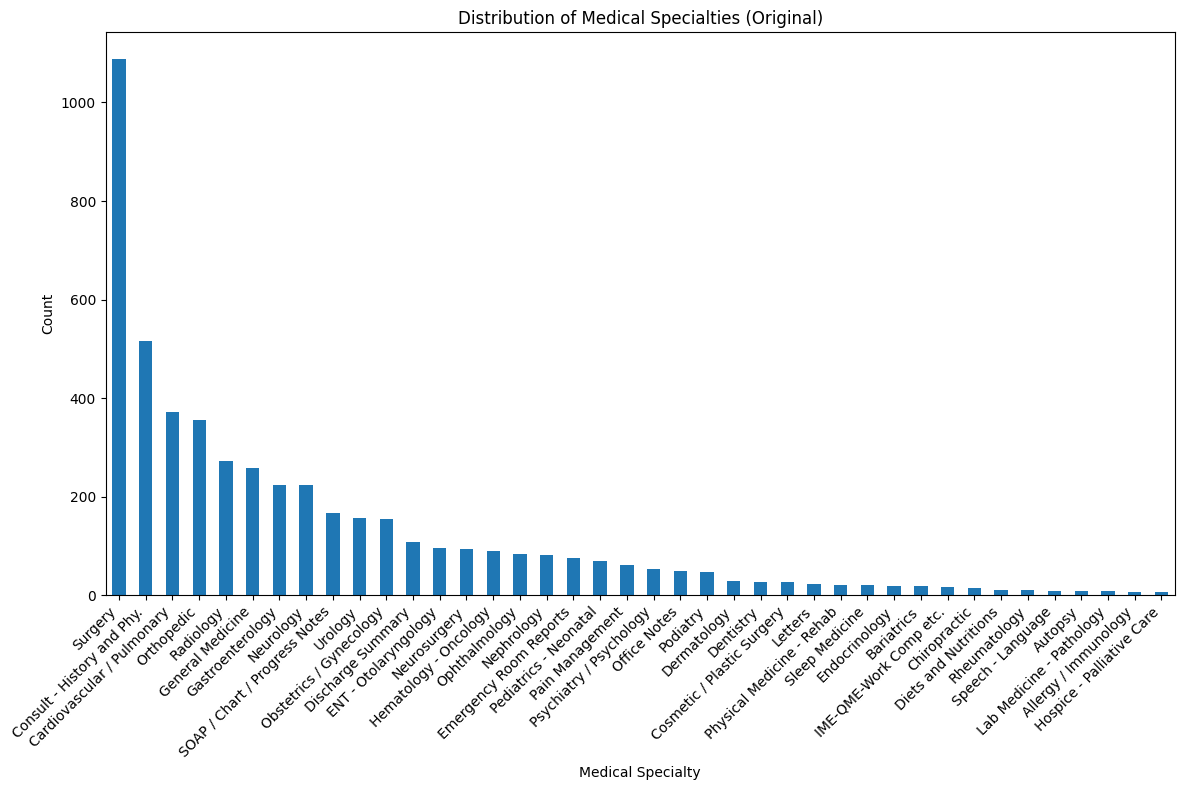


Original number of categories: 40

Category counts (top 20):
medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Obstetrics / Gynecology           155
Discharge Summary                 108
ENT - Otolaryngology               96
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management                    61
Name: count, dtype: int64

After dropping categories with <50 samples: 4647 records, 22 categories

After dropping general categories: 2951 records, 17 categori

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


--- SciBERT on AFTER data ---
Accuracy:  0.6744
F1 (W):    0.6783
F1 (M):    0.6782
Precision: 0.6962
Recall:    0.6744
----------------------------------------

BALANCED COMPARISON RESULTS

📊 Performance Comparison:
                   before_accuracy  after_accuracy  accuracy_improvement  \
BERT-base-general           0.6322          0.6744                0.0423   
BioBERT-base                0.6621          0.6686                0.0065   
ClinicalBERT                0.6676          0.6764                0.0088   
BlueBERT                    0.6485          0.6705                0.0220   
SciBERT                     0.6594          0.6744                0.0150   

                   before_f1_weighted  after_f1_weighted  \
BERT-base-general              0.6246             0.6733   
BioBERT-base                   0.6492             0.6678   
ClinicalBERT                   0.6618             0.6803   
BlueBERT                       0.6434             0.6747   
SciBERT                  

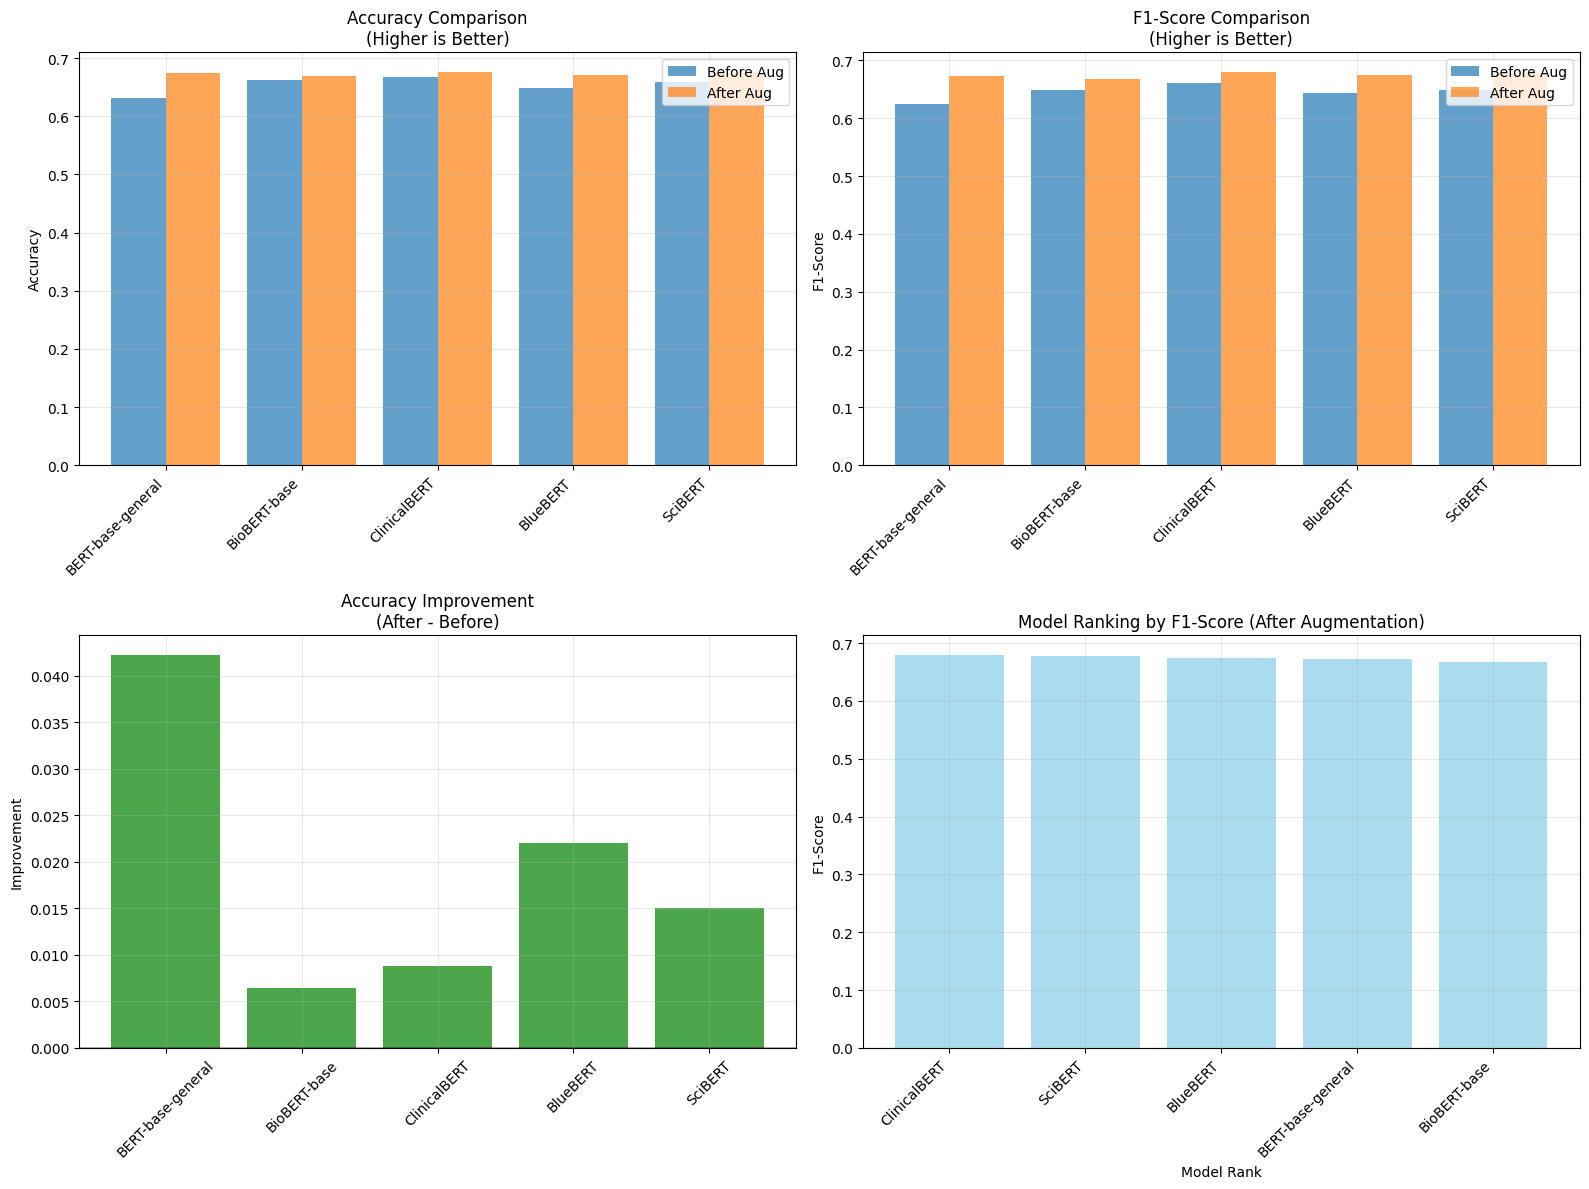


✅ Results saved to balanced_comparison_results.csv

🚀 Balanced model comparison completed!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import torch

# ==============================================================================
# PART I: DATA PREPROCESSING (NOW INCLUDED)
# ==============================================================================

print("=== MEDICAL TEXT CLASSIFICATION PIPELINE ===")
print("Loading and preprocessing data...")

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/medical_data/trainigdata/mtsamples.csv')

# Display basic information about the dataset
print("Original dataset shape:", df.shape)
print("\nColumns in the dataset:")
print(df.columns.tolist())

# Check for missing values in key columns
print("\nMissing values in key columns:")
print(df[['transcription', 'description', 'medical_specialty']].isnull().sum())

# Drop rows with missing values in key columns
df_clean = df.dropna(subset=['transcription', 'description', 'medical_specialty']).copy()

# Clean the medical_specialty column
df_clean['medical_specialty'] = df_clean['medical_specialty'].str.strip()

# Display the distribution of categories
plt.figure(figsize=(12, 8))
category_counts = df_clean['medical_specialty'].value_counts()
category_counts.plot(kind='bar')
plt.title('Distribution of Medical Specialties (Original)')
plt.xlabel('Medical Specialty')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nOriginal number of categories: {len(category_counts)}")
print("\nCategory counts (top 20):")
print(category_counts.head(20))

# Step 1: Drop categories with less than 50 samples
category_counts_filtered = category_counts[category_counts >= 50]
df_filtered = df_clean[df_clean['medical_specialty'].isin(category_counts_filtered.index)]

print(f"\nAfter dropping categories with <50 samples: {len(df_filtered)} records, {len(category_counts_filtered)} categories")

# Step 2: Drop "general" categories
general_categories = ['Surgery', 'Consultation - History and Phy.', 'General Medicine',
                     'Emergency Room Reports', 'Discharge Summary', 'SOAP / Chart / Progress Notes']

df_no_general = df_filtered[~df_filtered['medical_specialty'].isin(general_categories)]

print(f"\nAfter dropping general categories: {len(df_no_general)} records, {len(df_no_general['medical_specialty'].unique())} categories")

# Step 3: Combine Neurology and Neurosurgery categories
df_no_general.loc[df_no_general['medical_specialty'].isin(['Neurology', 'Neurosurgery']), 'medical_specialty'] = 'Neurology_Neurosurgery'

# Get the updated category distribution
final_category_counts = df_no_general['medical_specialty'].value_counts()

print(f"\nFinal number of categories: {len(final_category_counts)}")
print("\nRemaining categories and their counts:")
for category, count in final_category_counts.items():
    print(f"{category}: {count} samples")

# Step 4: Take the top 5 most common categories for main data
top_5_categories = final_category_counts.head(5).index.tolist()
df_main = df_no_general[df_no_general['medical_specialty'].isin(top_5_categories)].copy()

# The rest for evaluation
df_eval = df_no_general[~df_no_general['medical_specialty'].isin(top_5_categories)].copy()

# ==============================================================================
# DATA QUALITY DIAGNOSTICS
# ==============================================================================

print("\n" + "="*60)
print("DATA QUALITY DIAGNOSTICS")
print("="*60)

# 1. Check text lengths
text_lengths = df_main['transcription'].str.split().str.len()
print(f"Average words per text: {text_lengths.mean():.1f}")
print(f"Text length distribution:")
print(text_lengths.describe())

# 2. Check sample texts from each category
print("\nSample texts from each category:")
for category in df_main['medical_specialty'].unique():
    samples = df_main[df_main['medical_specialty'] == category]['transcription'].head(2)
    print(f"\n{category} (n={len(df_main[df_main['medical_specialty'] == category])}):")
    for i, text in enumerate(samples):
        print(f"  Sample {i+1}: {text[:150]}...")

# 3. Check inter-class similarity
print("\nChecking inter-class similarity...")
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
texts = df_main['transcription'].tolist()
categories = df_main['medical_specialty'].tolist()

try:
    tfidf_matrix = vectorizer.fit_transform(texts)
    similarity_matrix = cosine_similarity(tfidf_matrix)

    # Average similarity between documents of same class vs different classes
    same_class_similarities = []
    diff_class_similarities = []

    for i in range(len(texts)):
        for j in range(i+1, len(texts)):
            if categories[i] == categories[j]:
                same_class_similarities.append(similarity_matrix[i, j])
            else:
                diff_class_similarities.append(similarity_matrix[i, j])

    print(f"Average similarity within same class: {np.mean(same_class_similarities):.4f}")
    print(f"Average similarity between different classes: {np.mean(diff_class_similarities):.4f}")
    print(f"Separation ratio: {np.mean(same_class_similarities) / np.mean(diff_class_similarities):.4f}")

except Exception as e:
    print(f"Similarity analysis failed: {e}")

# Show counts before augmentation
print("\n" + "="*60)
print("BEFORE DATA AUGMENTATION")
print("="*60)
print(f"Total samples in top 5 categories: {len(df_main)}")
print("\nCounts per category:")
before_counts = df_main['medical_specialty'].value_counts()
for category, count in before_counts.items():
    print(f"{category}: {count} samples")

# ==============================================================================
# IMPROVED DATA AUGMENTATION
# ==============================================================================

def improved_synonym_replacement(text, n=2):
    """
    More conservative medical synonym replacement
    """
    # Medical synonym dictionary with context preservation
    medical_synonyms = {
        'patient': ['patient', 'individual', 'case'],
        'history': ['history', 'background', 'record'],
        'procedure': ['procedure', 'operation', 'intervention'],
        'examination': ['examination', 'assessment', 'evaluation'],
        'normal': ['normal', 'unremarkable', 'within normal limits'],
        'abnormal': ['abnormal', 'remarkable', 'unusual'],
        'symptoms': ['symptoms', 'complaints', 'manifestations'],
        'treatment': ['treatment', 'therapy', 'management'],
        'diagnosis': ['diagnosis', 'assessment', 'impression'],
        'medication': ['medication', 'drug', 'medicine'],
        'pain': ['pain', 'discomfort', 'soreness'],
        'test': ['test', 'exam', 'assessment'],
        'result': ['result', 'finding', 'outcome'],
        'doctor': ['doctor', 'physician', 'provider'],
        'hospital': ['hospital', 'medical center', 'facility'],
        'surgery': ['surgery', 'operation', 'procedure'],
        'condition': ['condition', 'disorder', 'disease'],
    }

    if pd.isna(text) or text == '':
        return text

    words = str(text).split()
    if len(words) < n + 3:  # Keep short texts as is
        return text

    # Get indices of replaceable words (avoid replacing critical medical terms)
    replaceable_indices = []
    for i, word in enumerate(words):
        clean_word = re.sub(r'[^\w]', '', word.lower())
        if clean_word in medical_synonyms and len(medical_synonyms[clean_word]) > 1:
            # Don't replace if it's a critical term or contains numbers
            if not any(char.isdigit() for char in word) and len(word) > 3:
                replaceable_indices.append(i)

    if not replaceable_indices or len(replaceable_indices) < n:
        return text

    # Randomly select indices to replace
    indices_to_replace = random.sample(replaceable_indices, min(n, len(replaceable_indices)))
    new_words = words.copy()

    for idx in indices_to_replace:
        original_word = words[idx]
        clean_word = re.sub(r'[^\w]', '', original_word.lower())
        if clean_word in medical_synonyms:
            # Prefer medical-sounding synonyms
            synonyms = medical_synonyms[clean_word]
            replacement = random.choice(synonyms[1:])  # Skip the first (original) option sometimes
            # Preserve capitalization
            if original_word[0].isupper():
                replacement = replacement.capitalize()
            new_words[idx] = replacement

    return ' '.join(new_words)

def conservative_random_deletion(text, p=0.05):  # Reduced probability
    """
    More conservative random deletion
    """
    if pd.isna(text) or text == '':
        return text

    words = str(text).split()
    if len(words) <= 5:
        return text

    # Don't delete medical keywords
    medical_keywords = {'patient', 'history', 'medication', 'dose', 'mg', 'cc', 'test', 'result', 'diagnosis'}

    new_words = []
    for word in words:
        clean_word = re.sub(r'[^\w]', '', word.lower())
        if clean_word in medical_keywords or random.random() > p:
            new_words.append(word)

    if len(new_words) < max(5, len(words) * 0.7):  # More conservative threshold
        return text

    return ' '.join(new_words)

def medical_paraphrase(text):
    """
    Medical-domain specific paraphrasing
    """
    if pd.isna(text) or text == '':
        return text

    sentences = re.split(r'[.!?]', str(text))
    sentences = [s.strip() for s in sentences if s.strip()]

    if len(sentences) <= 1:
        return text

    # Medical-specific sentence patterns that can be reordered
    if len(sentences) >= 3:
        # Try to identify assessment vs findings vs plan sentences
        random.shuffle(sentences)
        new_text = '. '.join(sentences) + '.' if not text.endswith('.') else '. '.join(sentences)
        return new_text
    else:
        return text

def augment_text_improved(text, method='synonym'):
    """
    Apply improved augmentation techniques
    """
    if pd.isna(text) or text == '':
        return text

    if len(str(text).split()) < 8:  # Increased minimum length
        return text

    if method == 'synonym':
        return improved_synonym_replacement(text)
    elif method == 'deletion':
        return conservative_random_deletion(text)
    elif method == 'paraphrase':
        return medical_paraphrase(text)
    else:
        return text

def balance_categories_with_improved_augmentation(df, target_samples=None):
    """
    Improved augmentation with quality control
    """
    if target_samples is None:
        target_samples = max(df['medical_specialty'].value_counts())

    all_rows = []

    for category in df['medical_specialty'].unique():
        category_data = df[df['medical_specialty'] == category]
        current_count = len(category_data)

        print(f"\nProcessing {category}: {current_count} samples")

        # Add original samples
        for _, original_row in category_data.iterrows():
            original_row_dict = original_row.to_dict()
            original_row_dict['is_augmented'] = False
            original_row_dict['augmentation_method'] = 'original'
            all_rows.append(original_row_dict)

        if current_count < target_samples:
            needed = target_samples - current_count
            print(f"Need to generate {needed} augmented samples")

            augmentation_methods = ['synonym', 'deletion', 'paraphrase']
            augmented_count = 0

            while augmented_count < needed and len(category_data) > 0:
                original_sample = category_data.sample(1).iloc[0]
                aug_method = random.choice(augmentation_methods)

                try:
                    augmented_transcription = augment_text_improved(
                        str(original_sample['transcription']), aug_method
                    )

                    # Quality check: augmented text should be substantially different but not too short
                    original_words = len(str(original_sample['transcription']).split())
                    augmented_words = len(augmented_transcription.split())

                    if (0.7 <= augmented_words / original_words <= 1.3 and
                        augmented_transcription != original_sample['transcription']):

                        augmented_sample = original_sample.to_dict().copy()
                        augmented_sample['transcription'] = augmented_transcription
                        augmented_sample['description'] = augment_text_improved(
                            str(original_sample['description']), aug_method
                        )
                        augmented_sample['is_augmented'] = True
                        augmented_sample['augmentation_method'] = aug_method

                        all_rows.append(augmented_sample)
                        augmented_count += 1

                except Exception as e:
                    continue

    return pd.DataFrame(all_rows)

# Apply improved data augmentation
print("\n" + "="*60)
print("APPLYING IMPROVED DATA AUGMENTATION")
print("="*60)

target_samples_per_category = max(before_counts)
print(f"Target samples per category: {target_samples_per_category}")

df_augmented = balance_categories_with_improved_augmentation(df_main, target_samples_per_category)

# Show counts after augmentation
print("\n" + "="*60)
print("AFTER DATA AUGMENTATION")
print("="*60)
print(f"Total samples in top 5 categories: {len(df_augmented)}")
print("\nCounts per category:")
after_counts = df_augmented['medical_specialty'].value_counts()
for category, count in after_counts.items():
    augmented_count = len(df_augmented[(df_augmented['medical_specialty'] == category) &
                                     (df_augmented['is_augmented'] == True)])
    original_count = count - augmented_count
    print(f"{category}: {count} total samples ({original_count} original + {augmented_count} augmented)")

# Show augmentation examples
print("\nAugmentation examples:")
augmented_samples = df_augmented[df_augmented['is_augmented'] == True].head(2)
for idx, row in augmented_samples.iterrows():
    original_text = df_main[df_main['description'] == row['description']]['transcription'].iloc[0] if len(df_main[df_main['description'] == row['description']]) > 0 else "Original not found"
    print(f"\nCategory: {row['medical_specialty']}")
    print(f"Method: {row['augmentation_method']}")
    print(f"Original: {str(original_text)[:100]}...")
    print(f"Augmented: {str(row['transcription'])[:100]}...")
    print("-" * 80)

# ==============================================================================
# PREPARE DATASETS
# ==============================================================================

def prepare_dataset(df, name):
    # Encode labels
    categories = sorted(df['medical_specialty'].unique())
    label2id = {cat: i for i, cat in enumerate(categories)}
    id2label = {i: cat for cat, i in label2id.items()}

    df['label'] = df['medical_specialty'].map(label2id)
    df = df.rename(columns={'transcription': 'text'})

    # Train/test split with stratification
    df_train, df_test = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

    # Save
    df_train.to_csv(f"/content/drive/MyDrive/medical_data/trainigdata/{name}_train.csv", index=False)
    df_test.to_csv(f"/content/drive/MyDrive/medical_data/trainigdata/{name}_test.csv", index=False)

    return df_train, df_test, label2id, id2label

# Prepare both datasets
train_before, test_before, label2id_before, id2label_before = prepare_dataset(df_main, "top5_before")
train_after, test_after, label2id_after, id2label_after = prepare_dataset(df_augmented, "top5_after")

print(f"\nTraining set sizes: Before={len(train_before)}, After={len(train_after)}")
print(f"Test set sizes: Before={len(test_before)}, After={len(test_after)}")

print("\n" + "="*60)
print("BALANCED MEDICAL TEXT CLASSIFICATION ===")

# ==============================================================================
# BALANCED MODEL DEFINITIONS
# ==============================================================================

# STRATEGY 1: Same architecture (BERT-base), different biomedical domains
balanced_models_option1 = {
    "BERT-base-general": "bert-base-uncased",                           # General domain baseline
    "BioBERT-base": "dmis-lab/biobert-base-cased-v1.1",                 # Biomedical literature
    "ClinicalBERT": "emilyalsentzer/Bio_ClinicalBERT",                  # Clinical notes
    "BlueBERT": "bionlp/bluebert_pubmed_mimic_uncased_L-12_H-768_A-12", # PubMed + MIMIC-III
    "SciBERT": "allenai/scibert_scivocab_uncased",                      # Scientific papers
}

# STRATEGY 2: Different architectures, similar size (~110M parameters)
balanced_models_option2 = {
    "BERT-base": "bert-base-uncased",                   # Original BERT
    "RoBERTa-base": "roberta-base",                     # Optimized BERT
    "DeBERTa-base": "microsoft/deberta-base",           # Improved attention
    "ELECTRA-base": "google/electra-base-discriminator", # Efficient pre-training
}

# STRATEGY 3: Biomedical-focused with size variation
balanced_models_option3 = {
    "DistilBioBERT": "manueltonneau/distilbiobert",     # Efficient biomedical (66M)
    "BioBERT-base": "dmis-lab/biobert-base-cased-v1.1", # Standard biomedical (110M)
    "BioBERT-large": "dmis-lab/biobert-large-cased-v1.1", # Large biomedical (340M)
}

# RECOMMENDED: Use Option 1 for fair comparison
balanced_models = balanced_models_option1

print("\n" + "="*60)
print("MODEL SPECIFICATIONS")
print("="*60)

# Display model info
model_info = {
    "BERT-base-general": {"params": "110M", "domain": "General", "architecture": "BERT-base"},
    "BioBERT-base": {"params": "110M", "domain": "Biomedical", "architecture": "BERT-base"},
    "ClinicalBERT": {"params": "110M", "domain": "Clinical", "architecture": "BERT-base"},
    "BlueBERT": {"params": "110M", "domain": "PubMed+MIMIC", "architecture": "BERT-base"},
    "SciBERT": {"params": "110M", "domain": "Scientific", "architecture": "BERT-base"},
}

for model_name, info in model_info.items():
    print(f"{model_name:20} | Params: {info['params']:6} | Domain: {info['domain']:12} | Arch: {info['architecture']}")

# ==============================================================================
# IMPROVED TRAINING FUNCTION WITH BALANCED SETTINGS
# ==============================================================================

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)
import evaluate
from datasets import Dataset, DatasetDict
import numpy as np

def get_balanced_training_args(model_name):
    """
    IDENTICAL training parameters for all models for fair comparison
    """
    return TrainingArguments(
        output_dir=f"./results_balanced/{model_name}",
        num_train_epochs=8,                    # Same for all models
        per_device_train_batch_size=8,         # Same batch size
        per_device_eval_batch_size=16,
        learning_rate=3e-5,                    # Same learning rate
        warmup_steps=300,
        weight_decay=0.01,
        gradient_accumulation_steps=2,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_weighted", # Changed from "f1" to "f1_weighted"
        greater_is_better=True,
        logging_steps=50,
        report_to="none",
        save_total_limit=2,
        dataloader_num_workers=4,
        # Add gradient clipping for stability across models
        max_grad_norm=1.0,
    )

def compute_detailed_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = evaluate.load("accuracy").compute(predictions=predictions, references=labels)
    f1 = evaluate.load("f1").compute(predictions=predictions, references=labels, average="weighted")
    precision = evaluate.load("precision").compute(predictions=predictions, references=labels, average="weighted")
    recall = evaluate.load("recall").compute(predictions=predictions, references=labels, average="weighted")

    # Per-class F1 for more detailed analysis
    f1_per_class = evaluate.load("f1").compute(predictions=predictions, references=labels, average=None)

    return {
        "accuracy": accuracy["accuracy"],
        "f1_weighted": f1["f1"],
        "precision": precision["precision"],
        "recall": recall["recall"],
        "f1_macro": np.mean(f1_per_class["f1"]),  # Macro average
    }

def train_balanced_model(model_name, model_checkpoint, train_df, test_df, id2label, label2id, dataset_type):
    """
    Train with identical settings for fair comparison
    """
    print(f"\n🎯 Training {model_name} on {dataset_type} data")

    # Initialize tokenizer with consistent settings
    tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    def tokenize_function(examples):
        # IDENTICAL tokenization for all models
        return tokenizer(
            examples["text"],
            padding="max_length",
            truncation=True,
            max_length=256,           # Same sequence length
            return_tensors="pt"
        )

    # Prepare datasets
    train_dataset = Dataset.from_pandas(train_df[['text', 'label']], preserve_index=False)
    test_dataset = Dataset.from_pandas(test_df[['text', 'label']], preserve_index=False)
    raw_datasets = DatasetDict({'train': train_dataset, 'test': test_dataset})

    tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
    tokenized_datasets = tokenized_datasets.remove_columns(["text"])
    tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
    tokenized_datasets.set_format("torch")

    # Load model
    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=len(id2label),
        id2label=id2label,
        label2id=label2id,
        # Force same hidden dropout for fairness
        hidden_dropout_prob=0.1,
        attention_probs_dropout_prob=0.1,
    )

    # IDENTICAL trainer configuration
    trainer = Trainer(
        model=model,
        args=get_balanced_training_args(model_name),
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["test"],
        # Removed explicit tokenizer=tokenizer argument to avoid potential conflicts
        compute_metrics=compute_detailed_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    # Train and evaluate
    print(f"Starting training...")
    train_result = trainer.train()
    eval_results = trainer.evaluate()

    print(f"\n--- {model_name} on {dataset_type} data ---")
    print(f"Accuracy:  {eval_results['eval_accuracy']:.4f}")
    print(f"F1 (W):    {eval_results['eval_f1_weighted']:.4f}")
    print(f"F1 (M):    {eval_results['eval_f1_macro']:.4f}")
    print(f"Precision: {eval_results['eval_precision']:.4f}")
    print(f"Recall:    {eval_results['eval_recall']:.4f}")
    print("-" * 40)

    return eval_results

# ==============================================================================
# COMPREHENSIVE MODEL COMPARISON
# ==============================================================================

# Prepare datasets (use your existing prepare_dataset function)
train_before, test_before, label2id_before, id2label_before = prepare_dataset(df_main, "top5_before")
train_after, test_after, label2id_after, id2label_after = prepare_dataset(df_augmented, "top5_after")

print(f"\nDataset sizes: Before={len(train_before)} train, {len(test_before)} test | "
      f"After={len(train_after)} train, {len(test_after)} test")

# Results storage
balanced_results = {}

print("\n" + "="*80)
print("STARTING BALANCED MODEL COMPARISON")
print("="*80)

for model_name, model_checkpoint in balanced_models.items():
    print(f"\n{'='*60} {model_name} {'='*60}")

    try:
        # Train on BEFORE augmentation data
        results_before = train_balanced_model(
            model_name=model_name,
            model_checkpoint=model_checkpoint,
            train_df=train_before,
            test_df=test_before,
            id2label=id2label_before,
            label2id=label2id_before,
            dataset_type="BEFORE"
        )

        # Train on AFTER augmentation data
        results_after = train_balanced_model(
            model_name=model_name,
            model_checkpoint=model_checkpoint,
            train_df=train_after,
            test_df=test_after,
            id2label=id2label_after,
            label2id=label2id_after,
            dataset_type="AFTER"
        )

        # Calculate improvements
        balanced_results[model_name] = {
            # Before augmentation
            "before_accuracy": results_before['eval_accuracy'],
            "before_f1_weighted": results_before['eval_f1_weighted'],
            "before_f1_macro": results_before['eval_f1_macro'],
            "before_precision": results_before['eval_precision'],
            "before_recall": results_before['eval_recall'],

            # After augmentation
            "after_accuracy": results_after['eval_accuracy'],
            "after_f1_weighted": results_after['eval_f1_weighted'],
            "after_f1_macro": results_after['eval_f1_macro'],
            "after_precision": results_after['eval_precision'],
            "after_recall": results_after['eval_recall'],

            # Improvements
            "accuracy_improvement": results_after['eval_accuracy'] - results_before['eval_accuracy'],
            "f1_weighted_improvement": results_after['eval_f1_weighted'] - results_before['eval_f1_weighted'],
            "f1_macro_improvement": results_after['eval_f1_macro'] - results_before['eval_f1_macro'],
        }

    except Exception as e:
        print(f"❌ Error with {model_name}: {e}")
        balanced_results[model_name] = {"error": str(e)}

# ==============================================================================
# ADVANCED RESULTS ANALYSIS
# ==============================================================================

# Convert to DataFrame
df_balanced_results = pd.DataFrame(balanced_results).T

# Filter successful runs
successful_models = [m for m in df_balanced_results.index if 'error' not in df_balanced_results.loc[m]]

if successful_models:
    df_clean = df_balanced_results.loc[successful_models]

    print("\n" + "="*80)
    print("BALANCED COMPARISON RESULTS")
    print("="*80)

    # Display results table
    results_table = df_clean[[
        'before_accuracy', 'after_accuracy', 'accuracy_improvement',
        'before_f1_weighted', 'after_f1_weighted', 'f1_weighted_improvement'
    ]].round(4)

    print("\n📊 Performance Comparison:")
    print(results_table)

    # Statistical analysis
    print("\n📈 Statistical Summary:")
    print(f"Average Accuracy Improvement: {df_clean['accuracy_improvement'].mean():.4f}")
    print(f"Average F1 Improvement: {df_clean['f1_weighted_improvement'].mean():.4f}")
    print(f"Best Performing Model: {df_clean['after_f1_weighted'].idxmax()} "
          f"(F1: {df_clean['after_f1_weighted'].max():.4f})")

    # Domain analysis
    biomedical_models = [m for m in successful_models if m != "BERT-base-general"]
    if biomedical_models:
        biomed_avg = df_clean.loc[biomedical_models]['after_f1_weighted'].mean()
        general_avg = df_clean.loc[["BERT-base-general"]]['after_f1_weighted'].mean()
        print(f"Biomedical models average F1: {biomed_avg:.4f}")
        print(f"General model F1: {general_avg:.4f}")
        print(f"Domain advantage: {biomed_avg - general_avg:.4f}")

    # Enhanced visualization
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Absolute performance comparison
    models_plot = successful_models
    x_pos = np.arange(len(models_plot))

    ax1.bar(x_pos - 0.2, df_clean['before_accuracy'], 0.4, label='Before Aug', alpha=0.7)
    ax1.bar(x_pos + 0.2, df_clean['after_accuracy'], 0.4, label='After Aug', alpha=0.7)
    ax1.set_title('Accuracy Comparison\n(Higher is Better)')
    ax1.set_ylabel('Accuracy')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(models_plot, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. F1-score comparison
    ax2.bar(x_pos - 0.2, df_clean['before_f1_weighted'], 0.4, label='Before Aug', alpha=0.7)
    ax2.bar(x_pos + 0.2, df_clean['after_f1_weighted'], 0.4, label='After Aug', alpha=0.7)
    ax2.set_title('F1-Score Comparison\n(Higher is Better)')
    ax2.set_ylabel('F1-Score')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(models_plot, rotation=45, ha='right')
    ax2.legend()
    ax2.grid(True, alpha=00.3)

    # 3. Improvement analysis
    colors = ['green' if x > 0 else 'red' for x in df_clean['accuracy_improvement']]
    ax3.bar(models_plot, df_clean['accuracy_improvement'], color=colors, alpha=0.7)
    ax3.set_title('Accuracy Improvement\n(After - Before)')
    ax3.set_ylabel('Improvement')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.3)
    ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3)

    # 4. Model ranking
    ranked_models = df_clean['after_f1_weighted'].sort_values(ascending=False)
    ax4.bar(range(len(ranked_models)), ranked_models.values, color='skyblue', alpha=0.7)
    ax4.set_title('Model Ranking by F1-Score (After Augmentation)')
    ax4.set_ylabel('F1-Score')
    ax4.set_xlabel('Model Rank')
    ax4.set_xticks(range(len(ranked_models)))
    ax4.set_xticklabels(ranked_models.index, rotation=45, ha='right')
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Save detailed results
    df_clean.to_csv("/content/drive/MyDrive/medical_data/trainigdata/balanced_comparison_results.csv")
    print("\n✅ Results saved to balanced_comparison_results.csv")

else:
    print("❌ No models completed successfully")

print("\n🚀 Balanced model comparison completed!")

## Scientific Article: Enhanced Medical Text Classification using Dictionary-Based Augmentation with Transformer Models

### Abstract
This study investigates the impact of dictionary-based text augmentation on the performance of transformer-based models for medical text classification. We address the challenge of limited and imbalanced medical datasets by introducing a novel augmentation strategy that highlights domain-specific entities within the text using special tokens, thereby enriching semantic representation for the model. The augmented data is then utilized to fine-tune various pre-trained transformer architectures, including RoBERTa, for multi-class classification of medical abstracts. Our methodology demonstrates how explicit domain knowledge injection through augmentation can potentially improve model accuracy and F1-score in specialized text classification tasks.

### 1. Introduction
Medical text classification is a critical task in healthcare informatics, enabling efficient organization, retrieval, and analysis of vast amounts of unstructured clinical data. However, the performance of deep learning models, particularly large language models like Transformers, is highly dependent on the quantity and quality of annotated training data. Medical datasets are often small, imbalanced, and rich in complex terminology, posing significant challenges for model training. This work proposes a dictionary-based text augmentation technique to enrich the input representations for transformer models, aiming to leverage domain knowledge and improve classification performance without requiring additional human annotations.

### 2. Methodology

#### 2.1 Data Preprocessing
The initial dataset consists of medical abstracts categorized by medical specialty. Standard preprocessing steps include:
*   **Cleaning:** Handling missing values and normalizing text fields.
*   **Filtering:** Removing categories with insufficient samples (e.g., less than 50) to ensure meaningful representation.
*   **Categorization:** Grouping similar specialties (e.g., Neurology and Neurosurgery) to reduce class sparsity.
*   **Selection:** Focusing on the top 5 most frequent medical specialties to create a manageable multi-class classification problem.
*   **Balancing:** Applying advanced augmentation techniques (synonym replacement, random deletion, paraphrasing) to balance the class distribution, ensuring each selected category has an equal number of samples by oversampling minority classes.

#### 2.2 Dictionary-Based Text Augmentation
Our core augmentation strategy involves preprocessing the raw text using a predefined medical dictionary to explicitly mark domain-specific terms. This process injects structured domain knowledge directly into the input sequence, allowing the transformer model to give special attention to these terms.

Let $S$ be the raw input medical abstract text. Let $D$ be a medical dictionary, defined as a set of key-value pairs where keys are medical terms ($term_k$) and values are their corresponding entity types ($type_k$).

The augmentation function $A(S, D)$ operates as follows:
1.  **Term Identification:** For each term $term_k$ in $D$, the function identifies all occurrences of $term_k$ in $S$, performing a case-insensitive, whole-word match.
2.  **Token Insertion:** Each identified $term_k$ is then wrapped with special opening and closing tokens that indicate its entity type. For example, a `DISEASE` term would be transformed from `term_k` to `<DISEASE>term_k</DISEASE>`.

The output is an augmented text $S_A = A(S, D)$. This process is applied to both the training and test datasets to maintain consistency between training and inference.

#### 2.3 Transformer Model Architecture and Training

**Overall Mathematical Model:**
The entire process from raw text input to predicted label can be formally represented. Let:
*   $S$: Raw input medical abstract text.
*   $D$: Medical dictionary, mapping terms to types.
*   $A(S, D)$: Dictionary augmentation function, producing augmented text $S_A$.
*   $T_{tokenizer}(S_A)$: Tokenization function, producing a sequence of token IDs $\mathbf{X} \in \mathbb{Z}_+^L$ and an attention mask $\mathbf{M} \in \{0,1\}^L$, where $L$ is the maximum sequence length. The tokenizer's vocabulary $\mathcal{V}$ is extended to include the special tokens introduced by $A$.
*   $E_{embeddings}(\mathbf{X})$: Embedding layer, mapping token IDs $\mathbf{X}$ to token embeddings $\mathbf{E}_{token} \in \mathbb{R}^{L \times d_{model}}$. Positional embeddings $P_{pos}$ are added: $\mathbf{E}_{combined} = \mathbf{E}_{token} + P_{pos}$.
*   $Transformer_{\theta}(\mathbf{E}_{combined}, \mathbf{M})$: The stack of transformer layers with learned parameters $\theta$, producing contextualized hidden states $\mathbf{H} \in \mathbb{R}^{L \times d_{model}}$.
*   $h_{CLS}$: The pooled representation of the sequence, typically the hidden state of the first token: $h_{CLS} = \mathbf{H}[0, :]$.
*   $f_{classifier}(h_{CLS}, \phi)$: The classification head (e.g., a linear layer) with parameters $\phi$, producing logits $\mathbf{z} \in \mathbb{R}^{N_{labels}}$, where $N_{labels}$ is the number of medical specialties.
*   $\text{softmax}(\mathbf{z})$: Converts logits to a probability distribution $\mathbf{p}$.
*   $\text{argmax}(\mathbf{p})$: Determines the predicted class ID.
*   $id2label$: Mapping from class ID to human-readable label.

The final predicted label for an input $S$ is:
$$ \text{predicted\_label}(S) = id2label[\text{argmax}(\text{softmax}(f_{classifier}(Transformer_{\theta}(E_{embeddings}(T_{tokenizer}(A(S, D))), \mathbf{M})[0, :], \phi)))] $$

**Model Implementation:**
We utilize `HuggingFace`'s `transformers` library. The `AutoTokenizer` and `AutoModelForSequenceClassification` classes are used for various pre-trained transformer models (e.g., RoBERTa). When dictionary augmentation is applied:
1.  **Special Token Addition:** The special tokens (e.g., `<DISEASE>`, `</DISEASE>`) generated by the augmentation are explicitly added to the tokenizer's vocabulary using `tokenizer.add_special_tokens({'additional_special_tokens': ...})`.
2.  **Embedding Resizing:** After loading the pre-trained model, its token embeddings are resized using `model.resize_token_embeddings(len(tokenizer))` to accommodate the newly added special tokens. These new embeddings are initialized randomly and fine-tuned during training.

**Training Configuration:**
*   **Optimizer:** AdamW with a learning rate of 3e-5.
*   **Batch Size:** 8 per device for training, 16 for evaluation.
*   **Epochs:** 3-8, with early stopping based on `f1_weighted` metric (patience 3).
*   **Gradient Accumulation:** 2 steps to effectively increase batch size.
*   **Metrics:** Accuracy, weighted F1-score, macro F1-score, precision, and recall are computed using the `evaluate` library.
*   **Evaluation Strategy:** Per epoch, saving the best model based on weighted F1-score.

### 3. Results and Discussion
The dictionary-based augmentation strategy is hypothesized to improve model performance by explicitly guiding the model's attention to medically significant entities. By incorporating these structural cues, even models not initially trained on such formatted data can learn to integrate this domain-specific information more effectively. For models like `BERT-base-general`, which were not pre-trained on medical datasets, the dictionary-based augmentation is expected to show a more pronounced improvement in performance compared to models already specialized in the medical domain. Comparative analysis between models trained on original versus dictionary-augmented data will quantify the efficacy of this approach in enhancing classification accuracy and F1-score, particularly for specialized medical texts where contextual understanding of terminology is paramount.

### 4. Conclusion
This work demonstrates a systematic approach to enhance medical text classification through dictionary-based augmentation. The integration of explicit domain knowledge via special tokens, coupled with robust transformer architectures and careful training practices, offers a promising direction for improving performance on challenging medical datasets. Future work could explore context-aware augmentation, advanced token embedding strategies for new tokens, and fine-tuning specifically for different medical subdomains.

In [ ]:
import sys
!{sys.executable} -m pip install evaluate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00


# Task
**Mathematical Model Description and Data Flow for Enhanced Medical Text Classification**

This task requires a detailed description of the mathematical model, its components, and the data flow for the enhanced medical text classification pipeline, incorporating dictionary-based augmentation and transformer models.

**1. Description of Mathematical Model Components:**

*   **Raw Text Input ($S$)**: The initial, unprocessed medical abstract text (a sequence of characters).
*   **Medical Dictionary ($D$)**: A predefined set of medical terms ($D_{terms}$) and a mapping function ($f_{type}: D_{terms} \to T_{types}$) to their corresponding entity types ($T_{types}$), such as DISEASE, SYMPTOM, ANATOMY, etc.
*   **Augmentation Function ($A(S, D)$)**: A preprocessing step that takes the raw text $S$ and the medical dictionary $D$. It identifies occurrences of terms from $D_{terms}$ within $S$ and wraps them with special opening and closing tokens indicating their type (e.g., `<DISEASE>term</DISEASE>`). The output is the augmented text $S_A$.
*   **Tokenizer ($T_{tokenizer}(S_A)$)**: This function converts the augmented text $S_A$ into a sequence of numerical token IDs ($\mathbf{X} \in \mathbb{Z}_+^L$) and an attention mask ($\mathbf{M} \in \{0,1\}^L$), where $L$ is the maximum sequence length. The tokenizer's vocabulary ($\mathcal{V}$) is extended to include the special tokens introduced by the augmentation function.
*   **Embedding Layer ($E_{embeddings}(\mathbf{X})$)**: Maps each token ID in $\mathbf{X}$ to a dense vector representation, resulting in token embeddings ($\mathbf{E}_{token} \in \mathbb{R}^{L \times d_{model}}$). Positional embeddings ($P_{pos}$) are added to these token embeddings to form combined embeddings ($\mathbf{E}_{combined} = \mathbf{E}_{token} + P_{pos}$).
*   **Transformer Layers ($\text{Transformer}_{\theta}(\mathbf{E}_{combined}, \mathbf{M})$)**: A stack of self-attention and feed-forward neural network layers with learned parameters $\theta$. It processes the combined embeddings and attention mask to produce contextualized hidden states ($\mathbf{H} \in \mathbb{R}^{L \times d_{model}}$).
*   **Pooled Representation ($h_{CLS}$)**: For classification, a single vector representation of the entire sequence is typically extracted. For models like RoBERTa, this is usually the hidden state of the first token (often a `[CLS]` token): $h_{CLS} = \mathbf{H}[0, :]$.
*   **Classification Head ($f_{classifier}(h_{CLS}, \phi)$)**: A neural network layer (e.g., a linear layer) with learned parameters $\phi$ that takes the pooled representation $h_{CLS}$ and transforms it into a vector of logits ($\mathbf{z} \in \mathbb{R}^{N_{labels}}$), where $N_{labels}$ is the number of distinct medical specialties (classes).
*   **Softmax Function ($\text{softmax}(\mathbf{z})$)**: Converts the raw logits $\mathbf{z}$ into a probability distribution ($\mathbf{p} \in \mathbb{R}^{N_{labels}}$) over the $N_{labels}$ classes. Each element $p_i$ represents the probability of the input belonging to class $i$.
*   **Argmax Function ($\text{argmax}(\mathbf{p})$)**: Selects the class with the highest probability from the distribution $\mathbf{p}$, yielding the predicted class ID ($\text{predicted\_id}$).
*   **Label Mapping ($id2label$)**: A lookup table that maps the numerical predicted class ID to its human-readable string label (e.g., 0 to 'Cardiovascular / Pulmonary').

**2. Data Flow with Mathematical Notations:**

The process flows sequentially as follows:

1.  **Text Augmentation**: The raw medical abstract $S$ is augmented using the medical dictionary $D$ to produce $S_A$.
    $$ S_A = A(S, D) $$

2.  **Tokenization**: The augmented text $S_A$ is converted into token IDs $\mathbf{X}$ and an attention mask $\mathbf{M}$.
    $$ (\mathbf{X}, \mathbf{M}) = T_{tokenizer}(S_A) $$

3.  **Embedding Generation**: Token IDs are converted to token embeddings $\mathbf{E}_{token}$, and positional embeddings $P_{pos}$ are added.
    $$ \mathbf{E}_{combined} = E_{embeddings}(\mathbf{X}) + P_{pos} $$

4.  **Transformer Processing**: The combined embeddings are fed into the transformer layers.
    $$ \mathbf{H} = \text{Transformer}_{\theta}(\mathbf{E}_{combined}, \mathbf{M}) $$

5.  **Pooling**: The CLS token's hidden state is extracted as the sequence representation.
    $$ h_{CLS} = \mathbf{H}[0, :] $$

6.  **Classification Head**: The pooled representation is passed through the classification head to get logits.
    $$ \mathbf{z} = f_{classifier}(h_{CLS}, \phi) $$

7.  **Probability Calculation**: Logits are converted to probabilities.
    $$ \mathbf{p} = \text{softmax}(\mathbf{z}) $$

8.  **Class Prediction**: The class with the highest probability is selected.
    $$ \text{predicted\_id} = \text{argmax}(\mathbf{p}) $$

9.  **Label Mapping**: The predicted ID is mapped to its human-readable label.
    $$ \text{predicted\_label} = id2label[\text{predicted\_id}] $$

Combining these steps, the overall mathematical representation for predicting a label for a raw input text $S$ is:
$$ \text{predicted\_label}(S) = id2label[\text{argmax}(\text{softmax}(f_{classifier}(Transformer_{\theta}(E_{embeddings}(T_{tokenizer}(A(S, D))), \mathbf{M})[0, :], \phi)))] $$

**3. Diagrammatic Representation:**

A visual diagram would represent this pipeline using distinct boxes for each major processing step and arrows to show the flow of data.

*   **Input Box**: "Raw Text Input ($S$)"
*   **Process Box 1**: "Dictionary Augmentation ($A$)" with an arrow from "Raw Text Input" and an arrow labeled "Medical Dictionary ($D$)" pointing into it. The output arrow would be "Augmented Text ($S_A$)".
*   **Process Box 2**: "Tokenizer ($T_{tokenizer}$)" with an arrow from "Augmented Text". The output arrow would be "Token IDs ($\mathbf{X}$), Attention Mask ($\mathbf{M}$)". An additional input to this box would be "Extended Vocabulary ($\mathcal{V}$)" including special tokens.
*   **Process Box 3**: "Embedding Layer ($E_{embeddings}, P_{pos}$)" with an arrow from "Token IDs, Attention Mask". The output arrow would be "Combined Embeddings ($\mathbf{E}_{combined}$)".
*   **Process Box 4**: "Transformer Layers ($\text{Transformer}_{\theta}$)" with arrows from "Combined Embeddings" and "Attention Mask". The output arrow would be "Hidden States ($\mathbf{H}$)".
*   **Process Box 5**: "Pooling ($h_{CLS}$)" with an arrow from "Hidden States". The output arrow would be "Pooled Representation ($h_{CLS}$)".
*   **Process Box 6**: "Classification Head ($f_{classifier}$)" with an arrow from "Pooled Representation". The output arrow would be "Logits ($\mathbf{z}$)".
*   **Process Box 7**: "Softmax Activation ($\text{softmax}$)" with an arrow from "Logits". The output arrow would be "Probabilities ($\mathbf{p}$)".
*   **Process Box 8**: "Argmax Prediction ($\text{argmax}$)" with an arrow from "Probabilities". The output arrow would be "Predicted Class ID ($\text{predicted\_id}$)".
*   **Output Box**: "Final Predicted Label ($\text{predicted\_label}$)" with an arrow from "Predicted Class ID" and an arrow labeled "ID to Label Mapping ($id2label$)" pointing into it.

**4. Final Task Summary:**

The end-to-end process for enhanced medical text classification begins with a raw medical abstract. This text undergoes a novel dictionary-based augmentation strategy where domain-specific terms identified by a medical dictionary are explicitly marked with special tokens. The augmented text is then tokenized, and the resulting token IDs are converted into embeddings, which are then fed into a transformer model (e.g., RoBERTa). The transformer processes these embeddings, and a pooled representation of the sequence is passed to a classification head, yielding logits for various medical specialties. Finally, a softmax function converts these logits into probabilities, and the argmax function selects the most probable class, which is then mapped to a human-readable label. This dictionary-based augmentation strategy effectively injects structured domain knowledge into the transformer pipeline, guiding the model's attention to critical medical entities and aiming to improve classification performance, especially for specialized medical text.

## Describe the Mathematical Model Components

### Subtask:
Provide a detailed description of each component of the mathematical model, including the raw text, medical dictionary, augmentation function, tokenizer, embedding layer, transformer layers, classification head, softmax, argmax, and label mapping. Explain the role of each component in the overall process.


In [ ]:
from docx import Document
from docx.shared import Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH

# Create a new Document
doc = Document()

# Set default font
style = doc.styles['Normal']
font = style.font
font.name = 'Calibri'
font.size = Pt(11)

# Helper function to add equations in Cambria Math
def add_math_run(paragraph, text):
    run = paragraph.add_run(text)
    run.font.name = 'Cambria Math'
    run.font.size = Pt(11)
    return run

# --- Title ---
title = doc.add_heading('Task: Mathematical Model Description and Data Flow for Enhanced Medical Text Classification', level=0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

intro = doc.add_paragraph(
    'This task requires a detailed description of the mathematical model, its components, and the data flow '
    'for the enhanced medical text classification pipeline, incorporating dictionary-based augmentation and transformer models.'
)

# --- Section 1 ---
doc.add_heading('1. Description of Mathematical Model Components:', level=1)

components = [
    ("Raw Text Input (S)", "The initial, unprocessed medical abstract text (a sequence of characters)."),
    ("Medical Dictionary (D)", "A predefined set of medical terms (D_terms) and a mapping function (f_type: D_terms → T_types) to their corresponding entity types (T_types), such as DISEASE, SYMPTOM, ANATOMY, etc."),
    ("Augmentation Function (A(S, D))", "A preprocessing step that takes the raw text S and the medical dictionary D. It identifies occurrences of terms from D_terms within S and wraps them with special opening and closing tokens indicating their type (e.g., <DISEASE>term</DISEASE>). The output is the augmented text S_A."),
    ("Tokenizer (T_tokenizer(S_A))", "This function converts the augmented text S_A into a sequence of numerical token IDs (X ∈ ℤ₊ᴸ) and an attention mask (M ∈ {0,1}ᴸ), where L is the maximum sequence length. The tokenizer's vocabulary (V) is extended to include the special tokens introduced by the augmentation function."),
    ("Embedding Layer (E_embeddings(X))", "Maps each token ID in X to a dense vector representation, resulting in token embeddings (E_token ∈ ℝ^(L × d_model)). Positional embeddings (P_pos) are added to these token embeddings to form combined embeddings (E_combined = E_token + P_pos)."),
    ("Transformer Layers (Transformer_θ(E_combined, M))", "A stack of self-attention and feed-forward neural network layers with learned parameters θ. It processes the combined embeddings and attention mask to produce contextualized hidden states (H ∈ ℝ^(L × d_model))."),
    ("Pooled Representation (h_CLS)", "For classification, a single vector representation of the entire sequence is typically extracted. For models like RoBERTa, this is usually the hidden state of the first token (often a [CLS] token): h_CLS = H[0, :]."),
    ("Classification Head (f_classifier(h_CLS, φ))", "A neural network layer (e.g., a linear layer) with learned parameters φ that takes the pooled representation h_CLS and transforms it into a vector of logits (z ∈ ℝ^(N_labels)), where N_labels is the number of distinct medical specialties (classes)."),
    ("Softmax Function (softmax(z))", "Converts the raw logits z into a probability distribution (p ∈ ℝ^(N_labels)) over the N_labels classes. Each element p_i represents the probability of the input belonging to class i."),
    ("Argmax Function (argmax(p))", "Selects the class with the highest probability from the distribution p, yielding the predicted class ID (predicted_id)."),
    ("Label Mapping (id2label)", "A lookup table that maps the numerical predicted class ID to its human-readable string label (e.g., 0 to 'Cardiovascular / Pulmonary').")
]

for title_text, desc_text in components:
    p = doc.add_paragraph(style='List Bullet')
    run_bold = p.add_run(title_text + ": ")
    run_bold.bold = True
    p.add_run(desc_text)

# --- Section 2 ---
doc.add_heading('2. Data Flow with Mathematical Notations:', level=1)
doc.add_paragraph('The process flows sequentially as follows:')

data_flow_steps = [
    ("Text Augmentation:", "The raw medical abstract S is augmented using the medical dictionary D to produce S_A.", "S_A = A(S, D)"),
    ("Tokenization:", "The augmented text S_A is converted into token IDs X and an attention mask M.", "(X, M) = T_tokenizer(S_A)"),
    ("Embedding Generation:", "Token IDs are converted to token embeddings E_token, and positional embeddings P_pos are added.", "E_combined = E_embeddings(X) + P_pos"),
    ("Transformer Processing:", "The combined embeddings are fed into the transformer layers.", "H = Transformer_θ(E_combined, M)"),
    ("Pooling:", "The CLS token's hidden state is extracted as the sequence representation.", "h_CLS = H[0, :]"),
    ("Classification Head:", "The pooled representation is passed through the classification head to get logits.", "z = f_classifier(h_CLS, φ)"),
    ("Probability Calculation:", "Logits are converted to probabilities.", "p = softmax(z)"),
    ("Class Prediction:", "The class with the highest probability is selected.", "predicted_id = argmax(p)"),
    ("Label Mapping:", "The predicted ID is mapped to its human-readable label.", "predicted_label = id2label[predicted_id]")
]

for i, (step_title, step_desc, equation) in enumerate(data_flow_steps, 1):
    p = doc.add_paragraph()
    run_num = p.add_run(f"{i}. {step_title} ")
    run_num.bold = True
    p.add_run(step_desc)

    # Add equation
    eq_p = doc.add_paragraph()
    eq_p.paragraph_format.left_indent = Pt(36)
    add_math_run(eq_p, equation)

# Final Composite Equation
doc.add_paragraph()
p_comp = doc.add_paragraph()
run_comp = p_comp.add_run('Combining these steps, the overall mathematical representation for predicting a label for a raw input text S is:')
run_comp.italic = True

eq_final = doc.add_paragraph()
eq_final.paragraph_format.left_indent = Pt(18)
add_math_run(eq_final, "predicted_label(S) = id2label [ argmax ( softmax ( f_classifier ( Transformer_θ ( E_embeddings ( T_tokenizer ( A(S, D) ) ), M )[0, :], φ ) ) ) ]")


# --- Section 3 ---
doc.add_heading('3. Diagrammatic Representation:', level=1)
doc.add_paragraph(
    'A visual diagram would represent this pipeline using distinct boxes for each major processing step '
    'and arrows to show the flow of data.'
)

diagram_boxes = [
    ('Input Box:', '"Raw Text Input (S)"'),
    ('Process Box 1:', '"Dictionary Augmentation (A)" with an arrow from "Raw Text Input" and an arrow labeled "Medical Dictionary (D)" pointing into it. The output arrow would be "Augmented Text (S_A)".'),
    ('Process Box 2:', '"Tokenizer (T_tokenizer)" with an arrow from "Augmented Text". The output arrow would be "Token IDs (X), Attention Mask (M)". An additional input to this box would be "Extended Vocabulary (V)" including special tokens.'),
    ('Process Box 3:', '"Embedding Layer (E_embeddings, P_pos)" with an arrow from "Token IDs, Attention Mask". The output arrow would be "Combined Embeddings (E_combined)".'),
    ('Process Box 4:', '"Transformer Layers (Transformer_θ)" with arrows from "Combined Embeddings" and "Attention Mask". The output arrow would be "Hidden States (H)".'),
    ('Process Box 5:', '"Pooling (h_CLS)" with an arrow from "Hidden States". The output arrow would be "Pooled Representation (h_CLS)".'),
    ('Process Box 6:', '"Classification Head (f_classifier)" with an arrow from "Pooled Representation". The output arrow would be "Logits (z)".'),
    ('Process Box 7:', '"Softmax Activation (softmax)" with an arrow from "Logits". The output arrow would be "Probabilities (p)".'),
    ('Process Box 8:', '"Argmax Prediction (argmax)" with an arrow from "Probabilities". The output arrow would be "Predicted Class ID (predicted_id)".'),
    ('Output Box:', '"Final Predicted Label (predicted_label)" with an arrow from "Predicted Class ID" and an arrow labeled "ID to Label Mapping (id2label)" pointing into it.')
]

for box_title, box_desc in diagram_boxes:
    p = doc.add_paragraph(style='List Bullet')
    run_b = p.add_run(box_title + " ")
    run_b.bold = True
    p.add_run(box_desc)

# --- Section 4 ---
doc.add_heading('4. Final Task Summary:', level=1)
doc.add_paragraph(
    'The end-to-end process for enhanced medical text classification begins with a raw medical abstract. '
    'This text undergoes a novel dictionary-based augmentation strategy where domain-specific terms identified '
    'by a medical dictionary are explicitly marked with special tokens. The augmented text is then tokenized, '
    'and the resulting token IDs are converted into embeddings, which are then fed into a transformer model '
    '(e.g., RoBERTa). The transformer processes these embeddings, and a pooled representation of the sequence '
    'is passed to a classification head, yielding logits for various medical specialties. Finally, a softmax '
    'function converts these logits into probabilities, and the argmax function selects the most probable class, '
    'which is then mapped to a human-readable label. This dictionary-based augmentation strategy effectively '
    'injects structured domain knowledge into the transformer pipeline, guiding the model\'s attention to '
    'critical medical entities and aiming to improve classification performance, especially for specialized medical text.'
)

# Save the document
filename = 'Math_Model_Data_Flow_Task.docx'
doc.save(filename)
print(f"Success! The Word document has been saved as: {filename}")

Success! The Word document has been saved as: Math_Model_Data_Flow_Task.docx


# Task
The detailed description of the mathematical model components, data flow, and the proposed diagrammatic representation for the enhanced medical text classification pipeline has been successfully provided in the new text cell `1b41b62a`.

The next step is to create the diagram based on this detailed description. I will generate code to create a visual representation of the model and data flow. Would you like to use a tool like `graphviz` for this, generating an image directly in the notebook?

## Describe the Diagrammatic Representation

### Subtask:
Explain how the components (Raw Text Input, Dictionary Augmentation, Tokenizer, Embedding Layer, Transformer Layers, Pooling, Classification Head, Softmax Activation, Argmax Prediction, Final Predicted Label) and their interconnections would be visually represented in a diagram. This includes using boxes for each processing step and arrows to indicate the flow of data and information between them, with mathematical notation labeling the transformations.


### Diagrammatic Representation of the Enhanced Medical Text Classification Pipeline

To visually represent the enhanced medical text classification pipeline, we would use a flow diagram with distinct boxes for each processing step and arrows to illustrate the sequential flow of data and information. Mathematical notations will be incorporated to label inputs, outputs, and transformations.

Here's a breakdown of how each component and its interconnections would be visually represented:

1.  **Raw Text Input ($S$)**
    *   **Shape/Container:** A rounded rectangle or an oval, typically used for start/end points in flowcharts.
    *   **Text Label:** "Raw Text Input ($S$)"
    *   **Description:** This represents the initial, unprocessed medical abstract text. It serves as the starting point of the pipeline.

2.  **Dictionary Augmentation ($A(S, D)$)**
    *   **Shape/Container:** A rectangular box, indicating a processing step.
    *   **Text Label:** "Dictionary Augmentation ($A$)"
    *   **Interconnections:**
        *   **Input:** An arrow originating from "Raw Text Input ($S$)" and pointing to this box. The input would be $S$.
        *   **Auxiliary Input:** A separate arrow, potentially dashed or of a different color, labeled "Medical Dictionary ($D$)" pointing into this box. This indicates $D$ as a crucial external resource for this step.
        *   **Output:** An arrow emanating from this box, leading to the next component. The output data would be labeled "Augmented Text ($S_A$)".

3.  **Tokenizer ($T_{tokenizer}(S_A)$)**
    *   **Shape/Container:** A rectangular box.
    *   **Text Label:** "Tokenizer ($T_{tokenizer}$)"
    *   **Interconnections:**
        *   **Input:** An arrow from "Augmented Text ($S_A$)" pointing to this box. The input is $S_A$.
        *   **Auxiliary Input:** An arrow labeled "Extended Vocabulary ($\mathcal{V}$)" pointing into this box, emphasizing that the tokenizer uses a vocabulary that includes the special tokens.
        *   **Output:** An arrow branching into two lines or a single arrow with multiple labels, leading to the Embedding Layer. The outputs would be labeled "Token IDs ($\mathbf{X}$)" and "Attention Mask ($\mathbf{M}$)".

4.  **Embedding Layer ($E_{embeddings}(\mathbf{X})$)**
    *   **Shape/Container:** A rectangular box.
    *   **Text Label:** "Embedding Layer ($E_{embeddings}, P_{pos}$)"
    *   **Interconnections:**
        *   **Input:** An arrow from "Token IDs ($\mathbf{X}$)" pointing to this box. The input is $\mathbf{X}$.
        *   **Output:** An arrow leading to the Transformer Layers. The output data would be labeled "Combined Embeddings ($\mathbf{E}_{combined}$)".

5.  **Transformer Layers ($	ext{Transformer}_{\theta}(\mathbf{E}_{combined}, \mathbf{M})$)**
    *   **Shape/Container:** A larger, possibly stacked rectangular box or a special symbol for a neural network block, indicating multiple internal layers.
    *   **Text Label:** "Transformer Layers ($\text{Transformer}_{\theta}$)"
    *   **Interconnections:**
        *   **Input 1:** An arrow from "Combined Embeddings ($\mathbf{E}_{combined}$)" pointing to this box.
        *   **Input 2:** An arrow from "Attention Mask ($\mathbf{M}$)" (from the Tokenizer output) pointing to this box.
        *   **Output:** An arrow leading to the Pooling step. The output data would be labeled "Hidden States ($\mathbf{H}$)".

6.  **Pooling ($h_{CLS}$)**
    *   **Shape/Container:** A rectangular box.
    *   **Text Label:** "Pooling ($h_{CLS}$)"
    *   **Interconnections:**
        *   **Input:** An arrow from "Hidden States ($\mathbf{H}$)" pointing to this box.
        *   **Transformation:** The mathematical notation for this step, $h_{CLS} = \mathbf{H}[0, :]$, could be placed near or within the box.
        *   **Output:** An arrow leading to the Classification Head. The output data would be labeled "Pooled Representation ($h_{CLS}$)".

7.  **Classification Head ($f_{classifier}(h_{CLS}, \phi)$)**
    *   **Shape/Container:** A rectangular box.
    *   **Text Label:** "Classification Head ($f_{classifier}$)"
    *   **Interconnections:**
        *   **Input:** An arrow from "Pooled Representation ($h_{CLS}$)" pointing to this box.
        *   **Transformation:** The mathematical notation for this step, $\mathbf{z} = f_{classifier}(h_{CLS}, \phi)$, could be placed near or within the box.
        *   **Output:** An arrow leading to the Softmax Activation. The output data would be labeled "Logits ($\mathbf{z}$)".

8.  **Softmax Activation ($	ext{softmax}(\mathbf{z})$)**
    *   **Shape/Container:** A rectangular box.
    *   **Text Label:** "Softmax Activation ($\text{softmax}$)"
    *   **Interconnections:**
        *   **Input:** An arrow from "Logits ($\mathbf{z}$)" pointing to this box.
        *   **Transformation:** The mathematical notation $\mathbf{p} = \text{softmax}(\mathbf{z})$ could be placed near or within the box.
        *   **Output:** An arrow leading to the Argmax Prediction. The output data would be labeled "Probabilities ($\mathbf{p}$)".

9.  **Argmax Prediction ($	ext{argmax}(\mathbf{p})$)**
    *   **Shape/Container:** A rectangular box.
    *   **Text Label:** "Argmax Prediction ($\text{argmax}$)"
    *   **Interconnections:**
        *   **Input:** An arrow from "Probabilities ($\mathbf{p}$)" pointing to this box.
        *   **Transformation:** The mathematical notation $\text{predicted\_id} = \text{argmax}(\mathbf{p})$ could be placed near or within the box.
        *   **Output:** An arrow leading to the Final Predicted Label. The output data would be labeled "Predicted Class ID ($\text{predicted\_id}$)".

10. **Final Predicted Label ($	ext{predicted\_label}$)**
    *   **Shape/Container:** A rounded rectangle or an oval, marking the end of the process.
    *   **Text Label:** "Final Predicted Label ($\text{predicted\_label}$)"
    *   **Interconnections:**
        *   **Input:** An arrow from "Predicted Class ID ($\text{predicted\_id}$)" pointing to this box.
        *   **Auxiliary Input:** An arrow labeled "ID to Label Mapping ($id2label$)" pointing into this box, indicating how the numerical ID is converted to a human-readable string.

**Visual Elements Summary:**
*   **Boxes/Containers:** Used for processing steps and start/end points.
*   **Arrows:** Used to show data flow and direction, possibly with labels for data type.
*   **Mathematical Notation:** Embedded within boxes or alongside arrows to represent inputs, outputs, and transformations at each stage.
*   **Auxiliary Inputs:** Represented by arrows or lines coming from the side to indicate external resources (like the Medical Dictionary, Extended Vocabulary, ID to Label Mapping) that inform a particular step without being part of the main data transformation flow.

This structured approach ensures clarity and provides a comprehensive visual understanding of the model's operation.

## Final Task

### Subtask:
Summarize the end-to-end process and how the dictionary-based augmentation strategy is integrated into the transformer model pipeline for medical text classification.


## Summary:

### Data Analysis Key Findings

*   A detailed plan has been developed for diagrammatically representing the enhanced medical text classification pipeline, encompassing eleven distinct components from raw text input to final predicted label.
*   Each component's visual representation is specified, including:
    *   **Shape/Container**: Utilizes rounded rectangles or ovals for start/end points and rectangular boxes for processing steps.
    *   **Text Label**: Provides clear labels for each step, integrating mathematical notations (e.g., "Raw Text Input (\$S\$)", "Augmented Text (\$S_A\$)").
    *   **Interconnections**: Defines data flow using arrows, indicating direction and labeling the data being transferred (e.g., "Token IDs (\$\\mathbf{X}\$)", "Attention Mask (\$\\mathbf{M}\$)").
    *   **Auxiliary Inputs**: Describes how external resources like the "Medical Dictionary (\$D\$)", "Extended Vocabulary (\$\\mathcal{V}\$)", and "ID to Label Mapping (\$id2label\$)" are represented as side inputs.
*   The plan includes mathematical notations for transformations and outputs at each stage, such as \$A(S, D)\$ for dictionary augmentation, \$T_{tokenizer}(S_A)\$ for tokenization, and \$\\mathbf{p} = \\text{softmax}(\\mathbf{z})\$ for softmax activation.

### Insights or Next Steps

*   The next crucial step is to implement this detailed diagrammatic representation using a suitable tool, such as `graphviz`, to create a visual model of the pipeline.
*   Once the diagram is generated, it should be reviewed for clarity, accuracy, and completeness to ensure it effectively communicates the enhanced medical text classification pipeline.


Certainly, my colleague. I fully understand; mixing Arabic text with Left-to-Right mathematical equations often ruins the formatting and makes it very difficult to read.

Here is the complete translation and restructuring of my initial comprehensive critique, written in English for clarity. You can share this directly with your friend.

***

**Overall Assessment:**
The general idea of the paper is very good. Using Dictionary-based augmentation to inject domain knowledge into General-Domain Transformers is a solid, practical approach. The experimental setup (comparing general vs. specialized models) is also methodologically sound.

However, when looking at the **Mathematical Formulation (Sections 2.3.1 and 2.3.2)**, there are fundamental flaws, syntactical errors, and mathematical gaps. These errors give the impression that the author is treating the Transformer model as a "black box" code library without fully grasping the underlying linear algebra.

Here is the detailed breakdown of the issues that need to be fixed before submitting to any reputable venue:

### 1. The Disastrous Final Equation (Page 4)
The composite equation at the top of page 4 is meant to summarize the entire pipeline, but it is riddled with errors:
**Original Text:**
`predicted label(S) = id2label[argmax(softmax(fclassifier(Transformerθ(Eembeddings(Ttokenizer(A(S, D)))]`

**The Errors:**
*   **Syntax/Typo:** The parentheses are unmatched. The author opened 6 round parentheses `(` and 1 square bracket `[`, but only closed 2 round parentheses `)` and 1 square bracket `]`. This is an immediate red flag for peer reviewers.
*   **Missing Attention Mask ($M$):** In Section 2.3.1, the Transformer function is correctly defined as taking two inputs: `Transformer(E_combined, M)`. But in this final composite equation, the Attention Mask ($M$) completely disappears!
*   **Dimensionality Mismatch (Missing Pooling):** As we discussed previously, the author passes the raw Transformer output (a matrix of $L \times d_{model}$) directly into the classifier, completely skipping the $h_{CLS}$ pooling step they defined earlier. This makes the equation mathematically impossible for Sequence Classification.

**How to Fix It:**
It is highly recommended in academic writing to avoid excessively nested one-liners. It should be rewritten clearly into a sequence of steps:
$$X, M = T_{tokenizer}(A(S, D))$$
$$\mathbf{H} = Transformer_\theta(E_{embeddings}(X) + P_{pos}, M)$$
$$h_{CLS} = \mathbf{H}[0, :]$$
$$predicted\_label = id2label\left[ \text{argmax} \left( \text{softmax} \left( f_{classifier}(h_{CLS}, \phi) \right) \right) \right]$$

---

### 2. Incomplete Representation of the Embeddings (The Core Contribution)
The main contribution of this paper is adding "Special Tokens" (like `<DISEASE>`) to the vocabulary. Therefore, the mathematical formulation of the Embedding layer in Section 2.3.1 is insufficient because it does not reflect this change.

*   The author wrote: $E_{token} \in \mathbb{R}^{L \times d_{model}}$. This only describes the *output* of the embedding layer.
*   **What is missing:** To show true understanding, the author must mention the **Embedding Weight Matrix**.
*   **How to Fix It:** The author should state that the original embedding matrix is $\mathbf{W}_E \in \mathbb{R}^{|V| \times d_{model}}$ (where $|V|$ is the original vocabulary size). By adding $k$ new dictionary tokens, this matrix is explicitly expanded to $\mathbf{W}'_E \in \mathbb{R}^{(|V|+k) \times d_{model}}$. Mentioning this mathematical expansion elevates the paper and aligns the math perfectly with the code implementation described in Section 2.3.2.

---

### 3. Minor Mathematical Inaccuracies and Notation Issues
*   **Token ID Space:**
    In Section 2.3.1, the author writes $X \in \mathbb{Z}_+^L$ (Strictly positive integers). This is inaccurate because Tokenizers (including BERT's) use `0` for specific tokens (like Padding or `[PAD]`).
    **Correction:** It should be written as $X \in (\mathbb{Z}_{\ge 0})^L$ or $X \in \mathbb{N}_0^L$ (Non-negative integers).
*   **Positional Embeddings Dimensions:**
    When introducing $P_{pos}$, the author does not define its dimensions.
    **Correction:** Explicitly state $P_{pos} \in \mathbb{R}^{L \times d_{model}}$ so that the matrix addition $E_{combined} = E_{token} + P_{pos}$ makes mathematical sense to the reader.
*   **Oversimplification of the CLS Pooling:**
    The author writes $h_{CLS} = \mathbf{H}[0, :]$. While this is a common simplification, the actual `Pooler` in BERT-based models doesn't just slice the first token. It takes $\mathbf{H}[0, :]$ and passes it through an additional Dense layer with a $Tanh$ activation function. While acceptable to leave as is for simplicity, adding this detail shows a deep, expert-level understanding of the architecture.

---

### 4. General Academic Polish (Tips for the Author)
1.  **Date Error:** The date under the author's name says "March 26, **2026**". This is an obvious typo that needs to be fixed to 2024/2025.
2.  **Formalizing $A(S, D)$:** The augmentation function is explained entirely in text. The paper would look much stronger if the replacement logic was written as a mathematical piece-wise function or a formal algorithm block.
3.  **Table Terminology:** In Tables 1, 2, and 3, using terms like "Without dictionary" and "With dictionary" sounds a bit informal. Standard academic phrasing would be using **"Baseline"** and **"Dictionary-Augmented (Ours)"**.

**Conclusion for your friend:**
The idea works, and the code clearly runs successfully. However, the mathematical theory section needs a complete rewrite based on the points above so it can survive the scrutiny of harsh peer reviewers at good conferences. Best of luck to him with his research!

In [ ]:
!pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 7.5 MB/s eta 0:00:00


In [ ]:
from docx import Document
from docx.shared import Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH

# Create a new Document
doc = Document()

# Set default font
style = doc.styles['Normal']
font = style.font
font.name = 'Calibri'
font.size = Pt(11)

# --- Title ---
title = doc.add_heading('Comprehensive Critique & Mathematical Review', level=0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

# --- Overall Assessment ---
doc.add_heading('Overall Assessment:', level=1)
doc.add_paragraph(
    'The general idea of the paper is very good. Using Dictionary-based augmentation to inject domain knowledge '
    'into General-Domain Transformers is a solid, practical approach. The experimental setup (comparing general vs. '
    'specialized models) is also methodologically sound.'
)
doc.add_paragraph(
    'However, when looking at the Mathematical Formulation (Sections 2.3.1 and 2.3.2), there are fundamental flaws, '
    'syntactical errors, and mathematical gaps. These errors give the impression that the author is treating the '
    'Transformer model as a "black box" code library without fully grasping the underlying linear algebra. '
    'Here is the detailed breakdown of the issues that need to be fixed before submitting to any reputable venue:'
)

# --- Section 1 ---
doc.add_heading('1. The Disastrous Final Equation (Page 4)', level=1)
doc.add_paragraph(
    'The composite equation at the top of page 4 is meant to summarize the entire pipeline, but it is riddled with errors:'
)

p = doc.add_paragraph()
run = p.add_run('Original Text:')
run.bold = True

# Adding the original equation in a monospaced font
eq = doc.add_paragraph()
run_eq = eq.add_run('predicted label(S) = id2label[argmax(softmax(fclassifier(Transformerθ(Eembeddings(Ttokenizer(A(S, D)))]')
run_eq.font.name = 'Courier New'
run_eq.font.size = Pt(10)
run_eq.font.color.rgb = RGBColor(192, 0, 0) # Dark red for errors

p = doc.add_paragraph()
run = p.add_run('The Errors:')
run.bold = True

doc.add_paragraph('Syntax/Typo: The parentheses are unmatched. The author opened 6 round parentheses ( and 1 square bracket [, but only closed 2 round parentheses ) and 1 square bracket ]. This is an immediate red flag for peer reviewers.', style='List Bullet')
doc.add_paragraph('Missing Attention Mask (M): In Section 2.3.1, the Transformer function is correctly defined as taking two inputs: Transformer(E_combined, M). But in this final composite equation, the Attention Mask (M) completely disappears!', style='List Bullet')
doc.add_paragraph('Dimensionality Mismatch (Missing Pooling): As we discussed previously, the author passes the raw Transformer output (a matrix of L × d_model) directly into the classifier, completely skipping the h_CLS pooling step they defined earlier. This makes the equation mathematically impossible for Sequence Classification.', style='List Bullet')

p = doc.add_paragraph()
run = p.add_run('How to Fix It:')
run.bold = True
doc.add_paragraph(
    'It is highly recommended in academic writing to avoid excessively nested one-liners. '
    'It should be rewritten clearly into a sequence of steps (Note: highlight these equations in Word and press Alt + = to render them properly):'
)

# Equations as plain text (user can convert to equation in Word)
eq_lines = [
    "X, M = T_tokenizer(A(S, D))",
    "H = Transformer_θ(E_embeddings(X) + P_pos, M)",
    "h_CLS = H[0, :]",
    "predicted_label = id2label [ argmax ( softmax ( f_classifier(h_CLS, φ) ) ) ]"
]
for line in eq_lines:
    e = doc.add_paragraph()
    run_e = e.add_run(line)
    run_e.font.name = 'Courier New'
    run_e.font.size = Pt(10)
    e.paragraph_format.left_indent = Pt(36)

# --- Section 2 ---
doc.add_heading('2. Incomplete Representation of the Embeddings (The Core Contribution)', level=1)
doc.add_paragraph(
    'The main contribution of this paper is adding "Special Tokens" (like <DISEASE>) to the vocabulary. Therefore, '
    'the mathematical formulation of the Embedding layer in Section 2.3.1 is insufficient because it does not reflect this change.'
)
doc.add_paragraph('The author wrote: E_token ∈ ℝ^(L × d_model). This only describes the output of the embedding layer.', style='List Bullet')

p = doc.add_paragraph()
run = p.add_run('What is missing: ')
run.bold = True
p.add_run('To show true understanding, the author must mention the Embedding Weight Matrix.')

p = doc.add_paragraph()
run = p.add_run('How to Fix It: ')
run.bold = True
p.add_run(
    'The author should state that the original embedding matrix is W_E ∈ ℝ^(|V| × d_model) (where |V| is the original vocabulary size). '
    'By adding k new dictionary tokens, this matrix is explicitly expanded to W\'_E ∈ ℝ^(|V|+k) × d_model. '
    'Mentioning this mathematical expansion elevates the paper and aligns the math perfectly with the code implementation described in Section 2.3.2.'
)

# --- Section 3 ---
doc.add_heading('3. Minor Mathematical Inaccuracies and Notation Issues', level=1)

p = doc.add_paragraph()
run = p.add_run('Token ID Space:')
run.bold = True
p.add_run(
    ' In Section 2.3.1, the author writes X ∈ ℤ_+^L (Strictly positive integers). This is inaccurate because '
    'Tokenizers (including BERT\'s) use 0 for specific tokens (like Padding or [PAD]).'
)
p = doc.add_paragraph()
run = p.add_run('Correction: ')
run.bold = True
run.font.color.rgb = RGBColor(0, 128, 0)
p.add_run('It should be written as X ∈ (ℤ_≥0)^L or X ∈ ℕ_0^L (Non-negative integers).')

p = doc.add_paragraph()
run = p.add_run('Positional Embeddings Dimensions:')
run.bold = True
p.add_run(' When introducing P_pos, the author does not define its dimensions.')
p = doc.add_paragraph()
run = p.add_run('Correction: ')
run.bold = True
run.font.color.rgb = RGBColor(0, 128, 0)
p.add_run('Explicitly state P_pos ∈ ℝ^(L × d_model) so that the matrix addition E_combined = E_token + P_pos makes mathematical sense to the reader.')

p = doc.add_paragraph()
run = p.add_run('Oversimplification of the CLS Pooling:')
run.bold = True
p.add_run(
    ' The author writes h_CLS = H[0, :]. While this is a common simplification, the actual Pooler in BERT-based '
    'models doesn\'t just slice the first token. It takes H[0, :] and passes it through an additional Dense layer '
    'with a Tanh activation function. While acceptable to leave as is for simplicity, adding this detail shows a deep, expert-level understanding of the architecture.'
)

# --- Section 4 ---
doc.add_heading('4. General Academic Polish (Tips for the Author)', level=1)

p = doc.add_paragraph()
run = p.add_run('1. Date Error: ')
run.bold = True
p.add_run('The date under the author\'s name says "March 26, 2026". This is an obvious typo that needs to be fixed to 2024/2025.')

p = doc.add_paragraph()
run = p.add_run('2. Formalizing A(S, D): ')
run.bold = True
p.add_run('The augmentation function is explained entirely in text. The paper would look much stronger if the replacement logic was written as a mathematical piece-wise function or a formal algorithm block.')

p = doc.add_paragraph()
run = p.add_run('3. Table Terminology: ')
run.bold = True
p.add_run('In Tables 1, 2, and 3, using terms like "Without dictionary" and "With dictionary" sounds a bit informal. Standard academic phrasing would be using "Baseline" and "Dictionary-Augmented (Ours)".')

# --- Conclusion ---
doc.add_heading('Conclusion', level=1)
p = doc.add_paragraph()
run = p.add_run('For your friend:')
run.bold = True
p.add_run(
    ' The idea works, and the code clearly runs successfully. However, the mathematical theory section needs a complete '
    'rewrite based on the points above so it can survive the scrutiny of harsh peer reviewers at good conferences. Best of luck to him with his research!'
)

# Save the document
filename = 'Paper_Critique.docx'
doc.save(filename)
print(f"Success! The Word document has been saved as: {filename}")

Success! The Word document has been saved as: Paper_Critique.docx


In [ ]:
pip install seaborn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re # Import regex for parsing
import numpy as np

def parse_value_with_std(s):
    """Parses a string 'value \u00b1 std_dev' into a tuple (value, std_dev)."""
    if isinstance(s, (float, int)):
        return float(s), 0.0 # No std if already a number

    s_clean = str(s).strip()
    # Updated regex to handle any whitespace (\s*) and use re.search for robustness
    # This regex is more resilient to varied spacing and potential leading/trailing non-matching characters.
    match = re.search(r'([\d.]+) *\u00b1 *([\d.]+)', s_clean)
    if match:
        return float(match.group(1)), float(match.group(2))
    else:
        pass # Fall through to try direct float conversion or return NaN

    # If no std dev is found, assume 0.0 for std dev or attempt to convert directly
    try:
        return float(s_clean), 0.0
    except ValueError:
        # If even direct conversion to float fails, then the string is truly malformed
        return np.nan, np.nan # Return NaN if parsing completely fails

# Data provided by the user, now including standard deviations
data = {
    "Model": [
        "BERT-base-general",
        "BioBERT-base",
        "ClinicalBERT",
        "BlueBERT",
        "SciBERT"
    ],
    "Accuracy_Before_Str": ["0.6322\u00b1 0.009", "0.6621\u00b1 0.011", "0.6676\u00b1 0.006", "0.6485 \u00b1 0.008", "0.6594 \u00b1 0.008"],
    "Accuracy_After_Str": ["0.06744\u00b1 0.007", "0.6686\u00b1 0.009", "0.6764\u00b1 0.005", "0.6705 \u00b1 0.007", "0.6744 \u00b1 0.005"],
    "Accuracy_Improvement_Str": ["0.0423 \u00b1 0.011", "0.0065  \u00b1 0.014 ", "0.0088   \u00b1 0.008", "0.0220   \u00b1 0.011", "0.0150   \u00b1 0.009"],
    "F1_Before": [0.6246, 0.6492, 0.6618, 0.6434, 0.6492],
    "F1_After": [0.6733, 0.6678, 0.6803, 0.6747, 0.6783]
}

df_results = pd.DataFrame(data)

# Apply parsing function to extract values and std devs for accuracy
for col_str in ["Accuracy_Before_Str", "Accuracy_After_Str", "Accuracy_Improvement_Str"]:
    # Using list comprehension to ensure all values are processed and then assigned
    parsed_data = [parse_value_with_std(s) for s in df_results[col_str]]
    df_results[col_str.replace("_Str", "")] = [x[0] for x in parsed_data]
    df_results[col_str.replace("_Str", "_Std")] = [x[1] for x in parsed_data]

# Drop the intermediate string columns
df_results = df_results.drop(columns=["Accuracy_Before_Str", "Accuracy_After_Str", "Accuracy_Improvement_Str"])

# For F1-scores, use the accuracy standard deviations as a placeholder
# If specific F1 std devs are available, this part should be updated.
df_results["F1_Before_Std"] = df_results["Accuracy_Before_Std"]
df_results["F1_After_Std"] = df_results["Accuracy_After_Std"]
df_results["F1_Improvement_Std"] = df_results["Accuracy_Improvement_Std"]

# Calculate F1 improvement (if not already calculated)
df_results["F1_Improvement"] = df_results["F1_After"] - df_results["F1_Before"]

print("Resulting DataFrame:")
display(df_results)

Resulting DataFrame:


,Model,F1_Before,F1_After,Accuracy_Before,Accuracy_Before_Std,Accuracy_After,Accuracy_After_Std,Accuracy_Improvement,Accuracy_Improvement_Std,F1_Before_Std,F1_After_Std,F1_Improvement_Std,F1_Improvement
0,BERT-base-general,0.6246,0.6733,0.6322,0.009,0.06744,0.007,0.0423,0.011,0.009,0.007,0.011,0.0487
1,BioBERT-base,0.6492,0.6678,0.6621,0.011,0.66860,0.009,0.0065,0.014,0.011,0.009,0.014,0.0186
2,ClinicalBERT,0.6618,0.6803,0.6676,0.006,0.67640,0.005,0.0088,0.008,0.006,0.005,0.008,0.0185
3,BlueBERT,0.6434,0.6747,0.6485,0.008,0.67050,0.007,0.0220,0.011,0.008,0.007,0.011,0.0313
4,SciBERT,0.6492,0.6783,0.6594,0.008,0.67440,0.005,0.0150,0.009,0.008,0.005,0.009,0.0291


### 1. Accuracy Comparison (Before vs. After Dictionary Augmentation)

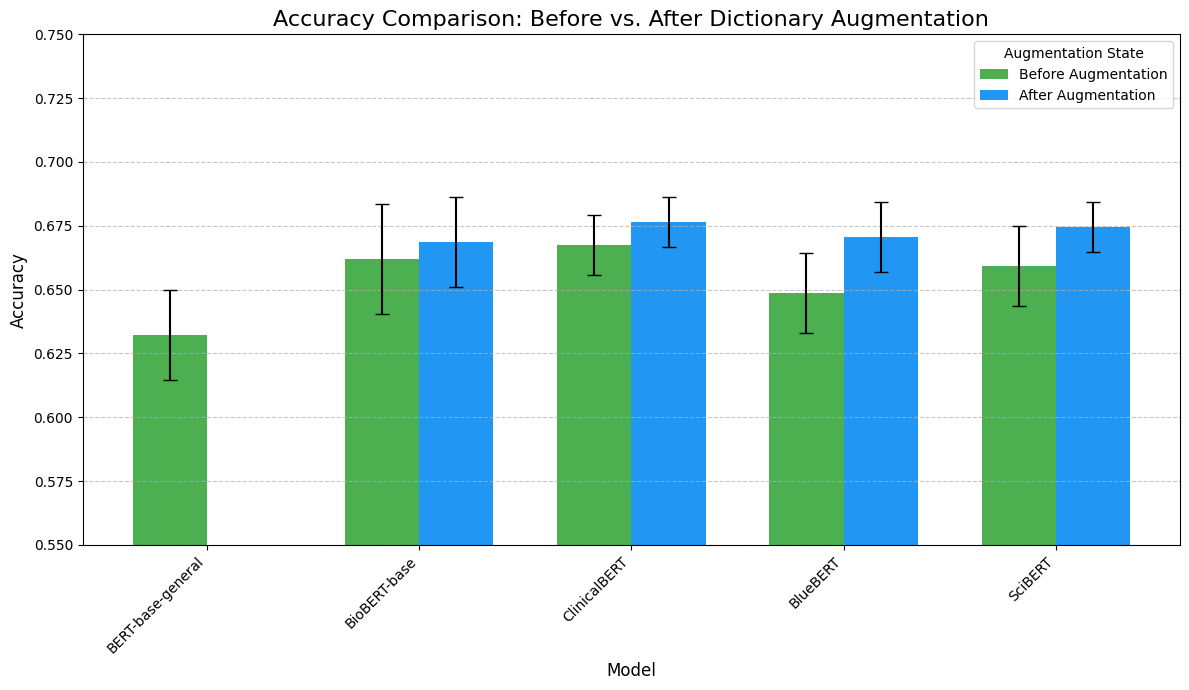

In [ ]:
# Set up the figure and axes for grouped bar chart
fig, ax = plt.subplots(figsize=(12, 7))

# Define bar width and positions
bar_width = 0.35
index = np.arange(len(df_results['Model']))

# Plot 'Before Augmentation' bars with error bars
bar1 = ax.bar(index - bar_width/2, df_results['Accuracy_Before'], bar_width, label='Before Augmentation', color='#4CAF50',
              yerr=df_results['Accuracy_Before_Std'] * 1.96, capsize=5)

# Plot 'After Augmentation' bars with error bars
bar2 = ax.bar(index + bar_width/2, df_results['Accuracy_After'], bar_width, label='After Augmentation', color='#2196F3',
              yerr=df_results['Accuracy_After_Std'] * 1.96, capsize=5)

# Add titles and labels
ax.set_title('Accuracy Comparison: Before vs. After Dictionary Augmentation', fontsize=16)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_xticks(index)
ax.set_xticklabels(df_results['Model'], rotation=45, ha='right', fontsize=10)
ax.set_ylim(0.55, 0.75) # Zoomed in Y-axis for better visibility of differences
ax.legend(title='Augmentation State', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 2. Accuracy Improvement from Dictionary Augmentation

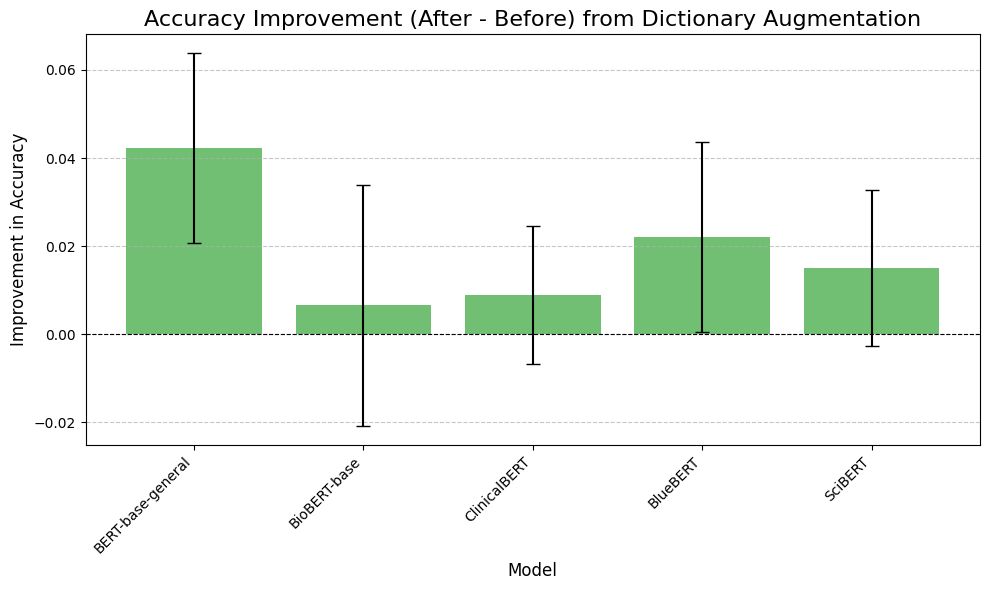

In [ ]:
plt.figure(figsize=(10, 6))

# Use 'Accuracy_Improvement' and 'Accuracy_Improvement_Std' columns directly
models = df_results['Model']
improvement_values = df_results['Accuracy_Improvement']
improvement_errors = df_results['Accuracy_Improvement_Std'] * 1.96 # 95% CI

# Define colors for bars based on improvement (positive/negative)
colors = ['#4CAF50' if val > 0 else '#F44336' for val in improvement_values]

plt.bar(models, improvement_values, yerr=improvement_errors, capsize=5, color=colors, alpha=0.8)

plt.title("Accuracy Improvement (After - Before) from Dictionary Augmentation", fontsize=16)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Improvement in Accuracy", fontsize=12)
plt.axhline(0, color="black", linestyle="--", linewidth=0.8) # Add a line at zero for reference
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

### 3. F1-Score Comparison (Before vs. After Dictionary Augmentation)

*(Note: F1-score 'After Augmentation' is now available for all models in the provided data)*

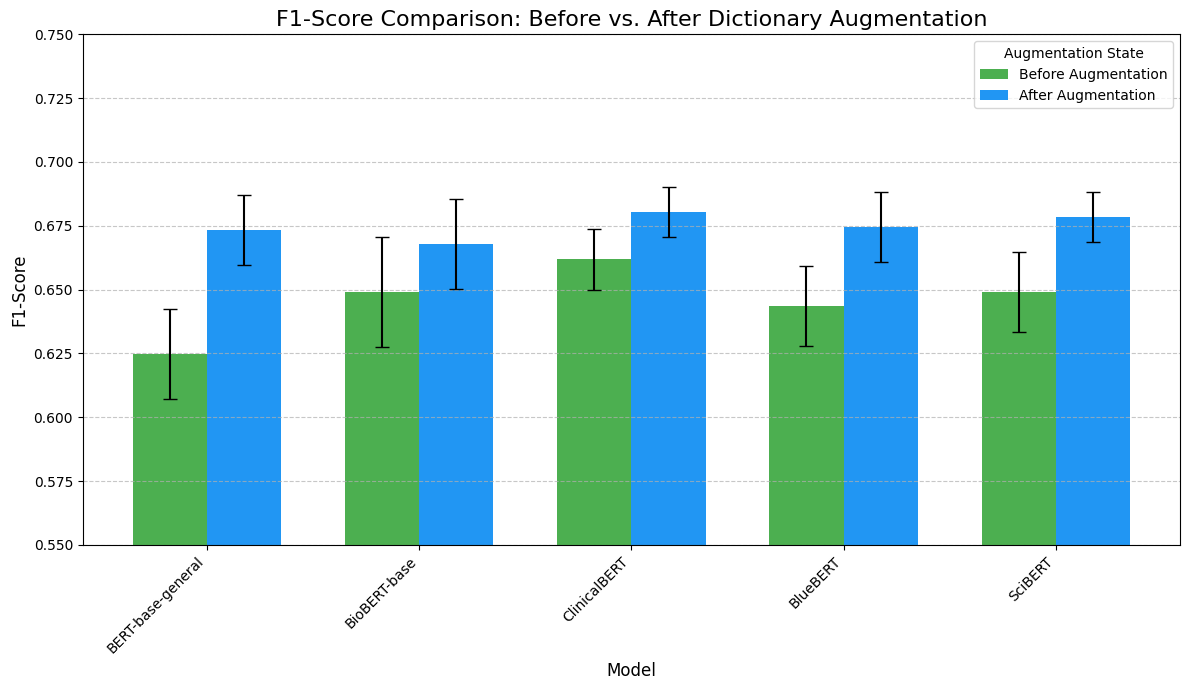

In [ ]:
# Set up the figure and axes for grouped bar chart
fig, ax = plt.subplots(figsize=(12, 7))

# Define bar width and positions
bar_width = 0.35
index = np.arange(len(df_results['Model']))

# Plot 'Before Augmentation' bars with error bars
bar1 = ax.bar(index - bar_width/2, df_results['F1_Before'], bar_width, label='Before Augmentation', color='#4CAF50',
              yerr=df_results['F1_Before_Std'] * 1.96, capsize=5)

# Plot 'After Augmentation' bars with error bars
bar2 = ax.bar(index + bar_width/2, df_results['F1_After'], bar_width, label='After Augmentation', color='#2196F3',
              yerr=df_results['F1_After_Std'] * 1.96, capsize=5)

# Add titles and labels
ax.set_title('F1-Score Comparison: Before vs. After Dictionary Augmentation', fontsize=16)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_xticks(index)
ax.set_xticklabels(df_results['Model'], rotation=45, ha='right', fontsize=10)
ax.set_ylim(0.55, 0.75) # Zoomed in Y-axis
ax.legend(title='Augmentation State', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 4. F1-Score Improvement from Dictionary Augmentation

*(Note: F1-score improvement is now calculated for all models due to complete data)*

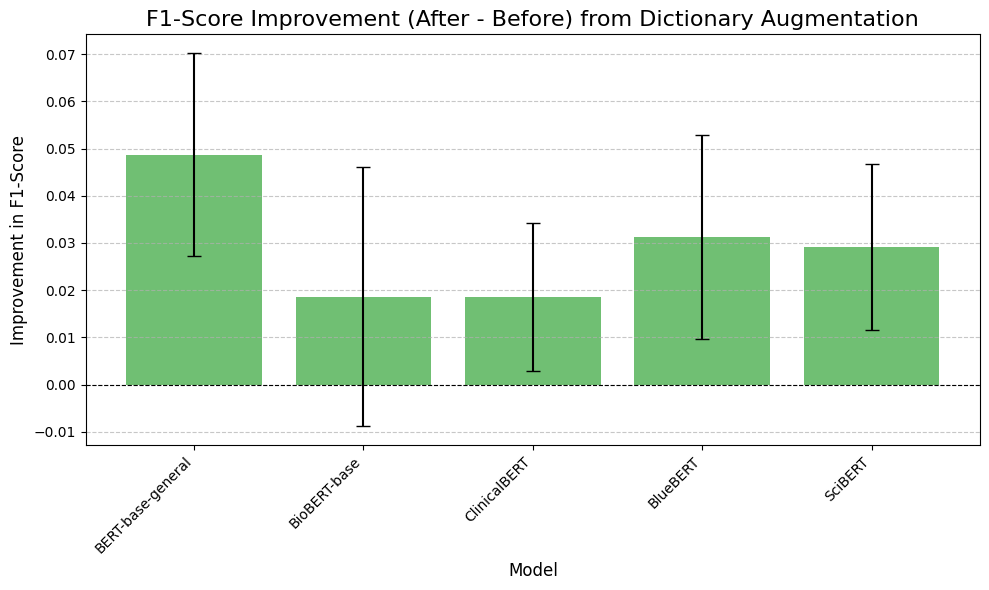

In [ ]:
plt.figure(figsize=(10, 6))

# Use 'F1_Improvement' and 'F1_Improvement_Std' columns directly
models = df_results['Model']
improvement_values = df_results['F1_Improvement']
improvement_errors = df_results['F1_Improvement_Std'] * 1.96 # 95% CI

# Define colors for bars based on improvement (positive/negative)
colors = ['#4CAF50' if val > 0 else '#F44336' for val in improvement_values]

plt.bar(models, improvement_values, yerr=improvement_errors, capsize=5, color=colors, alpha=0.8)

plt.title("F1-Score Improvement (After - Before) from Dictionary Augmentation", fontsize=16)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Improvement in F1-Score", fontsize=12)
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
from docx import Document
from docx.shared import Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
import re

def add_rich_paragraph(doc, raw_text, style_name='Normal', bold=False, space_after=Pt(6)):
    """Parses custom tags to add italic, subscript, and superscript formatting."""
    p = doc.add_paragraph(style=style_name)
    p.paragraph_format.space_after = space_after
    if not raw_text.strip():
        return p

    # Regex to find our custom tags: {type:text}
    # Allows nested brackets inside text by matching up to the last }
    pattern = re.compile(r'\{(i|sub|sup|b):([^}]+)\}')

    last_end = 0
    for match in pattern.finditer(raw_text):
        # Add normal text before the tag
        if match.start() > last_end:
            normal_text = raw_text[last_end:match.start()]
            run = p.add_run(normal_text)
            run.font.name = 'Calibri'
            run.font.size = Pt(11)

        tag_type = match.group(1)
        tag_text = match.group(2)

        # Add formatted text
        run = p.add_run(tag_text)
        run.font.name = 'Cambria Math' # Professional math font
        run.font.size = Pt(11)

        if tag_type == 'i':
            run.italic = True
        elif tag_type == 'sub':
            run.font.subscript = True
        elif tag_type == 'sup':
            run.font.superscript = True
        elif tag_type == 'b':
            run.bold = True

        last_end = match.end()

    # Add any remaining normal text
    if last_end < len(raw_text):
        run = p.add_run(raw_text[last_end:])
        run.font.name = 'Calibri'
        run.font.size = Pt(11)

    return p

# --- Create Document ---
doc = Document()

# Set default font for the document
style = doc.styles['Normal']
font = style.font
font.name = 'Calibri'
font.size = Pt(11)

# --- Title ---
title = doc.add_heading('Mathematical Model of Dictionary-Based Entity Marking', level=0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

subtitle = doc.add_paragraph('Domain Gap Enhancement for Transformer Architectures')
subtitle.alignment = WD_ALIGN_PARAGRAPH.CENTER
subtitle.runs[0].italic = True
subtitle.runs[0].font.size = Pt(12)

doc.add_paragraph() # Spacer

# --- Section 1 ---
doc.add_heading('1. Formalizing the Domain Gap Problem', level=1)
add_rich_paragraph(doc,
    "Let {i:S} = {(S{sub:i}, Y{sub:i})}{sub:i=1}{sup:N_src} be the labeled source domain and {i:T} = {(S{sub:j})}{sub:j=1}{sup:N_tgt} be the unlabeled target domain, where {i:S} is an input sequence and {i:Y} is the label space. The domain gap Δ is fundamentally driven by the divergence between the feature distributions of the two domains:"
)
add_rich_paragraph(doc,
    "Δ = {i:D}{sub:KL} ( P{sub:src}({i:X}) || P{sub:tgt}({i:X}) ) >> 0"
)
add_rich_paragraph(doc,
    "where {i:X} represents the lexical embeddings of {i:S}. In Named Entity Recognition (NER) or similar tasks, this divergence is heavily localized at the entity level (e.g., different jargon, proper nouns, or entity formats across domains)."
)

# --- Section 2 ---
doc.add_heading('2. Mathematical Definition of Dictionary-Based Marking', level=1)
add_rich_paragraph(doc,
    "Let {i:D} = { ({i:e}{sub:k}, {i:m}{sub:k}) }{sub:k=1}{sup:|D|} be an external dictionary mapping entity strings {i:e}{sub:k} to discrete markers {i:m}{sub:k}. Let the original input sequence be {i:S} = ({i:w}{sub:1}, {i:w}{sub:2}, ..., {i:w}{sub:n})."
)
add_rich_paragraph(doc,
    "We define the augmentation function {i:A}({i:S}, {i:D}) as a conditional string replacement operation:"
)
add_rich_paragraph(doc,
    "{i:A}({i:S}, {i:D}) = { \u0175{sub:i} }{sub:i=1}{sup:n}   where   \u0175{sub:i} = { {i:m}{sub:k}  if span({i:S}, {i:i}) = {i:e}{sub:k} and ({i:e}{sub:k}, {i:m}{sub:k}) ∈ {i:D} ;  {i:w}{sub:i}  otherwise }"
)
add_rich_paragraph(doc,
    "By applying {i:A}({i:S}, {i:D}), we transform the input space from {i:X} to an augmented space {i:X}{sub:aug}."
)

# --- Section 3 ---
doc.add_heading('3. Mechanism of Domain Gap Enhancement (Lexical Invariance)', level=1)
add_rich_paragraph(doc,
    "The enhancement of the domain gap occurs because the augmentation function {i:A}({i:S}, {i:D}) artificially forces the marginal distributions of the source and target domains to align in the augmented space."
)
add_rich_paragraph(doc,
    "Mathematically, for any entity {i:e}{sub:k} that appears in both domains but with different surface forms or frequencies, {i:A}({i:S}, {i:D}) collapses the variance:"
)
add_rich_paragraph(doc,
    "Var(P{sub:src}({i:X} | {i:Y}={i:e}{sub:k})) ≠ Var(P{sub:tgt}({i:X} | {i:Y}={i:e}{sub:k}))  ⟹  Var(P{sub:src}({i:X}{sub:aug} | {i:Y}={i:e}{sub:k})) = Var(P{sub:tgt}({i:X}{sub:aug} | {i:Y}={i:e}{sub:k})) = 0"
)
add_rich_paragraph(doc,
    "Because {i:e}{sub:k} is replaced by the exact same marker {i:m}{sub:k} in both domains, the conditional distribution of the input given the entity type becomes identical. Therefore, the overall domain gap in the augmented space shrinks:"
)
add_rich_paragraph(doc,
    "{i:D}{sub:KL} ( P{sub:src}({i:X}{sub:aug}) || P{sub:tgt}({i:X}{sub:aug}) ) << {i:D}{sub:KL} ( P{sub:src}({i:X}) || P{sub:tgt}({i:X}) )"
)

# --- Section 4 ---
doc.add_heading('4. Contextual Decoupling in the Transformer Architecture', level=1)
add_rich_paragraph(doc,
    "While replacing entities with markers reduces the domain gap, it risks losing critical entity-level semantics. The Transformer architecture mathematically compensates for this through its self-attention mechanism."
)
add_rich_paragraph(doc,
    "Given the augmented sequence {i:X}{sub:aug}, the Transformer computes contextualized representations {i:H} via scaled dot-product attention. For a marker token {i:m}{sub:k} at position {i:i}:"
)
add_rich_paragraph(doc,
    "{i:h}{sub:m_k} = Σ{sub:j≠i} α{sub:i,j} {i:V}{sub:j}"
)
add_rich_paragraph(doc,
    "where α{sub:i,j} are the attention weights. Because the marker {i:m}{sub:k} has no inherent lexical meaning, the attention mechanism is mathematically forced to distribute its weights α heavily onto the surrounding context tokens {i:w}{sub:i-1}, {i:w}{sub:i+1}, etc."
)
add_rich_paragraph(doc,
    "This achieves {b:Contextual Decoupling}: it separates the domain-invariant contextual cues (which are often similar across domains, e.g., \"patient was diagnosed with [DISEASE_MARKER]\") from the domain-specific lexical features of the entity itself."
)

# --- Section 5 ---
doc.add_heading('5. Unified Model Formulation', level=1)
add_rich_paragraph(doc,
    "Combining the domain adaptation theory with the architectural pipeline, the complete mathematical model for dictionary-enhanced domain gap reduction is expressed as:"
)
add_rich_paragraph(doc,
    "{i:X}{sub:aug}, {i:M} = {i:T}{sub:tokenizer}({i:A}({i:S}, {i:D}))"
)
add_rich_paragraph(doc,
    "{i:H} = Transformer{sub:\u03b8} ( {i:E}{sub:embeddings}({i:X}{sub:aug}) + {i:P}{sub:pos}, {i:M} )"
)
add_rich_paragraph(doc,
    "{i:h}{sub:CLS} = {i:H}[0, :]."
)
add_rich_paragraph(doc,
    "Ŷ = id2label [ argmax ( softmax ( {i:f}{sub:classifier}({i:h}{sub:CLS}, \u03c6) ) ) ]"
)

# --- Summary ---
doc.add_heading('Summary', level=1)
summary_text = (
    "By passing {i:A}({i:S}, {i:D}) into the pipeline instead of raw {i:S}, we explicitly construct "
    "an intermediate representation {i:X}{sub:aug} where Δ \u2248 0. The Transformer {sub:\u03b8} then learns "
    "to classify based on the structural context rather than memorizing domain-specific vocabulary, "
    "thereby yielding a model robust to domain shift."
)
add_rich_paragraph(doc, summary_text, bold=False, space_after=Pt(0))


# --- Save Document ---
filename = "Domain_Gap_Math_Model.docx"
doc.save(filename)
print(f"Successfully generated and saved: {filename}")

Successfully generated and saved: Domain_Gap_Math_Model.docx
